WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

[INFO] saved: R_vs_V_out_ringA_V_tip+\20260202_1237_R_vs_Vtip.csv
[INFO] All nodes (signed r, mirrored) saved: R_vs_V_out_ringA_V_tip+\20260202_1237_ALLNODES.csv


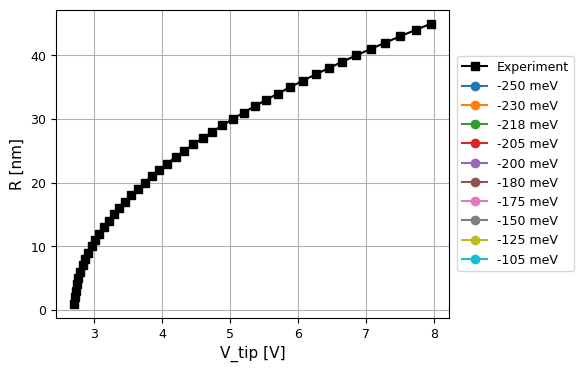

In [ ]:
"""
# -*- coding: utf-8 -*-
# Compute R(Vtip) or R(s) using Feenstra/Boltzmann core.
# - CPD を実験値で補正: 計算は V_applied = V_tip - CPD を使用（出力・表示は元の V_tip 表記）
# - Saves base R(Vtip) or R(s) (R>=0), and a mirrored symmetric discrete CSV (±R) as well.
# - Also saves per-level CSVs.
# - Draw(u) の単位切り替え: V / eV（同値）/ kT(無次元)
"""

from __future__ import annotations
import argparse
import csv
import datetime
import json
import math
import os
import shutil
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
import ngsolve as ng
from ngsolve.solvers import Newton
from netgen.geom2d import SplineGeometry
from scipy.optimize import brentq

# optional Draw (does not affect numerics)
try:
    from ngsolve.webgui import Draw
    _HAS_DRAW = True
except Exception:
    _HAS_DRAW = False


# =============================================================================
# Logging utility (ON/OFF)
# =============================================================================
class LogConfig:
    def __init__(self, enabled: bool = True):
        self.enabled = bool(enabled)


LOG = LogConfig(enabled=True)


def log_print(*args, **kwargs):
    if LOG.enabled:
        print(*args, **kwargs)


class NullContext:
    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc, tb):
        return False


class TeeStdout:
    """Duplicate stdout to both console and a log file (captures NGSolve warnings)."""

    def __init__(self, logfile_path: Path):
        self.logfile_path = Path(logfile_path)
        self._f = None
        self._old = None

    def __enter__(self):
        self._old = sys.stdout
        self._f = self.logfile_path.open("a", encoding="utf-8", buffering=1)
        sys.stdout = self
        return self

    def __exit__(self, exc_type, exc, tb):
        sys.stdout = self._old
        if self._f:
            self._f.close()

    def write(self, s):
        self._old.write(s)
        self._f.write(s)

    def flush(self):
        self._old.flush()
        self._f.flush()


def make_stdout_tee(run_dir: Path):
    if not LOG.enabled:
        return NullContext()
    return TeeStdout(Path(run_dir) / "stdout.log")


# =============================================================================
# Output helpers
# =============================================================================
def make_run_outdir(out_root: str) -> Path:
    root = Path(out_root)

    # legacy compatibility
    if root.name == "fit_out_ringA_Vtip+":
        if root.exists() and root.is_dir():
            shutil.rmtree(root)
        root = Path("fit_out")

    root.mkdir(parents=True, exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = root / ts
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def _json_sanitize(obj):
    try:
        import numpy as _np

        if isinstance(obj, (_np.integer,)):
            return int(obj)
        if isinstance(obj, (_np.floating,)):
            return float(obj)
        if isinstance(obj, (_np.bool_,)):
            return bool(obj)
        if isinstance(obj, _np.ndarray):
            return obj.tolist()
    except Exception:
        pass
    if isinstance(obj, Path):
        return str(obj)
    return obj


def dump_json(path: Path, obj: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=_json_sanitize)


# =============================================================================
# Levels utility (list + range)  ※最新 core 相当
# =============================================================================
def build_levels(
    levels_list: Optional[Sequence[float]],
    levels_range: Optional[Sequence[float]],
    default_levels: Sequence[float],
) -> np.ndarray:
    vals: List[float] = []

    if (levels_list is None) and (levels_range is None):
        vals.extend([float(x) for x in default_levels])

    if levels_list is not None and len(levels_list) > 0:
        vals.extend([float(x) for x in levels_list])

    if levels_range is not None:
        if len(levels_range) != 3:
            raise ValueError("--levels_range expects 3 numbers: START STOP STEP")
        s0, s1, ds = map(float, levels_range)
        if ds <= 0:
            raise ValueError("--levels_range STEP must be > 0")
        if s1 < s0:
            s0, s1 = s1, s0
        n = int(np.floor((s1 - s0) / ds + 1e-12)) + 1
        grid = s0 + ds * np.arange(n, dtype=float)
        grid = grid[grid <= s1 + 1e-12]
        vals.extend(grid.tolist())

    if len(vals) == 0:
        raise ValueError("No levels specified. Use --levels_list and/or --levels_range.")

    lev = np.array(vals, dtype=float)
    lev = lev[np.isfinite(lev)]
    lev = np.unique(np.round(lev, 12))
    lev.sort()
    return lev


# =============================================================================
# Fermi-Dirac integral F_{1/2} (NumPy only)  ※最新 core 相当
# =============================================================================
AH_A = 9.6
AH_B = 2.13
AH_C = 2.4
INV_GAMMA_3_2 = 2.0 / np.sqrt(np.pi)  # 1/Gamma(3/2)


def F_half_aymerich_humet_np(eta: np.ndarray | float) -> np.ndarray:
    eta = np.asarray(eta, dtype=float)
    denom_core = (AH_B + eta + (np.abs(eta - AH_B) ** AH_C + AH_A) ** (1.0 / AH_C))
    term1 = (3.0 * np.sqrt(2.0)) / (denom_core**1.5)
    term2 = INV_GAMMA_3_2 * np.exp(-eta)
    return 1.0 / (term1 + term2)


def F_half_legacy_np(eta: np.ndarray | float) -> np.ndarray:
    a1 = 6.316
    a2 = 12.92
    C_deg = 0.75224956896
    eta = np.asarray(eta, dtype=float)
    return np.piecewise(
        eta,
        [eta < -10.0],
        [
            lambda x: np.exp(x),
            lambda x: 1.0 / (np.exp(-x) + (C_deg * (x**2 + a1 * x + a2) ** 0.75) ** (-1.0)),
        ],
    )


def F_half_np(eta: np.ndarray | float, method: str = "aymerich_humet") -> np.ndarray:
    method = str(method).lower()
    if method in ("aymerich_humet", "ah", "aymerich"):
        return F_half_aymerich_humet_np(eta)
    if method in ("legacy", "old"):
        return F_half_legacy_np(eta)
    raise ValueError(f"Unknown F_half method: {method}")


# =============================================================================
# Core FEM dataclasses  ※最新 core 相当
# =============================================================================
@dataclass
class PhysicalParameters:
    T: float = 300.0
    Nd: float = 1e22
    Na: float = 0.0
    sigma_s: float = 1e16

    # updated effective masses
    m_de: float = 0.40 * const.m_e
    m_dh: float = 2.6 * const.m_e

    # valley degeneracy factors
    g_c: float = 3.0
    g_v: float = 1.0

    Eg: float = 3.26
    Ed_offset_hex: float = 0.124
    Ed_offset_cub: float = 0.066
    Ed_ratio_c_to_h: float = 1.88
    Ea_offset: float = 0.2
    ni: float = 8.2e15

    eps_sic: float = 9.7
    eps_sio2: float = 3.9
    eps_vac: float = 1.0

    n0: float = 0.0
    p0: float = 0.0
    Nc: float = 0.0
    Nv: float = 0.0
    Ec: float = 0.0
    Ev: float = 0.0
    Edh: float = 0.0
    Edc: float = 0.0
    Nd_h: float = 0.0
    Nd_c: float = 0.0
    kTeV: float = 0.0
    Ef: float = 0.0

    def __post_init__(self):
        self.kTeV = const.k * self.T / const.e

        total_ratio = 1.0 + self.Ed_ratio_c_to_h
        self.Nd_h = self.Nd * 1.0 / total_ratio
        self.Nd_c = self.Nd * self.Ed_ratio_c_to_h / total_ratio

        self.n0 = (self.Nd + np.sqrt(self.Nd**2 + 4 * self.ni**2)) / 2
        self.p0 = self.ni**2 / self.n0

        # effective density of states with valley degeneracy
        self.Nc = 2 * self.g_c * (2 * np.pi * self.m_de * const.k * self.T / (const.h**2)) ** 1.5
        self.Nv = 2 * self.g_v * (2 * np.pi * self.m_dh * const.k * self.T / (const.h**2)) ** 1.5

        self.Ev = 0.0
        self.Ec = self.Ev + self.Eg
        self.Edh = self.Ec - self.Ed_offset_hex
        self.Edc = self.Ec - self.Ed_offset_cub


@dataclass
class GeometricParameters:
    L_c: float = 1e-9
    l_sio2: float = 5.0
    tip_radius: float = 45.0
    tip_height: float = 8.0  # tip–sample distance s [nm]
    l_vac: float = 200.0
    region_radius: float = 500.0
    n_tip_arc_points: int = 7

    def __post_init__(self):
        assert self.n_tip_arc_points % 2 == 1, "n_tip_arc_points should be odd"


# =============================================================================
# Fermi level determination  ※最新 core 相当
# =============================================================================
def find_fermi_level(params: PhysicalParameters, out_dir: str, plot: bool = False, fermi_np: str = "aymerich_humet") -> float:
    def neutrality(Ef: float) -> float:
        p = params.Nv * F_half_np((params.Ev - Ef) / params.kTeV, method=fermi_np)
        n = params.Nc * F_half_np((Ef - params.Ec) / params.kTeV, method=fermi_np)
        Ndp_h = params.Nd_h / (1 + 2 * np.exp((Ef - params.Edh) / params.kTeV))
        Ndp_c = params.Nd_c / (1 + 2 * np.exp((Ef - params.Edc) / params.kTeV))
        return np.log(p + Ndp_h + Ndp_c) - np.log(n)

    Ef = brentq(neutrality, params.Ev + params.kTeV, params.Ec - params.kTeV)
    # plotは未使用（必要なら追加）
    return Ef


# =============================================================================
# Mesh builder
# - include_tip=True: 最新 core_fem.py と同一
# - include_tip=False: tip境界を消して top を Dirichlet として使う
# =============================================================================
def create_mesh(geom: GeometricParameters, include_tip: bool = True):
    L_c = geom.L_c
    R_dimless = geom.region_radius * 1e-9 / L_c
    sio2_depth_dimless = geom.l_sio2 * 1e-9 / L_c
    vac_depth_dimless = geom.l_vac * 1e-9 / L_c

    tip_z_dimless = geom.tip_height * 1e-9 / L_c
    tip_radius_dimless = geom.tip_radius * 1e-9 / L_c
    tip_arc_angle = 75 * np.pi / 180
    n_middle_points = geom.n_tip_arc_points

    geo = SplineGeometry()

    # --- same as latest core: bottom includes (vac + sio2) ---
    p1 = geo.AppendPoint(0, -vac_depth_dimless - sio2_depth_dimless)
    p2 = geo.AppendPoint(0, -sio2_depth_dimless)
    origin = geo.AppendPoint(0, 0)

    q1 = geo.AppendPoint(R_dimless, -vac_depth_dimless - sio2_depth_dimless)
    q2 = geo.AppendPoint(R_dimless, -sio2_depth_dimless)
    q3 = geo.AppendPoint(R_dimless, 0)
    q4 = geo.AppendPoint(R_dimless, vac_depth_dimless)

    geo.Append(["line", p1, p2], bc="axis", leftdomain=0, rightdomain=1, maxh=5)
    geo.Append(["line", p2, q2], bc="sic/sio2", leftdomain=2, rightdomain=1, maxh=1)
    geo.Append(["line", q2, q1], bc="far-field", leftdomain=0, rightdomain=1)
    geo.Append(["line", q1, p1], bc="ground", leftdomain=0, rightdomain=1)

    geo.Append(["line", origin, p2], bc="axis", leftdomain=2, rightdomain=0, maxh=0.5)
    geo.Append(["line", q2, q3], bc="far-field", leftdomain=2, rightdomain=0)
    geo.Append(["line", q3, origin], bc="sio2/vacuum", leftdomain=2, rightdomain=3)

    if include_tip:
        # --- same as latest core ---
        tip1 = geo.AppendPoint(0, tip_z_dimless)
        tip2 = geo.AppendPoint(
            tip_radius_dimless * np.sin(tip_arc_angle),
            tip_z_dimless + tip_radius_dimless * (1 - np.cos(tip_arc_angle)),
        )
        tipMlst = [
            geo.AppendPoint(
                tip_radius_dimless * np.sin(a),
                tip_z_dimless + tip_radius_dimless * (1 - np.cos(a)),
            )
            for a in np.linspace(0, tip_arc_angle, n_middle_points + 2)[1:-1]
        ]
        tip3 = geo.AppendPoint(
            tip_radius_dimless * np.sin(tip_arc_angle)
            + (vac_depth_dimless - tip_z_dimless - tip_radius_dimless * (1 - np.cos(tip_arc_angle))) / np.tan(tip_arc_angle),
            vac_depth_dimless,
        )

        geo.Append(["line", origin, tip1], bc="axis", leftdomain=0, rightdomain=3, maxh=0.5)
        for i in range(0, len(tipMlst), 2):
            pts = [
                tip1 if i == 0 else tipMlst[i - 1],
                tipMlst[i],
                tip2 if i == len(tipMlst) - 1 else tipMlst[i + 1],
            ]
            geo.Append(["spline3", *pts], bc="tip", leftdomain=0, rightdomain=3, maxh=0.5)
        geo.Append(["line", tip2, tip3], bc="tip", leftdomain=0, rightdomain=3)
        geo.Append(["line", tip3, q4], bc="top", leftdomain=0, rightdomain=3)
    else:
        # tip無し: 軸を top まで上げるだけ（Dirichlet は "top" にかける）
        pTop = geo.AppendPoint(0, vac_depth_dimless)
        geo.Append(["line", origin, pTop], bc="axis", leftdomain=0, rightdomain=3, maxh=0.5)
        geo.Append(["line", pTop, q4], bc="top", leftdomain=0, rightdomain=3)

    geo.Append(["line", q4, q3], bc="far-field", leftdomain=0, rightdomain=3)

    geo.SetMaterial(1, "sic")
    geo.SetMaterial(2, "sio2")
    geo.SetMaterial(3, "vac")

    ngmesh = geo.GenerateMesh(maxh=10, grading=0.2)
    return ng.Mesh(ngmesh)


# =============================================================================
# Weak form / warm start / homotopy  ※最新 core 相当（tip無し時も同一式）
# =============================================================================
def _setup_weak_form(
    fes,
    epsilon_r,
    phys: PhysicalParameters,
    V_c: float,
    L_c: float,
    homotopy_charge,
    homotopy_sigma,
    geom: GeometricParameters,
    msh,
    Feenstra: bool,
    assume_full_ionization: bool,
):
    uh, vh = fes.TnT()
    r = ng.x

    C0 = (const.e * L_c**2) / (const.epsilon_0 * V_c)
    Ef_dim, Ec_dim, Ev_dim = phys.Ef / V_c, phys.Ec / V_c, phys.Ev / V_c
    Edh_dim, Edc_dim = phys.Edh / V_c, phys.Edc / V_c

    lambda_ff = 1 / (geom.region_radius * 1e-9 / L_c)
    sigma_s_target = (phys.sigma_s * const.e * L_c) / (const.epsilon_0 * V_c)

    clip_potential, clip_exp = 120.0, 40.0

    def clamp(val, b):
        return ng.IfPos(val - b, b, ng.IfPos(-b - val, -b, val))

    def safe_exp(x):
        return ng.exp(clamp(x, clip_exp))

    # FEM-side approximation (same as latest core)
    def fermi_half_ng(x):
        x_clip = clamp(x, clip_exp)
        high = (2 / np.sqrt(np.pi)) * ((2 / 3) * x_clip**1.5 + (np.pi**2 / 12) * x_clip ** (-0.5))
        low = safe_exp(x_clip) / (1 + 0.27 * safe_exp(x_clip))
        return ng.IfPos(x_clip - 25.0, high, low)

    u_clip = clamp(uh, clip_potential)

    if Feenstra:
        n_term = C0 * phys.Nc * fermi_half_ng((Ef_dim - Ec_dim) + u_clip)
        p_term = C0 * phys.Nv * fermi_half_ng((Ev_dim - Ef_dim) - u_clip)
        if assume_full_ionization:
            Ndp_term = C0 * phys.Nd
        else:
            Ndp_h = C0 * phys.Nd_h / (1 + 2 * safe_exp((Ef_dim - Edh_dim) + u_clip))
            Ndp_c = C0 * phys.Nd_c / (1 + 2 * safe_exp((Ef_dim - Edc_dim) + u_clip))
            Ndp_term = Ndp_h + Ndp_c
    else:
        n_term = C0 * phys.n0 * safe_exp(u_clip)
        p_term = C0 * phys.p0 * safe_exp(-u_clip)
        Ndp_term = C0 * phys.Nd

    rho_dim = homotopy_charge * (p_term + Ndp_term - n_term)
    sigma_s_dim = homotopy_sigma * sigma_s_target

    a = ng.BilinearForm(fes, symmetric=False)
    a += epsilon_r * ng.grad(uh) * ng.grad(vh) * r * ng.dx
    a += epsilon_r * lambda_ff * uh * vh * r * ng.ds("far-field")
    a += -rho_dim * vh * r * ng.dx(definedon=msh.Materials("sic"))
    a += -sigma_s_dim * vh * r * ng.ds("sic/sio2")
    return a


def _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh, bc_high: str):
    """Linear ramp to reduce initial Newton difficulty. Same as latest core, but bc name is configurable."""
    w = fes.TrialFunction()
    v = fes.TestFunction()
    r = ng.x

    lambda_ff = 1 / geom.region_radius
    a_lin = ng.BilinearForm(fes)
    a_lin += epsilon_r * ng.grad(w) * ng.grad(v) * r * ng.dx
    a_lin += epsilon_r * lambda_ff * w * v * r * ng.ds("far-field")
    f_lin = ng.LinearForm(fes)

    u.vec[:] = 0.0
    for v_val in np.linspace(0.0, V_tip, 5)[1:]:
        uh = ng.GridFunction(fes)
        uh.Set(0, definedon=msh.Boundaries("ground"))
        uh.Set(v_val / V_c, definedon=msh.Boundaries(bc_high))
        a_lin.Assemble()
        f_lin.Assemble()
        rvec = f_lin.vec.CreateVector()
        rvec.data = f_lin.vec - a_lin.mat * uh.vec

        freedofs = fes.FreeDofs()
        freedofs &= ~fes.GetDofs(msh.Boundaries("ground"))
        freedofs &= ~fes.GetDofs(msh.Boundaries(bc_high))

        uh.vec.data += a_lin.mat.Inverse(freedofs, inverse="sparsecholesky") * rvec
        u.vec.data = uh.vec


def solve_with_homotopy(a, u, fes, msh, homotopy_charge, homotopy_sigma, bc_high: str):
    """
    Latest core behavior:
      - fast initial step=0.1
      - only first trial has fallback schedule if Newton fails
    """
    def _stage(param, name,
               step_init=0.1,
               min_step=1e-4,
               first_try_factors=(1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125),
               step_grow=1.5,
               step_cap=0.5):

        theta, step = 0.0, float(step_init)

        backup = ng.GridFunction(fes)
        backup.vec.data = u.vec

        freedofs = fes.FreeDofs()
        freedofs &= ~fes.GetDofs(msh.Boundaries("ground"))
        freedofs &= ~fes.GetDofs(msh.Boundaries(bc_high))

        newton_kwargs = dict(
            freedofs=freedofs, maxit=50, maxerr=1e-11,
            inverse="sparsecholesky", dampfactor=0.7, printing=False
        )

        def _try_newton(trial_theta: float) -> bool:
            param.Set(trial_theta)
            a.Assemble()
            converged, _ = Newton(a, u, **newton_kwargs)
            if converged < 0:
                return False
            backup.vec.data = u.vec
            return True

        while theta < 1.0 - 1e-12:
            trial = min(1.0, theta + step)

            # first trial only
            if theta == 0.0:
                ok = False
                u.vec.data = backup.vec
                for f in first_try_factors:
                    step_try = step * float(f)
                    if step_try < min_step:
                        continue
                    trial_try = min(1.0, theta + step_try)
                    log_print(f"[Newton] stage={name} theta-> {trial_try:.4f} step={step_try:.4g} (first-trial)")
                    try:
                        u.vec.data = backup.vec
                        ok = _try_newton(trial_try)
                    except Exception:
                        ok = False
                    if ok:
                        theta = trial_try
                        step = min(float(step_init), step_cap)
                        break
                if not ok:
                    raise RuntimeError(f"Homotopy stage '{name}' failed at first trial even after fallback schedule.")
                continue

            # normal stepping
            log_print(f"[Newton] stage={name} theta-> {trial:.4f} step={step:.4g}")
            try:
                ok = _try_newton(trial)
                if not ok:
                    raise RuntimeError("Newton failed")
                theta = trial
                if step < step_cap:
                    step *= step_grow
            except Exception:
                log_print(f"[Newton][FAIL] stage={name} theta={theta:.4f} trial={trial:.4f} step-> {step*0.5:.4g}")
                u.vec.data = backup.vec
                step *= 0.5
                if step < min_step:
                    raise RuntimeError(f"Homotopy stage '{name}' failed.")

    homotopy_sigma.Set(0.0)
    _stage(homotopy_charge, "Space Charge", step_init=0.1)
    homotopy_charge.Set(1.0)
    _stage(homotopy_sigma, "Interface Charge", step_init=0.1)


# =============================================================================
# save/load  ※最新 core 相当
# =============================================================================
def save_results(msh, u, epsilon_r, V_c, Feenstra: bool, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    msh.ngmesh.Save(os.path.join(out_dir, "mesh.vol"))
    u_np = u.vec.FV().NumPy()
    np.save(os.path.join(out_dir, "u_dimless.npy"), u_np)
    np.save(os.path.join(out_dir, "u_volts.npy"), u_np * V_c)

    mat_names = list(msh.GetMaterials())
    eps_map = ({name: val for name, val in zip(mat_names, [float(v) for v in epsilon_r.components])}
               if hasattr(epsilon_r, "components") else {name: None for name in mat_names})
    with open(os.path.join(out_dir, "epsilon_r.json"), "w", encoding="utf-8") as f:
        json.dump(eps_map, f, indent=2, ensure_ascii=False)

    meta = {
        "V_c": float(V_c),
        "Feenstra": bool(Feenstra),
        "ndof": int(u.space.ndof),
        "fes": "H1",
        "order": int(u.space.globalorder),
        "materials": mat_names,
        "boundaries": list(msh.GetBoundaries()),
    }
    with open(os.path.join(out_dir, "metadata.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    vtk = ng.VTKOutput(ma=msh, coefs=[u], names=["potential_dimless"],
                       filename=os.path.join(out_dir, "solution"), subdivision=0)
    vtk.Do()


def load_results(out_dir: str, geom: GeometricParameters, V_c: float, include_tip: bool):
    msh = create_mesh(geom, include_tip=include_tip)
    fes = ng.H1(msh, order=1)
    u = ng.GridFunction(fes, name="potential_dimless")

    with open(os.path.join(out_dir, "metadata.json"), encoding="utf-8") as f:
        meta = json.load(f)

    if int(meta["ndof"]) != int(fes.ndof):
        raise RuntimeError(f"DOF mismatch: saved={meta['ndof']} current={fes.ndof}")

    u_vec = np.load(os.path.join(out_dir, "u_dimless.npy"))
    if u_vec.size != fes.ndof:
        raise RuntimeError("Vector length mismatch")
    u.vec.FV().NumPy()[:] = u_vec
    return msh, u, u_vec * V_c


def run_fem_simulation(
    phys: PhysicalParameters,
    geom: GeometricParameters,
    V_tip: float,
    Feenstra: bool,
    out_dir: str,
    assume_full_ionization: bool,
    include_tip: bool,
):
    msh = create_mesh(geom, include_tip=include_tip)
    V_c = const.k * phys.T / const.e
    fes = ng.H1(msh, order=1)
    u = ng.GridFunction(fes, name="potential_dimless")
    epsilon_r = ng.CoefficientFunction([phys.eps_sic, phys.eps_sio2, phys.eps_vac])

    homotopy_charge = ng.Parameter(0.0)
    homotopy_sigma = ng.Parameter(0.0)

    a = _setup_weak_form(
        fes, epsilon_r, phys, V_c, geom.L_c,
        homotopy_charge, homotopy_sigma, geom, msh,
        Feenstra, assume_full_ionization
    )

    # Dirichlet boundaries
    u.Set(0, definedon=msh.Boundaries("ground"))

    bc_high = "tip" if include_tip else "top"
    u.Set(V_tip / V_c, definedon=msh.Boundaries(bc_high))

    # warm start is same algorithm, boundary name differs
    _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh, bc_high=bc_high)

    solve_with_homotopy(a, u, fes, msh, homotopy_charge, homotopy_sigma, bc_high=bc_high)
    save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir)
    return V_c


# =============================================================================
# Post-processing (profile sampling & ring radius)  ※最新 core 相当
# =============================================================================
def sample_profile_on_z(msh, u, V_c, z_nm: float, r_max_nm: float, npts: int = 1201):
    rs = np.linspace(0.0, r_max_nm, npts)
    prof = np.full_like(rs, np.nan, dtype=float)
    for i, rr in enumerate(rs):
        try:
            prof[i] = float(u(msh(rr, z_nm))) * V_c
        except Exception:
            prof[i] = np.nan
    return rs, prof


def ring_radius_from_profile(rs, prof, level, eps=1e-12):
    rs = np.asarray(rs, float)
    prof = np.asarray(prof, float)
    lev = float(level)

    dif = prof - lev
    m_pair = np.isfinite(dif[:-1]) & np.isfinite(dif[1:])
    chg = ((dif[:-1] <= 0) & (dif[1:] >= 0)) | ((dif[:-1] >= 0) & (dif[1:] <= 0))
    idx = np.where(m_pair & chg)[0]
    if idx.size == 0:
        return np.nan

    roots = []
    for i in idx:
        r0, r1 = rs[i], rs[i + 1]
        y0, y1 = prof[i], prof[i + 1]
        if not np.isfinite(y0 + y1) or (y1 == y0):
            continue
        r = r0 + (lev - y0) * (r1 - r0) / (y1 - y0)
        if r >= -eps:
            roots.append(max(0.0, float(r)))
    return float(min(roots)) if roots else np.nan


def build_symmetric_R_csv(path, x_vals, R_vals):
    """Same behavior as latest core: create (-|R|, x), (+|R|, x) pairs and sort by R."""
    records = []
    for xv, rv in zip(x_vals, R_vals):
        if not (np.isfinite(xv) and np.isfinite(rv)):
            continue
        rabs = abs(float(rv))
        records.append((-rabs, xv))
        records.append((+rabs, xv))
    if records:
        arr = np.asarray(records, float)
        arr = arr[np.argsort(arr[:, 0])]
        with open(path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["R (nm)", "x (unit)"])
            w.writerows(arr.tolist())


def save_all_nodes_signed_r_csv(msh, u, V_c, out_path,
                                r_min_nm=-500.0, r_max_nm=500.0,
                                axis_tol_nm=1e-9):
    """
    メッシュ節点で u を評価し、符号付き半径 x=r を -R..+R で保存。
    r<0 は r>0 をミラー複製（r=0 近傍は二重登録しない）。u は [V] 出力。
    出力ヘッダー: ["x (nm)", "y (nm)", "u (V)"]（旧仕様維持）
    """
    ngm = msh.ngmesh

    def get_xy(p):
        if hasattr(p, "X") and callable(p.X):
            return float(p.X()), float(p.Y())
        if hasattr(p, "x") and hasattr(p, "y"):
            return float(p.x), float(p.y)
        return float(p[0]), float(p[1])

    # 正側(含む軸)の節点を評価
    pos_rows = []  # (x>=0, y, u[V])
    for p in ngm.Points():
        xq, yq = get_xy(p)
        if xq < -axis_tol_nm:  # 負側の実点は無視（ミラーで作る）
            continue
        if not (r_min_nm - 1e-9 <= xq <= r_max_nm + 1e-9):
            continue
        try:
            val_V = float(u(msh(xq, yq))) * float(V_c)
        except Exception:
            continue
        pos_rows.append((float(xq), float(yq), val_V))

    # ミラー補完（x>0 → x<0 に複製）
    rows_signed = []
    for x, y, v in pos_rows:
        rows_signed.append((+x, y, v))
        if x > axis_tol_nm:  # 軸点は複製しない
            xm = -x
            if r_min_nm <= xm <= r_max_nm:
                rows_signed.append((xm, y, v))

    # 範囲クリップ & ソート（x→y）
    rows_signed = [(x, y, v) for (x, y, v) in rows_signed if (r_min_nm <= x <= r_max_nm)]
    rows_signed.sort(key=lambda t: (t[0], t[1]))

    # 出力
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["x (nm)", "y (nm)", "u (V)"])
        w.writerows(rows_signed)

# =============================================================================
# Sweep orchestration
# =============================================================================
def _save_dos_meta_jp(run_dir: Path, phys: PhysicalParameters, args):
    dump_json(run_dir / "dos_effective_density.json", {
        "タイムスタンプ": run_dir.name,
        "温度_T[K]": float(phys.T),
        "有効状態密度_Nc[m^-3]": float(phys.Nc),
        "有効状態密度_Nv[m^-3]": float(phys.Nv),
        "電子有効質量_m_de/me": 0.4,
        "正孔有効質量_m_dh/me": 2.6,
        "谷縮退度_g_c": float(phys.g_c),
        "谷縮退度_g_v": float(phys.g_v),
        "ドナー濃度_Nd[cm^-3]": float(args.Nd_cm3),
        "界面電荷密度_sigma_s[cm^-2]": float(args.sigma_s),
        "モデル(model)": str(args.model),
        "CPD[V]": float(args.CPD),
        "Fermi積分近似(fermi_np)": str(args.fermi_np),
        "tip有無(include_tip)": bool(args.include_tip),
    })


def _write_matrix_csv(path: Path, x_name: str, x_vals, levels, R_dict):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([x_name] + [f"R_{float(lev):.6g}V" for lev in levels])
        for i, xv in enumerate(x_vals):
            w.writerow([xv] + [R_dict[float(lev)][i] for lev in levels])


def sweep_Rs(args):
    run_dir = make_run_outdir(args.out_root)
    with make_stdout_tee(run_dir):
        print(f"[INFO] run dir: {run_dir}")
        print(f"[INFO] mode: Rs")
        print(f"[INFO] include_tip: {args.include_tip}")
        print(f"[INFO] logging: {'ON' if LOG.enabled else 'OFF'}")

        dump_json(run_dir / "args.json", vars(args))

        DEFAULT_LEVELS = [0.05, 0.075, 0.09, 0.105, 0.125, 0.13, 0.15, 0.175, 0.2]
        LEVELS = build_levels(args.levels_list, args.levels_range, DEFAULT_LEVELS)

        s_vals = np.linspace(args.s_list[0], args.s_list[1], int(args.s_list[2]))
        V_app = float(args.Vtip_fixed - args.CPD)

        phys = PhysicalParameters(T=args.T, Nd=args.Nd_cm3 * 1e6, sigma_s=args.sigma_s * 1e4)
        phys.Ef = find_fermi_level(phys, str(run_dir), plot=False, fermi_np=args.fermi_np)
        _save_dos_meta_jp(run_dir, phys, args)

        Feenstra = (args.model[0].upper() == "F")

        R_dict = {float(lev): [] for lev in LEVELS}
        tip_tag = f"R{args.tip_radius:.2f}".replace(".", "p")

        last_msh = last_u = last_Vc = None

        for s in s_vals:
            geom = GeometricParameters(
                l_sio2=float(args.l_sio2),
                tip_radius=float(args.tip_radius),
                tip_height=float(s),
                l_vac=float(args.l_vac),
                region_radius=float(args.region_radius),
                n_tip_arc_points=int(args.n_tip_arc_points),
            )
            subdir = str(run_dir / "sweep_s" / tip_tag / f"s_{s:.3f}")
            os.makedirs(subdir, exist_ok=True)

            print(f"[RUN] s={s:.3f} nm | Vtip_fixed={args.Vtip_fixed:+.3f} V | V_app={V_app:+.3f} V | R_tip={args.tip_radius:.2f} nm")
            V_c = run_fem_simulation(
                phys, geom, V_tip=V_app,
                Feenstra=Feenstra, out_dir=subdir,
                assume_full_ionization=args.assume_full_ionization,
                include_tip=args.include_tip
            )
            msh, u, _ = load_results(subdir, geom, V_c, include_tip=args.include_tip)
            last_msh, last_u, last_Vc = msh, u, V_c

            rs, prof = sample_profile_on_z(
                msh, u, V_c,
                z_nm=float(args.sample_z_nm),
                r_max_nm=float(geom.region_radius),
                npts=int(args.npts_profile),
            )
            for lev in LEVELS:
                R_dict[float(lev)].append(ring_radius_from_profile(rs, prof, lev))

        stamp = run_dir.name
        out_csv = Path(run_dir) / f"{stamp}_R_vs_s.csv"
        _write_matrix_csv(out_csv, "s (nm)", s_vals, LEVELS, R_dict)
        print("[INFO] saved:", out_csv)

        for lev in LEVELS:
            levf = float(lev)
            p = Path(run_dir) / f"{stamp}_R_vs_s_{levf:.6g}V.csv"
            with open(p, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(["s (nm)", f"R (nm) @ {levf:.6g} V"])
                for s, R in zip(s_vals, R_dict[levf]):
                    w.writerow([s, R])
            build_symmetric_R_csv(Path(run_dir) / f"{stamp}_R_vs_s_{levf:.6g}V_SYMM.csv", s_vals, R_dict[levf])

        # plot
        fig, ax = plt.subplots(figsize=(6, 4))
        if args.exp_overlay and Path(args.exp_overlay).exists():
            exp_df = pd.read_csv(args.exp_overlay).iloc[:, :2]
            ax.plot(exp_df.iloc[:, 0], exp_df.iloc[:, 1], "ks", label="Experiment")
        for lev in LEVELS:
            levf = float(lev)
            ax.plot(s_vals, R_dict[levf], "o-", ms=2, label=f"{levf*1e3:.0f} mV")
        ax.set_xlabel("s [nm]")
        ax.set_ylabel("R [nm]")
        ax.set_title(f"R(s) @ Vtip_fixed={args.Vtip_fixed:+.3f} V (V_app={V_app:+.3f} V)")
        ax.grid(True)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
        fig.subplots_adjust(right=0.78)
        plt.show()
        fig.savefig(Path(run_dir) / f"{stamp}_R_vs_s.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print("[INFO] Plot (png) saved:", f"{stamp}_R_vs_Vtip.png")
        
        #save all nodes
        if args.save_allnodes and (last_msh is not None) and (last_u is not None) and (last_Vc is not None):
            out_all = Path(run_dir) / f"{stamp}_ALLNODES.csv"
            save_all_nodes_signed_r_csv(
                last_msh, last_u, last_Vc, out_all,
                r_min_nm=float(args.allnodes_rmin),
                r_max_nm=float(args.allnodes_rmax)
            )
            print("[INFO] All nodes (signed r, mirrored) saved:", out_all)
    
        # optional Draw (last)
        if args.show and _HAS_DRAW and (last_u is not None):
            try:
                Draw(last_u * last_Vc, last_u.space.mesh, "potential_V")
            except Exception as e:
                print("[WARN] Draw(u) failed:", e)

def sweep_RV(args):
    run_dir = make_run_outdir(args.out_root)
    with make_stdout_tee(run_dir):
        print(f"[INFO] run dir: {run_dir}")
        print(f"[INFO] mode: RV")
        print(f"[INFO] include_tip: {args.include_tip}")
        print(f"[INFO] logging: {'ON' if LOG.enabled else 'OFF'}")

        dump_json(run_dir / "args.json", vars(args))

        DEFAULT_LEVELS = [0.05, 0.075, 0.09, 0.105, 0.125, 0.13, 0.15, 0.175, 0.2]
        LEVELS = build_levels(args.levels_list, args.levels_range, DEFAULT_LEVELS)

        Vtips = np.linspace(args.Vtip_list[0], args.Vtip_list[1], int(args.Vtip_list[2]))

        phys = PhysicalParameters(T=args.T, Nd=args.Nd_cm3 * 1e6, sigma_s=args.sigma_s * 1e4)
        phys.Ef = find_fermi_level(phys, str(run_dir), plot=False, fermi_np=args.fermi_np)
        _save_dos_meta_jp(run_dir, phys, args)

        Feenstra = (args.model[0].upper() == "F")

        geom = GeometricParameters(
            l_sio2=float(args.l_sio2),
            tip_radius=float(args.tip_radius),
            tip_height=float(args.s_fixed),
            l_vac=float(args.l_vac),
            region_radius=float(args.region_radius),
            n_tip_arc_points=int(args.n_tip_arc_points),
        )

        R_dict = {float(lev): [] for lev in LEVELS}
        tip_tag = f"R{args.tip_radius:.2f}".replace(".", "p")

        last_msh = last_u = last_Vc = None

        for Vtip in Vtips:
            V_app = float(Vtip - args.CPD)
            subdir = str(run_dir / "sweep_V" / tip_tag / f"V_{Vtip:+.3f}V")
            os.makedirs(subdir, exist_ok=True)

            print(f"[RUN] Vtip={Vtip:+.3f} V | V_app={V_app:+.3f} V | s_fixed={args.s_fixed:.3f} nm | R_tip={args.tip_radius:.2f} nm")
            V_c = run_fem_simulation(
                phys, geom, V_tip=V_app,
                Feenstra=Feenstra, out_dir=subdir,
                assume_full_ionization=args.assume_full_ionization,
                include_tip=args.include_tip
            )
            msh, u, _ = load_results(subdir, geom, V_c, include_tip=args.include_tip)
            last_msh, last_u, last_Vc = msh, u, V_c

            rs, prof = sample_profile_on_z(
                msh, u, V_c,
                z_nm=float(args.sample_z_nm),
                r_max_nm=float(geom.region_radius),
                npts=int(args.npts_profile),
            )
            for lev in LEVELS:
                R_dict[float(lev)].append(ring_radius_from_profile(rs, prof, lev))

        stamp = run_dir.name
        out_csv = Path(run_dir) / f"{stamp}_R_vs_Vtip.csv"
        _write_matrix_csv(out_csv, "Vtip (V)", Vtips, LEVELS, R_dict)
        print("[INFO] saved:", out_csv)

        for lev in LEVELS:
            levf = float(lev)
            p = Path(run_dir) / f"{stamp}_R_vs_Vtip_{levf:.6g}V.csv"
            with open(p, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(["Vtip (V)", f"R (nm) @ {levf:.6g} V"])
                for V, R in zip(Vtips, R_dict[levf]):
                    w.writerow([V, R])
            build_symmetric_R_csv(Path(run_dir) / f"{stamp}_R_vs_Vtip_{levf:.6g}V_SYMM.csv", Vtips, R_dict[levf])

        # plot
        fig, ax = plt.subplots(figsize=(6, 4))
        if args.exp_overlay and Path(args.exp_overlay).exists():
            exp_df = pd.read_csv(args.exp_overlay).iloc[:, :2]
            ax.plot(exp_df.iloc[:, 0], exp_df.iloc[:, 1], "ks", label="Experiment")
        for lev in LEVELS:
            levf = float(lev)
            ax.plot(Vtips, R_dict[levf], "o-", ms=2, label=f"{levf*1e3:.0f} mV")
        ax.set_xlabel("Vtip [V]")
        ax.set_ylabel("R [nm]")
        ax.set_title(f"R(Vtip) @ s_fixed={args.s_fixed:.3f} nm (V_app=Vtip-CPD)")
        ax.grid(True)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
        fig.subplots_adjust(right=0.78)
        plt.show()
        fig.savefig(Path(run_dir) / f"{stamp}_R_vs_Vtip.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
        print("[INFO] Plot (png) saved:", f"{stamp}_R_vs_Vtip.png")
        
        #save all nodes
        if args.save_allnodes and (last_msh is not None) and (last_u is not None) and (last_Vc is not None):
            out_all = Path(run_dir) / f"{stamp}_ALLNODES.csv"
            save_all_nodes_signed_r_csv(
                last_msh, last_u, last_Vc, out_all,
                r_min_nm=float(args.allnodes_rmin),
                r_max_nm=float(args.allnodes_rmax)
            )
            print("[INFO] All nodes (signed r, mirrored) saved:", out_all)
        
        # optional Draw (last)
        if args.show and _HAS_DRAW and (last_u is not None):
            try:
                Draw(last_u * last_Vc, last_u.space.mesh, "potential_V")
            except Exception as e:
                print("[WARN] Draw(u) failed:", e)


# =============================================================================
# CLI
# =============================================================================
def main(argv=None):
    ap = argparse.ArgumentParser()

    ap.add_argument("--mode", type=str, choices=["Rs", "RV"], default="RV",
                    help="Rs: sweep s at fixed Vtip.  RV: sweep Vtip at fixed s.")
    ap.add_argument("--out_root", type=str, default="sweep_out",
                    help="root output directory; timestamped run dir is created under it.")

    # logging
    ap.add_argument("--enable_log", action="store_true")
    ap.add_argument("--disable_log", action="store_true")

    # tip option (keep)
    ap.add_argument("--include_tip", dest="include_tip", action="store_true", default=True)
    ap.add_argument("--no_tip", dest="include_tip", action="store_false")

    # physical
    ap.add_argument("--Nd_cm3", type=float, default=1e16)
    ap.add_argument("--sigma_s", type=float, default=1e12)
    ap.add_argument("--T", type=float, default=300.0)
    ap.add_argument("--l_sio2", type=float, default=5.0)
    ap.add_argument("--model", type=str, choices=["Feenstra", "Boltzmann", "F", "B"], default="Feenstra")
    ap.add_argument("--assume_full_ionization", action="store_true")
    ap.add_argument("--CPD", type=float, default=0.6)
    ap.add_argument("--fermi_np", type=str, choices=["aymerich_humet", "legacy"], default="aymerich_humet")

    # geometry
    ap.add_argument("--tip_radius", type=float, default=46.0)
    ap.add_argument("--l_vac", type=float, default=200.0)
    ap.add_argument("--region_radius", type=float, default=500.0)
    ap.add_argument("--n_tip_arc_points", type=int, default=7)

    # post
    ap.add_argument("--sample_z_nm", type=float, default=-5.0)
    ap.add_argument("--npts_profile", type=int, default=1201)
    ap.add_argument("--show", action="store_true")
    ap.add_argument("--exp_overlay", type=str, default=None,
                    help="optional experimental CSV path for quick plot overlay (first two cols: x, R)")

    # Rs mode options
    ap.add_argument("--s_list", type=float, nargs=3, default=[3.0, 14.0, 30],
                    help="(Rs) start stop num for s [nm]")
    ap.add_argument("--Vtip_fixed", type=float, default=-2.0,
                    help="(Rs) fixed Vtip [V] (display). Applied V_app = Vtip_fixed - CPD")

    # RV mode options
    ap.add_argument("--Vtip_list", type=float, nargs=3, default=[-6.0, -1.0, 30],
                    help="(RV) start stop num for Vtip [V]")
    ap.add_argument("--s_fixed", type=float, default=8.0,
                    help="(RV) fixed tip-sample distance s [nm]")

    # levels
    ap.add_argument("--levels_list", type=float, nargs="*", default=None)
    ap.add_argument("--levels_range", type=float, nargs=3, default=None, metavar=("START", "STOP", "STEP"))
    
    #save all nodes
    ap.add_argument("--save_allnodes", action="store_true",
                help="Save ALLNODES (signed r, mirrored) CSV for the last solved condition.")
    ap.add_argument("--allnodes_rmin", type=float, default=-550.0)
    ap.add_argument("--allnodes_rmax", type=float, default= 550.0)
    
    args, _ = ap.parse_known_args(argv)

    # logging decide
    if args.enable_log and args.disable_log:
        raise ValueError("Use only one of --enable_log or --disable_log.")
    if args.enable_log:
        LOG.enabled = True
    elif args.disable_log:
        LOG.enabled = False

    # dispatch
    if args.mode == "Rs":
        sweep_Rs(args)
    else:
        sweep_RV(args)


if __name__ == "__main__":
    main([
        #掃引モード RV or Rs
        # "--mode", "RV",
        "--mode", "Rs",

        #掃引するVtip/sの範囲
        # "--Vtip_list", "-4", "4", "1",
        "--s_list", "3.5", "10", "1",
        #fixするs/Vtip
        # "--s_fixed", "3.5",
        "--Vtip_fixed", "-4",
        
        #グラフに描画するポテンシャル
        "--levels_list", "-0.116", 
        # "--levels_range", "-0.10", "0.16", "0.01",

        #物理パラメータ
        "--sample_z_nm", "-5",
        "--tip_radius", "25",
        "--Nd_cm3", "1e16",
        "--sigma_s", "1e12",
        "--T", "300",
        "--model", "Feenstra",
        "--CPD", "0.6",

        #ファイル読み込み先・保存先
        "--exp_overlay", "exp_data_z_ring4_Vtip-.csv",
        "--out_root", "ring4_out",

        #全ノードを保存
        "--save_allnodes",
        
        #Newton法のログを非表示
        "--disable_log",
        #メッシュ描画時有効化
        "--show",
        # チップ無しで走らせる場合は次の1行を有効化
        # "--no_tip",
    ])

[viz] saved: R_vs_V_out_ringA_V_tip+\20251109_1347_ALLNODES_potential_map.png
[viz] saved: R_vs_V_out_ringA_V_tip+\20251109_1347_ALLNODES_potential_map_zoom.png


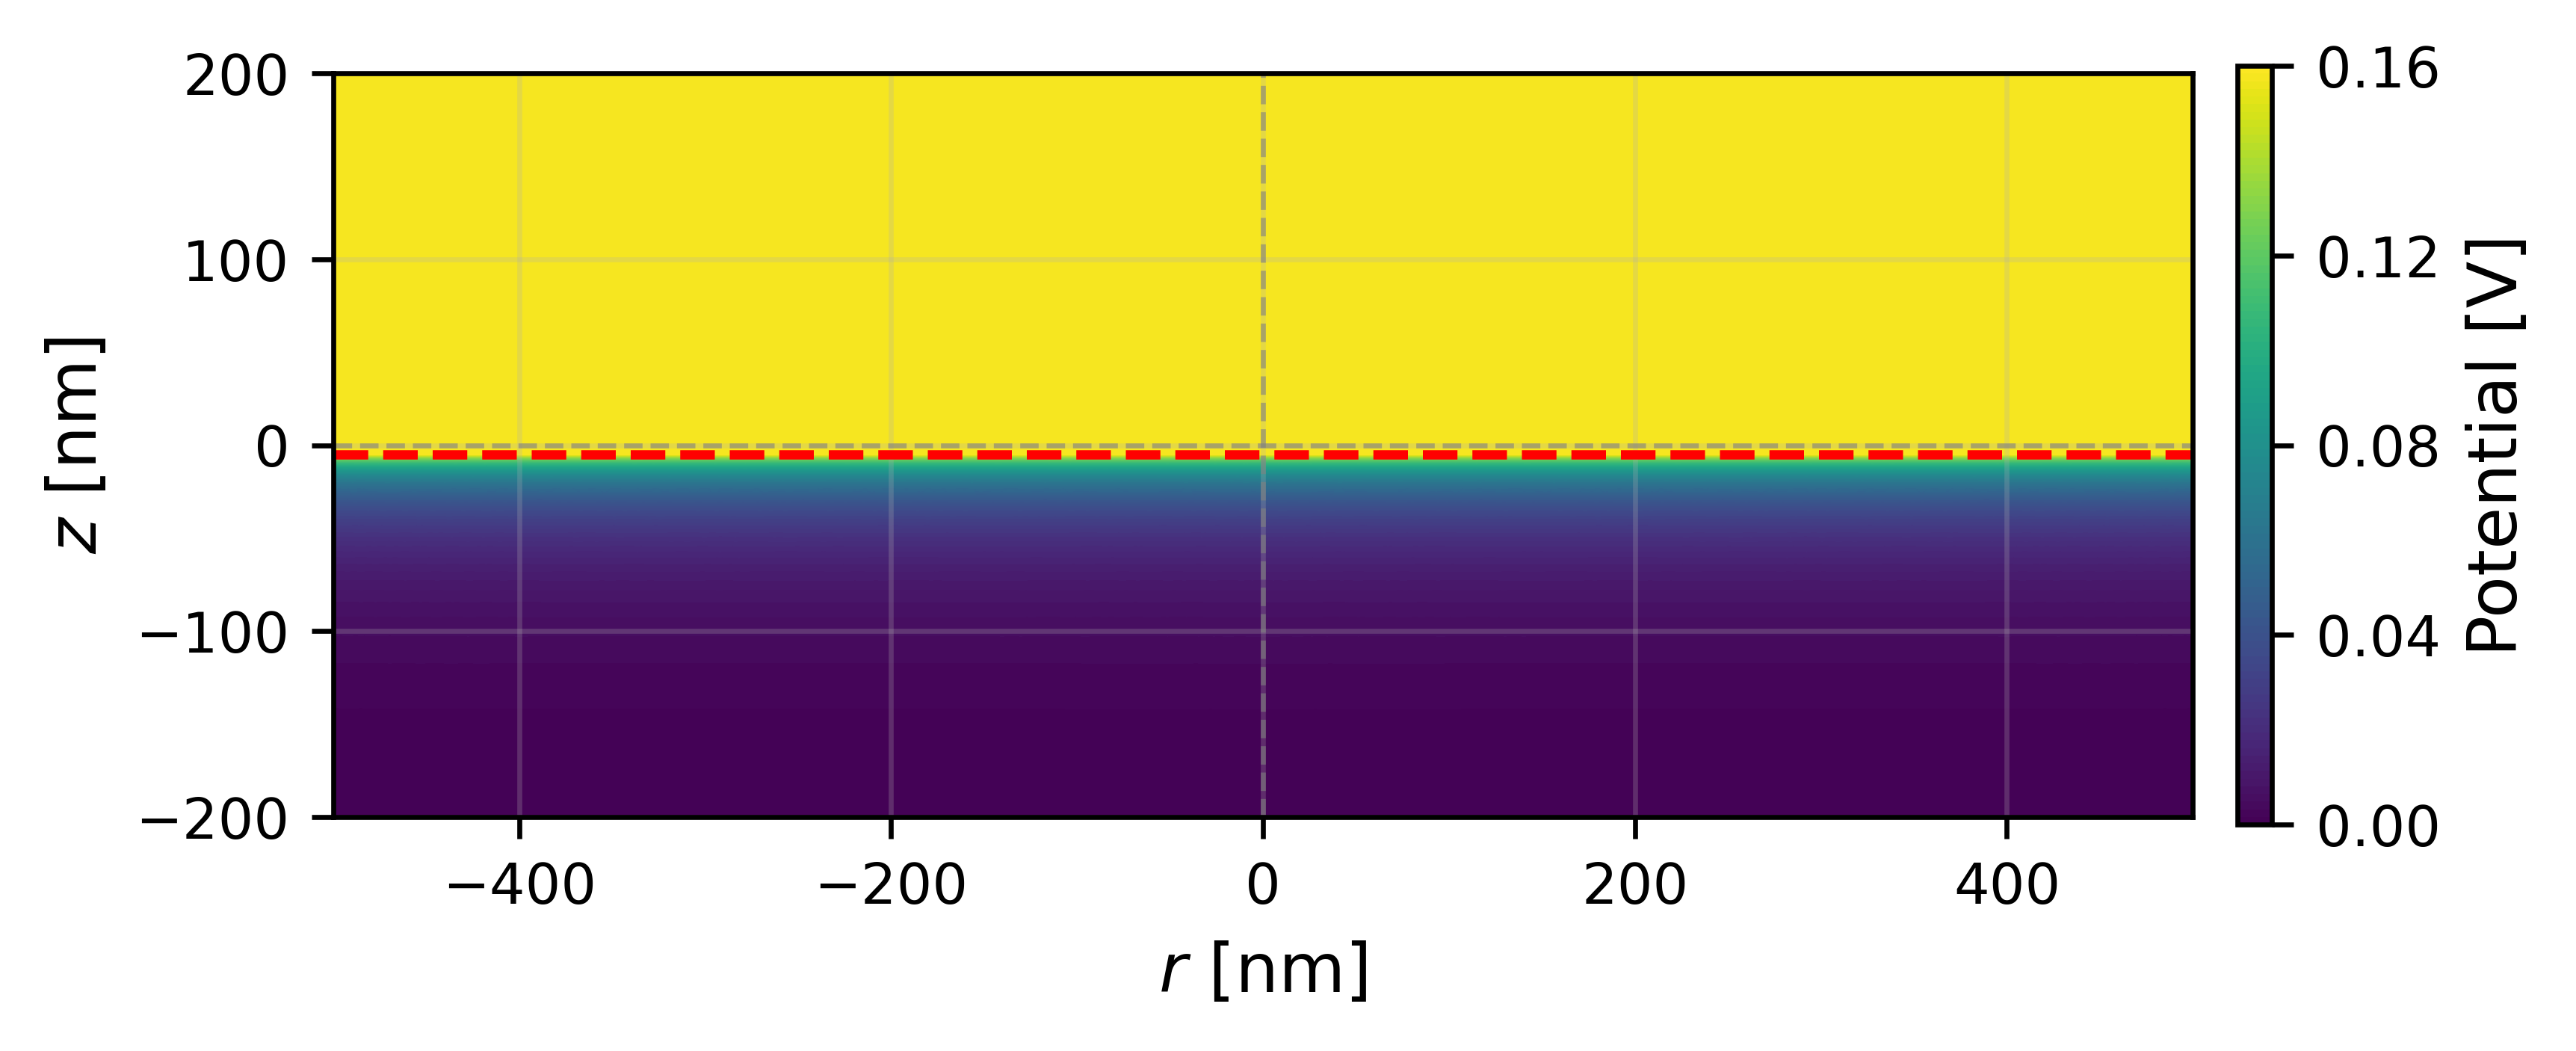

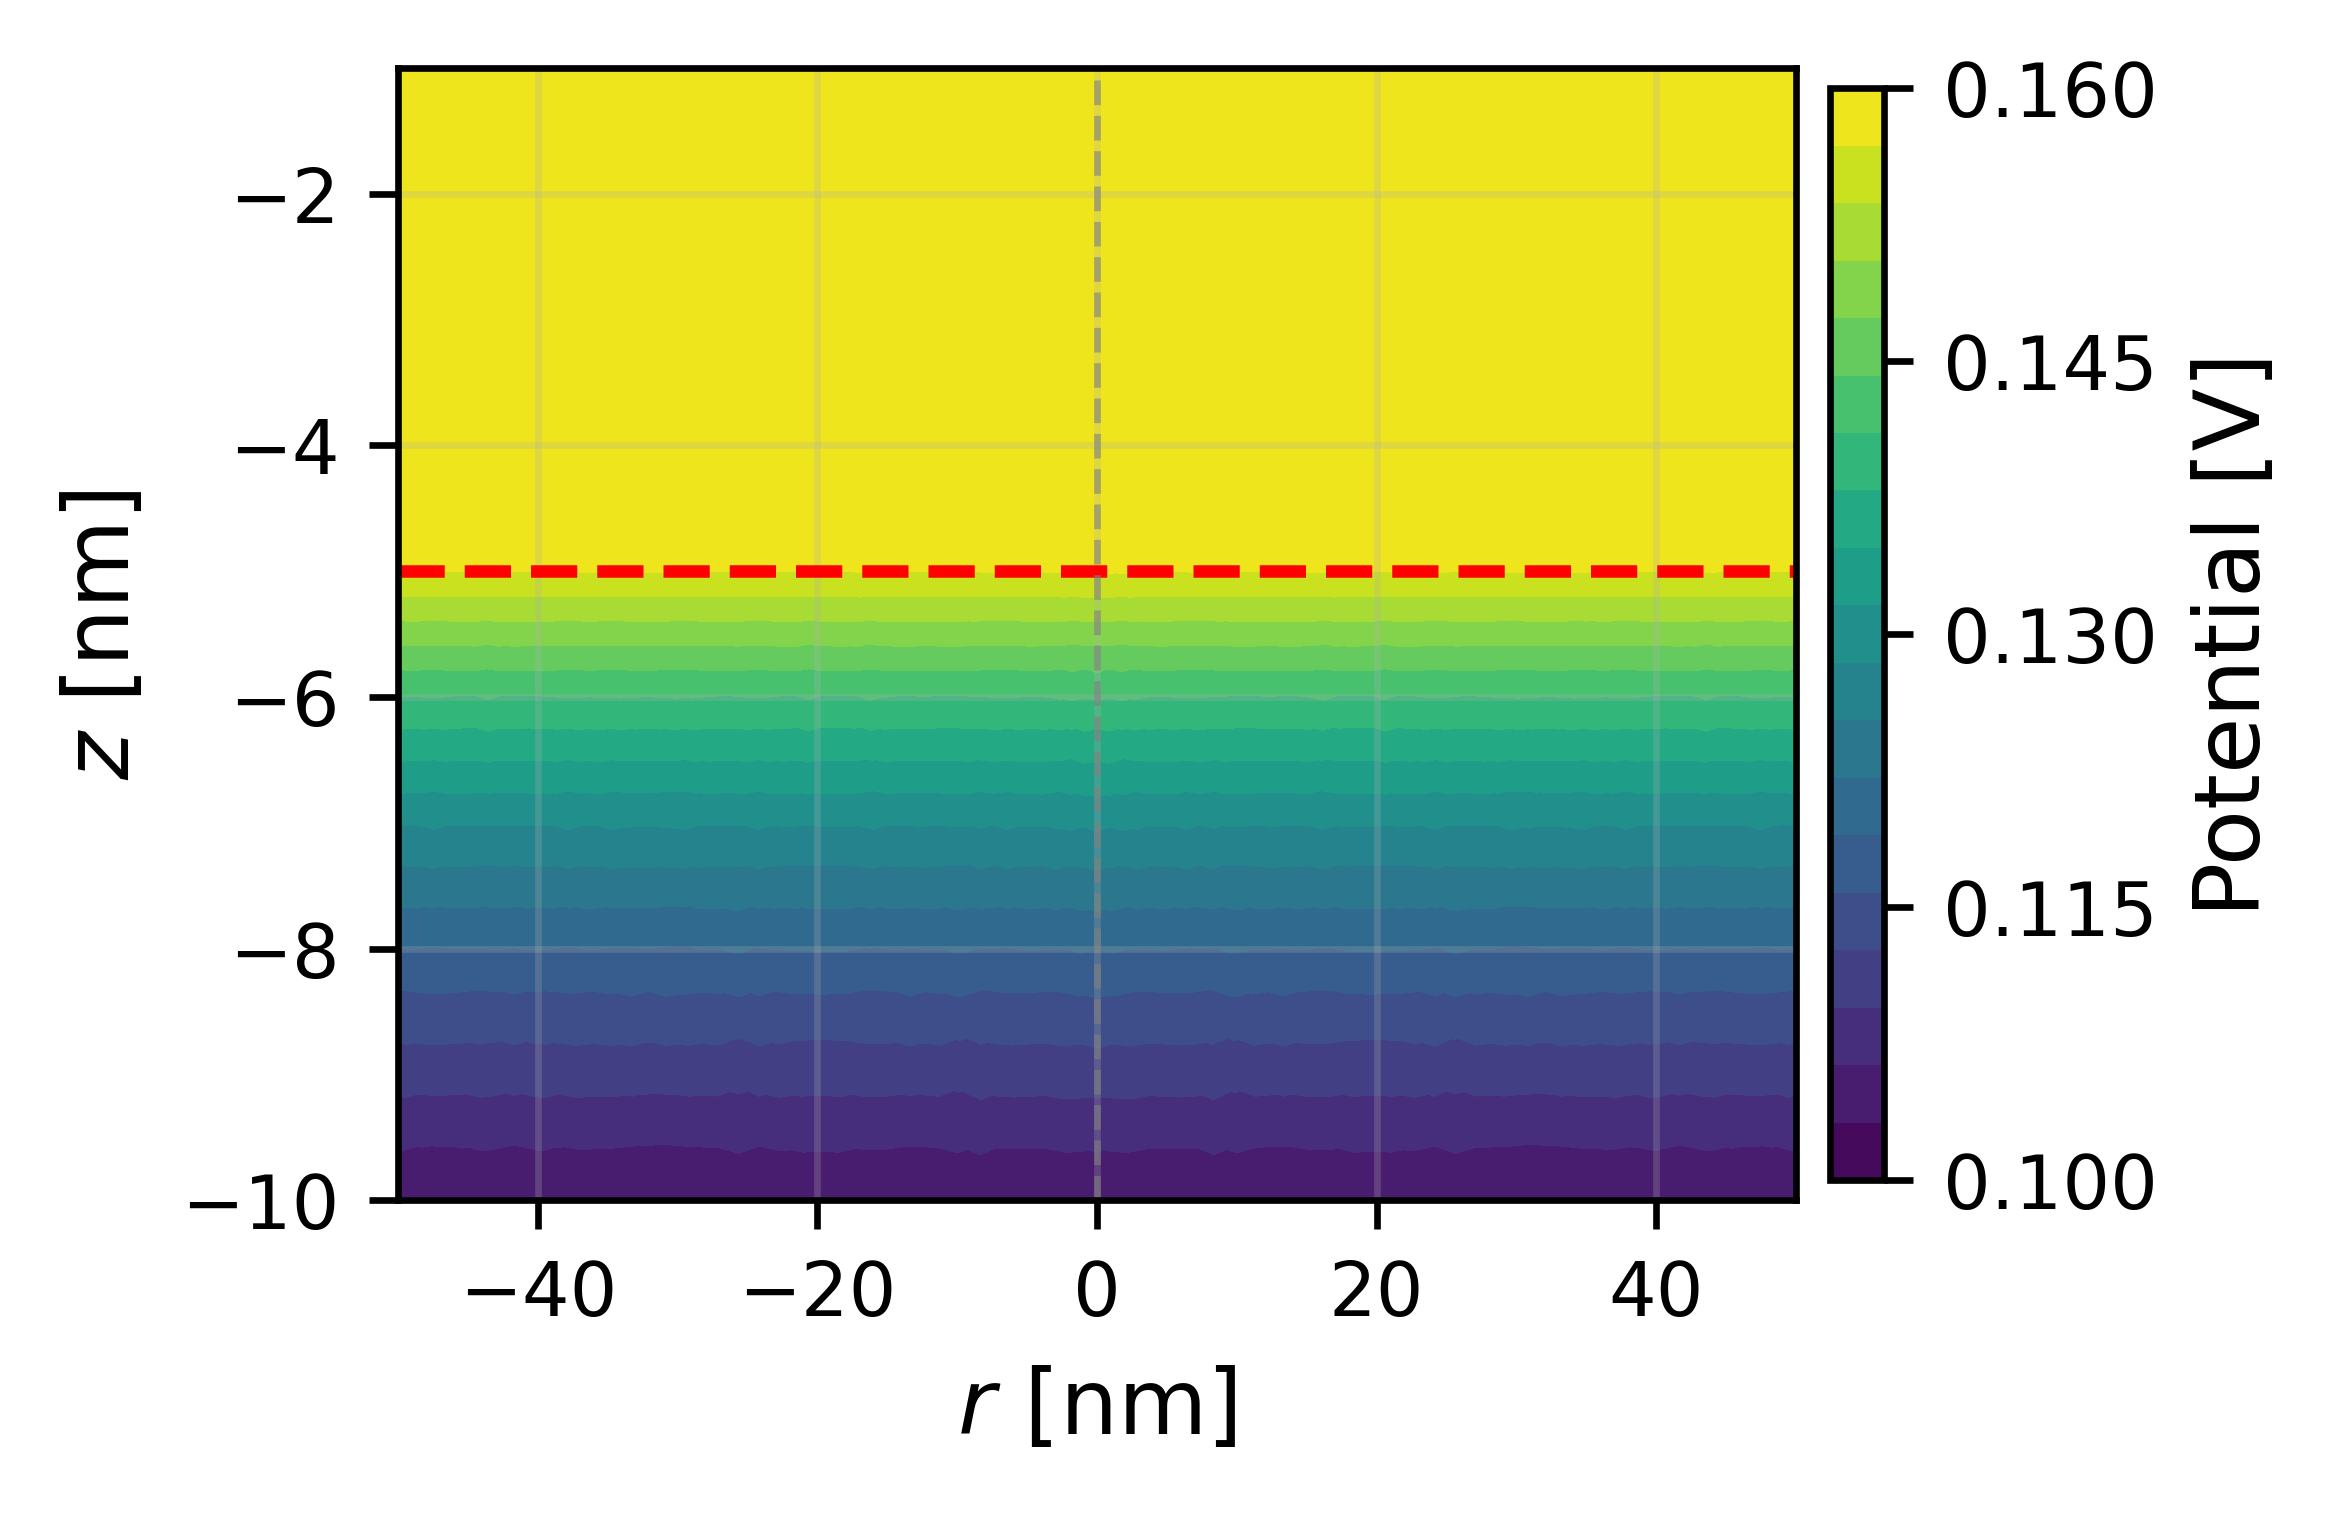

In [4]:
# ===== Plot potential map from "all nodes" CSV (x [nm], y [nm], u [V]) =====
# 必要: matplotlib, numpy, pandas（いずれも既に使っているはず）
# - CSV 例: 20250623/20250623_1412_u_all_nodes.csv
# - ドメインに穴（探針形状）があるので、Delaunay三角形の「長すぎる」三角形をマスクして穴埋めを抑制

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,        # 全体フォント
    "axes.titlesize": 12,   # タイトル
    "axes.labelsize": 11,   # 軸ラベル
    "xtick.labelsize": 9,   # 目盛り
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ==== 入力 ====
csv_path = Path("R_vs_V_out_ringA_V_tip+/20251109_1347_ALLNODES.csv")  # ここを自分の保存ファイルに
out_png  = csv_path.with_name(csv_path.stem + "_potential_map.png")

# 参考ライン（任意）
Y_SEMIVAC      = 0.0       # 真空/半導体境界
FILM_THICKNESS = 5.0       # SiO2 厚み [nm]
TIP_TO_SURFACE = 8.0       # 先端ギャップ [nm]（縦ライン用）
X_MIN, X_MAX   = -500.0, 500.0
Y_MIN, Y_MAX   = -200.0, 200.0

# ==== 読み込み ====
df = pd.read_csv(csv_path)
# 列名が 'x (nm)', 'y (nm)', 'u (V)' で保存されている想定（あなたのコード準拠）
colx = [c for c in df.columns if c.lower().startswith("x")][0]
coly = [c for c in df.columns if c.lower().startswith("y")][0]
colu = [c for c in df.columns if c.lower().startswith("u")][0]

x = df[colx].to_numpy(float)
y = df[coly].to_numpy(float)
u = df[colu].to_numpy(float)

# ==== 三角形分割（Delaunay） ====
tri = mtri.Triangulation(x, y)

# ---- “穴”を跨ぐ長すぎる三角形をマスク（ヒューリスティック） ----
# エッジ長の中央値から外れ値（三辺の最大長が閾値を超える三角形）を除外
tri_coords = np.column_stack([x, y])
triangles  = tri.triangles
p0 = tri_coords[triangles[:,0]]
p1 = tri_coords[triangles[:,1]]
p2 = tri_coords[triangles[:,2]]
L0 = np.linalg.norm(p1 - p0, axis=1)
L1 = np.linalg.norm(p2 - p1, axis=1)
L2 = np.linalg.norm(p0 - p2, axis=1)
Lmax = np.maximum.reduce([L0, L1, L2])
med  = np.median(Lmax)
thr  = med * 4   # 閾値倍率は 2.5~4.0 あたりで調整可
mask = Lmax > thr
# tri.set_mask(mask)

# ==== 描画 ====
fig, ax = plt.subplots(figsize=(6, 3), dpi=600)

# 等高線塗りつぶし（レベル数や範囲はお好みで）
VMIN, VMAX = 0, 0.159999           # 手動で指定
levels = np.linspace(VMIN, VMAX, 100)

tcf = ax.tricontourf(tri, u, levels=levels)
cbar = fig.colorbar(
    tcf, ax=ax, label="Potential [V]",
    shrink=0.65, pad=0.02, aspect=22,
    ticks=np.linspace(VMIN, VMAX, 5)   # 0, 0.02, ..., 0.10
)

# 目盛りも小さめ
cbar.ax.tick_params(labelsize=9)

# 等高線（細線）を重ねたい場合はコメント解除
# ax.tricontour(tri, u, levels=10, linewidths=0.5, colors='k', alpha=0.4)

# 参考ライン（任意）
ax.axhline(Y_SEMIVAC,      color="gray", ls="--", lw=0.8, alpha=0.6)
ax.axhline(-FILM_THICKNESS, color="r",   ls="--", alpha=1)
ax.axvline(0.0,            color="gray", ls="--", lw=0.8, alpha=0.6)
# axz.axhline(TIP_TO_SURFACE, color="tab:orange", ls="--", lw=0.8, alpha=0.6, label="tip apex height")

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("$r$ [nm]")
ax.set_ylabel("$z$ [nm]")
# ax.set_title("Electrostatic Potential map")
ax.grid(True, alpha=0.25)
# ax.legend(loc="center left", bbox_to_anchor=(1.2, 0.5), framealpha=0.9)

fig.tight_layout()
fig.savefig(out_png, bbox_inches="tight")
print(f"[viz] saved: {out_png}")


# ==== チップ周辺の拡大図を別グラフで ====
# 拡大する範囲（任意に調整）
xlim_tip = (-50, 50)  # nm
ylim_tip = (-10, -1)     # nm
rmin, rmax = xlim_tip
zmin, zmax = ylim_tip
r_span = rmax - rmin
z_span = zmax - zmin

fig_zoom, axz = plt.subplots(figsize=(4, 4), dpi=600)

kappa = 100.0   # r を 1/κ に圧縮して見せる（κ>1 で横を縮める）
axz.set_aspect( (z_span / r_span) * kappa )   # 数値は「z:x の比」

# ズーム図専用のカラーバー範囲
VMIN_ZOOM, VMAX_ZOOM = 0.1, 0.159999   # ここを自由に設定 (例: 0〜0.2 V)
levels_zoom = np.linspace(VMIN_ZOOM, VMAX_ZOOM, 20)

# メインとは独立した levels/norm を指定
tcf_zoom = axz.tricontourf(
    tri, u,
    levels=levels_zoom,
    vmin=VMIN_ZOOM, vmax=VMAX_ZOOM,
    cmap="viridis"
)

# 独立カラーバー
cbarz = fig_zoom.colorbar(
    tcf_zoom, ax=axz, label="Potential [V]",
    shrink=0.5, pad=0.02, aspect=20,
    ticks=np.linspace(VMIN_ZOOM, VMAX_ZOOM, 5)  # 0,0.05,0.10,0.15,0.20
)
cbarz.ax.tick_params(labelsize=9)

# 参考ライン（必要なものを再描画）
axz.axhline(Y_SEMIVAC,      color="gray", ls="--", lw=0.8, alpha=0.6, label="vac/SiO$_2$ boundary ($z=0$ nm)")
axz.axhline(-FILM_THICKNESS, color="r",  ls="--", alpha=1, label=f"SiO$_2$/SiC boundary ($z= -{FILM_THICKNESS}$ nm)")
axz.axvline(0.0,            color="gray", ls="--", lw=0.8, alpha=0.6)
# axz.axhline(TIP_TO_SURFACE, color="tab:orange", ls="--", lw=0.8, alpha=0.6, label="tip apex height")

axz.set_xlim(*xlim_tip)
axz.set_ylim(*ylim_tip)
axz.set_xlabel("$r$ [nm]")
axz.set_ylabel("$z$ [nm]")
# axz.set_title("Electrostatic Potential (Zoom near tip)")
axz.grid(True, alpha=0.25)

fig_zoom.tight_layout()
out_png_zoom = csv_path.with_name(csv_path.stem + "_potential_map_zoom.png")
fig_zoom.savefig(out_png_zoom, bbox_inches="tight")
print(f"[viz] saved: {out_png_zoom}")


[viz] saved: R_vs_V_out_ringA_V_tip+\20260202_1237_ALLNODES_potential_map.svg
[viz] saved: R_vs_V_out_ringA_V_tip+\20260202_1237_ALLNODES_potential_map_zoom.svg
[viz] saved: R_vs_V_out_ringA_V_tip+\20260202_1237_ALLNODES_potential_map_zoom.svg


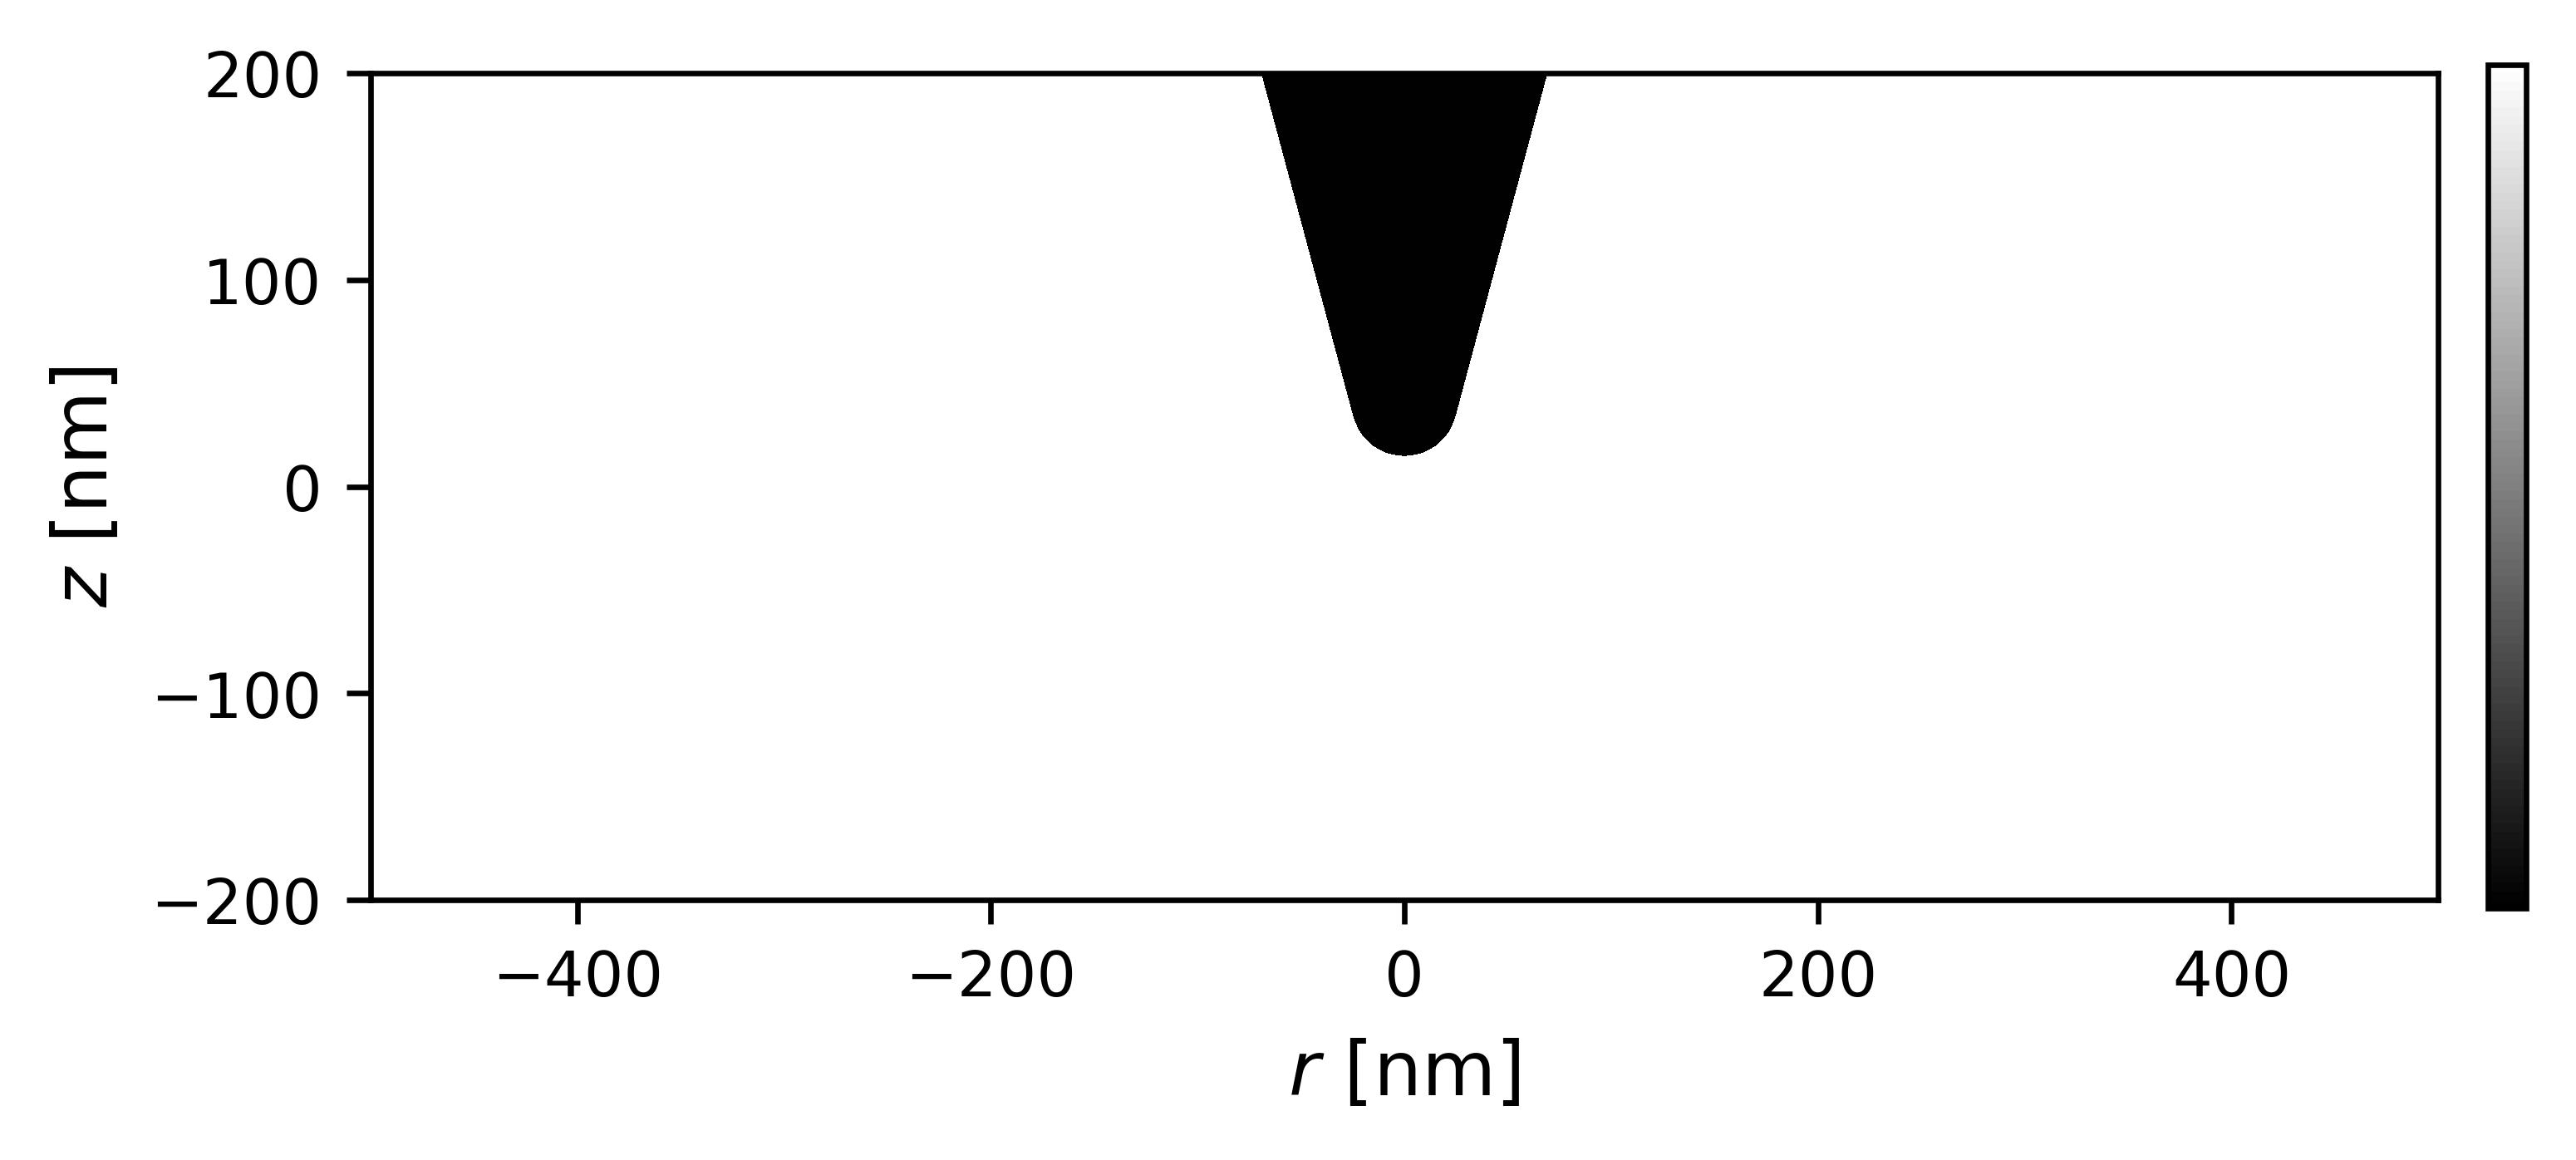

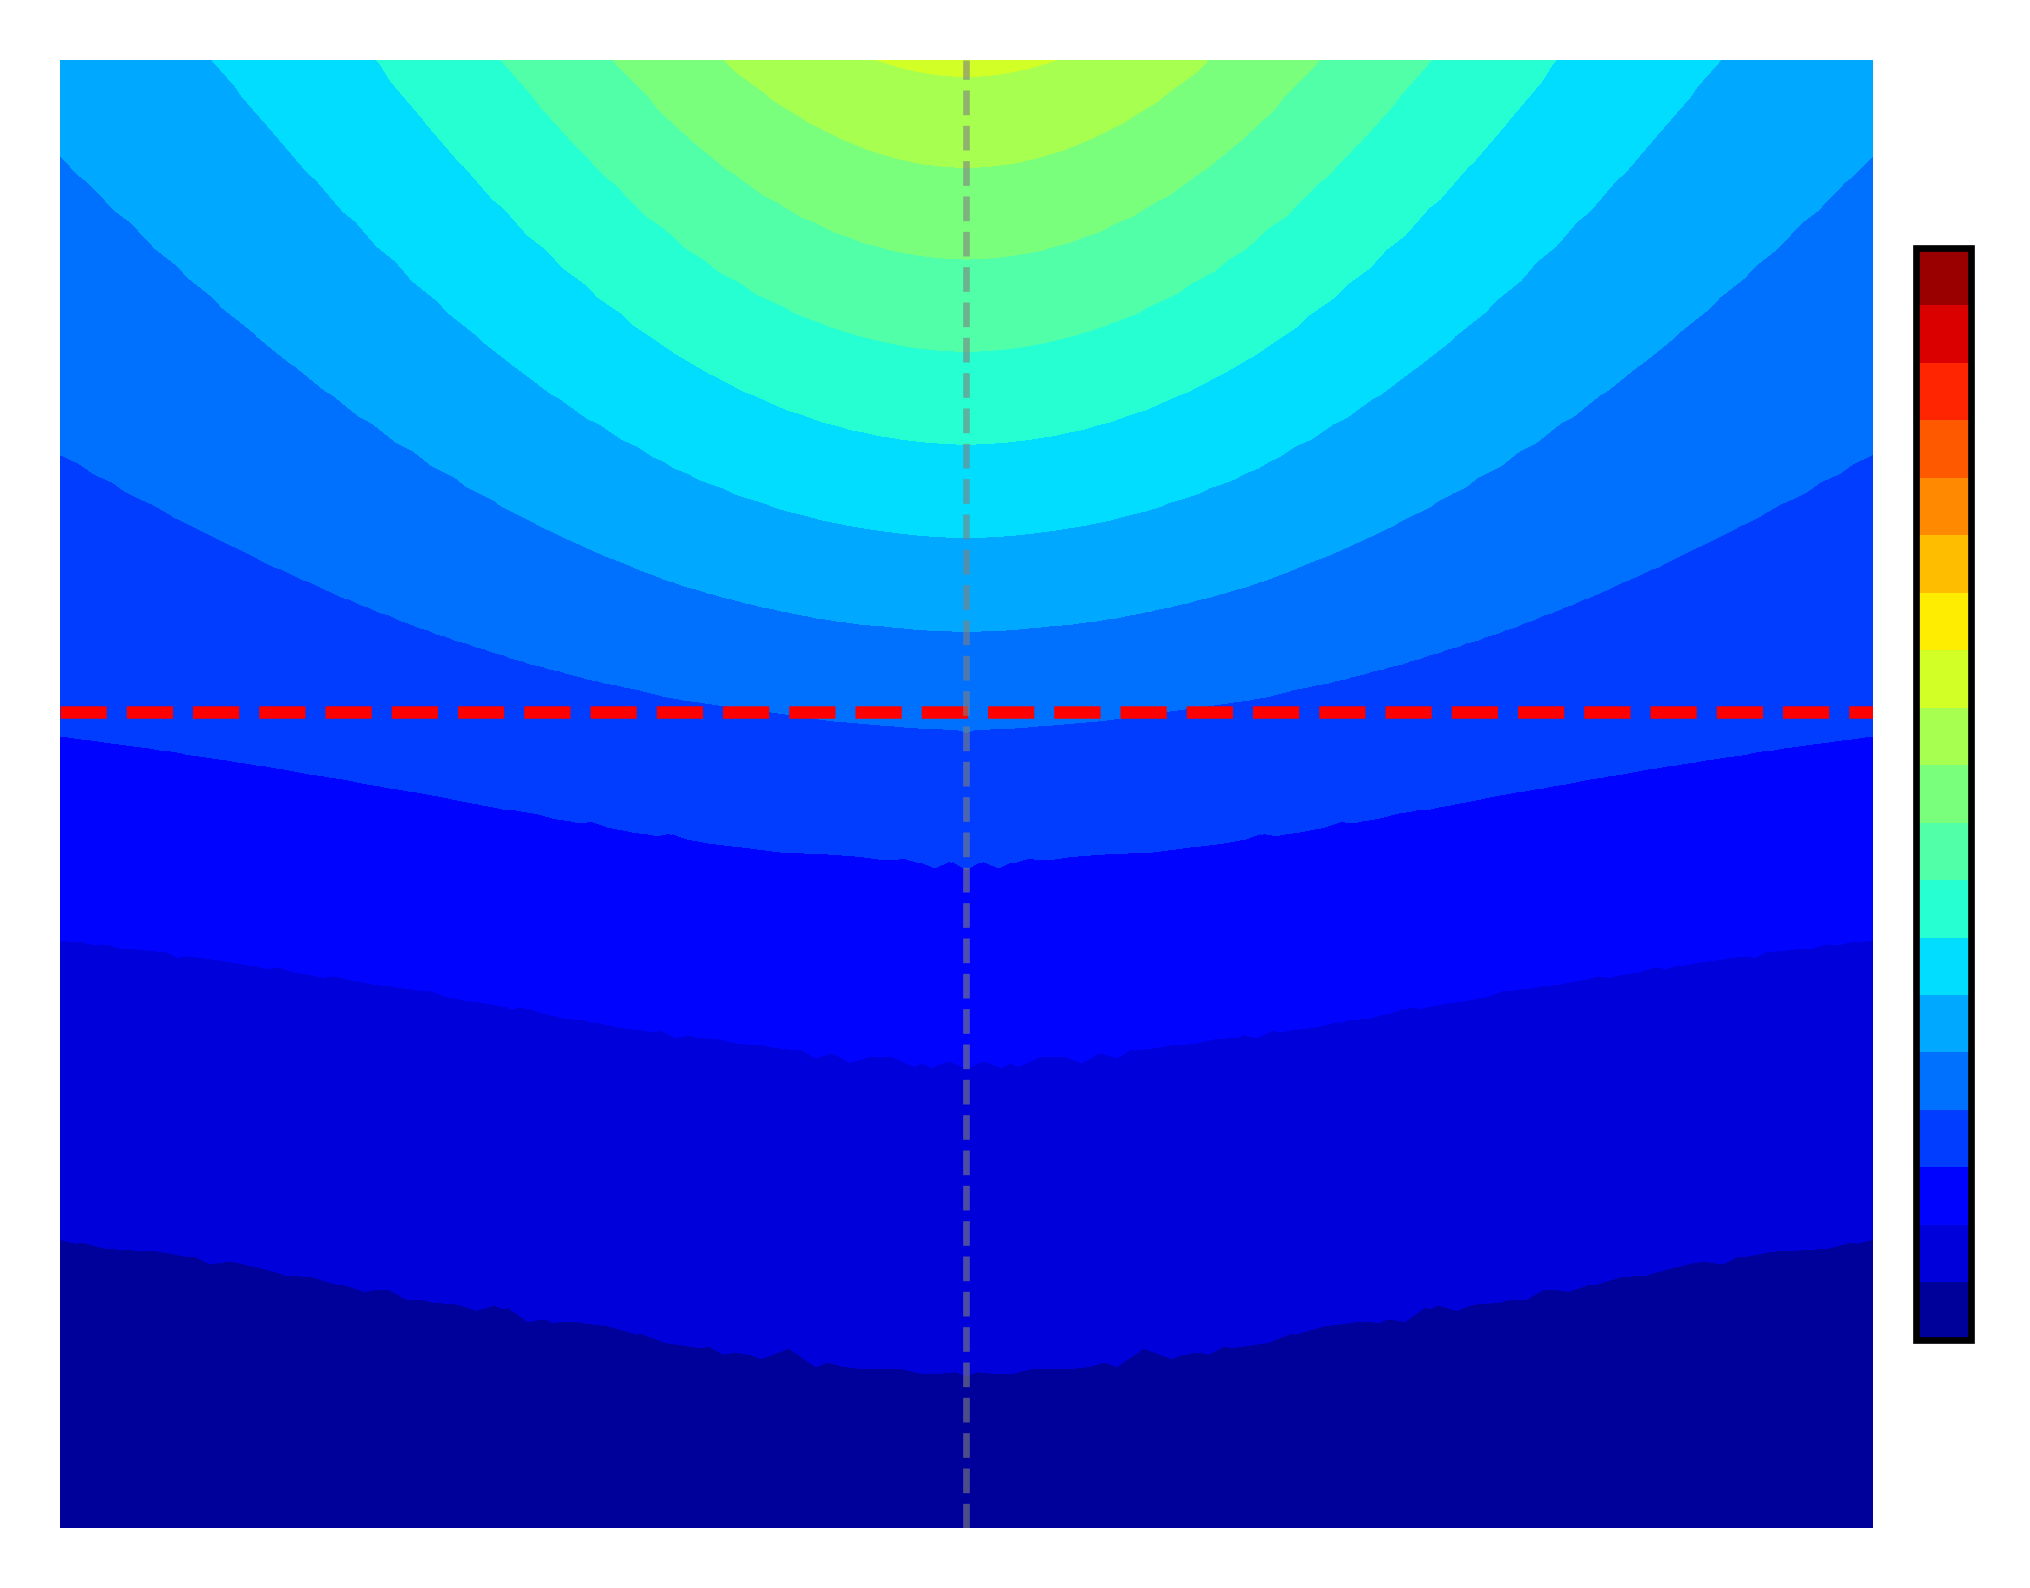

In [21]:
# ===== Plot potential map from "all nodes" CSV (x [nm], y [nm], u [V]) =====
# 必要: matplotlib, numpy, pandas（いずれも既に使っているはず）
# - CSV 例: 20250623/20250623_1412_u_all_nodes.csv
# - ドメインに穴（探針形状）があるので、Delaunay三角形の「長すぎる」三角形をマスクして穴埋めを抑制

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,        # 全体フォント
    "axes.titlesize": 12,   # タイトル
    "axes.labelsize": 11,   # 軸ラベル
    "xtick.labelsize": 9,   # 目盛り
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ==== 入力 ====
csv_path = Path("R_vs_V_out_ringA_V_tip+/20260202_1237_ALLNODES.csv")  # ここを自分の保存ファイルに
out_png  = csv_path.with_name(csv_path.stem + "_potential_map.svg")

# 参考ライン（任意）
Y_SEMIVAC      = 0.0       # 真空/半導体境界
FILM_THICKNESS = 5.0       # SiO2 厚み [nm]
TIP_TO_SURFACE = 8.0       # 先端ギャップ [nm]（縦ライン用）
X_MIN, X_MAX   = -500.0, 500.0
Y_MIN, Y_MAX   = -200.0, 200.0

# ==== 読み込み ====
df = pd.read_csv(csv_path)
# 列名が 'x (nm)', 'y (nm)', 'u (V)' で保存されている想定（あなたのコード準拠）
colx = [c for c in df.columns if c.lower().startswith("x")][0]
coly = [c for c in df.columns if c.lower().startswith("y")][0]
colu = [c for c in df.columns if c.lower().startswith("u")][0]

x = df[colx].to_numpy(float)
y = df[coly].to_numpy(float)
u = df[colu].to_numpy(float)

# ==== 三角形分割（Delaunay） ====
tri = mtri.Triangulation(x, y)

# ---- “穴”を跨ぐ長すぎる三角形をマスク（ヒューリスティック） ----
# エッジ長の中央値から外れ値（三辺の最大長が閾値を超える三角形）を除外
tri_coords = np.column_stack([x, y])
triangles  = tri.triangles
p0 = tri_coords[triangles[:,0]]
p1 = tri_coords[triangles[:,1]]
p2 = tri_coords[triangles[:,2]]
L0 = np.linalg.norm(p1 - p0, axis=1)
L1 = np.linalg.norm(p2 - p1, axis=1)
L2 = np.linalg.norm(p0 - p2, axis=1)
Lmax = np.maximum.reduce([L0, L1, L2])
med  = np.median(Lmax)
thr  = med * 4   # 閾値倍率は 2.5~4.0 あたりで調整可
mask = Lmax > thr
# tri.set_mask(mask)

# ==== 描画 ====
fig, ax = plt.subplots(figsize=(6, 3), dpi=600)

# 等高線塗りつぶし（レベル数や範囲はお好みで）
VMIN, VMAX = 3.3999999, 4           # 手動で指定
levels = np.linspace(VMIN, VMAX, 100)

tcf = ax.tricontourf(tri, u, levels=levels, cmap="gray")
cbar = fig.colorbar(
    tcf, ax=ax, label="Potential [V]",
    shrink=0.65, pad=0.02, aspect=22,
    ticks=np.linspace(VMIN, VMAX, 5)   # 0, 0.02, ..., 0.10
)

# ---- カラースケールの軸・ラベルを非表示（追加） ----
cbar.set_label("")
cbar.ax.set_yticks([])
cbar.ax.tick_params(left=False, labelleft=False)

# 等高線（細線）を重ねたい場合はコメント解除
# ax.tricontour(tri, u, levels=10, linewidths=0.5, colors='k', alpha=0.4)

# 参考ライン（任意）
# ax.axhline(Y_SEMIVAC,      color="gray", ls="--", lw=0.8, alpha=0.6)
# ax.axhline(-FILM_THICKNESS, color="r",  ls="--", alpha=1)
# ax.axvline(0.0,            color="gray", ls="--", lw=0.8, alpha=0.6)
# axz.axhline(TIP_TO_SURFACE, color="tab:orange", ls="--", lw=0.8, alpha=0.6, label="tip apex height")

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("$r$ [nm]")
ax.set_ylabel("$z$ [nm]")
# ax.set_title("Electrostatic Potential map")
# ax.grid(false, alpha=0.25)
# ax.legend(loc="center left", bbox_to_anchor=(1.2, 0.5), framealpha=0.9)

fig.tight_layout()
fig.savefig(out_png, bbox_inches="tight")
print(f"[viz] saved: {out_png}")


# ==== チップ周辺の拡大図を別グラフで ====
# 拡大する範囲（任意に調整）
xlim_tip = (-50, 50)  # nm
ylim_tip = (-10, -1)     # nm
rmin, rmax = xlim_tip
zmin, zmax = ylim_tip
r_span = rmax - rmin
z_span = zmax - zmin

fig_zoom, axz = plt.subplots(figsize=(4, 4), dpi=600)

kappa = 100.0   # r を 1/κ に圧縮して見せる（κ>1 で横を縮める）
axz.set_aspect((z_span / r_span) * kappa)   # 数値は「z:x の比」

# ズーム図専用のカラーバー範囲
VMIN_ZOOM, VMAX_ZOOM = 0.1, 0.525   # ここを自由に設定 (例: 0〜0.2 V)
levels_zoom = np.linspace(VMIN_ZOOM, VMAX_ZOOM, 20)

# メインとは独立した levels/norm を指定
tcf_zoom = axz.tricontourf(
    tri, u,
    levels=levels_zoom,
    vmin=VMIN_ZOOM, vmax=VMAX_ZOOM,
    cmap="jet"
)

# 独立カラーバー
cbarz = fig_zoom.colorbar(
    tcf_zoom, ax=axz, label="Potential [V]",
    shrink=0.5, pad=0.02, aspect=20,
    ticks=np.linspace(VMIN_ZOOM, VMAX_ZOOM, 4)  # 0,0.05,0.10,0.15,0.20
)

# ---- カラースケールの軸・ラベルを非表示（追加） ----
cbarz.set_label("")
cbarz.ax.set_yticks([])
cbarz.ax.tick_params(left=False, labelleft=False)

# 参考ライン（必要なものを再描画）
axz.axhline(Y_SEMIVAC,      color="gray", ls="--", lw=0.8, alpha=0.6, label="vac/SiO$_2$ boundary ($z=0$ nm)")
axz.axhline(-FILM_THICKNESS, color="r",  ls="--", alpha=1, label=f"SiO$_2$/SiC boundary ($z= -{FILM_THICKNESS}$ nm)")
axz.axvline(0.0,            color="gray", ls="--", lw=0.8, alpha=0.6)
# axz.axhline(TIP_TO_SURFACE, color="tab:orange", ls="--", lw=0.8, alpha=0.6, label="tip apex height")

axz.set_xlim(*xlim_tip)
axz.set_ylim(*ylim_tip)

# ---- zoom の軸・ラベルを非表示（追加） ----
axz.set_xlabel("")
axz.set_ylabel("")
axz.set_xticks([])
axz.set_yticks([])
axz.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
for sp in axz.spines.values():
    sp.set_visible(False)

# axz.set_title("Electrostatic Potential (Zoom near tip)")
axz.grid(True, alpha=0.25)

fig_zoom.tight_layout()
out_png_zoom = csv_path.with_name(csv_path.stem + "_potential_map_zoom.svg")
fig_zoom.savefig(out_png_zoom, bbox_inches="tight")
print(f"[viz] saved: {out_png_zoom}")

axz.grid(True, alpha=0.25)

fig_zoom.tight_layout()
out_png_zoom = csv_path.with_name(csv_path.stem + "_potential_map_zoom.svg")
fig_zoom.savefig(out_png_zoom, bbox_inches="tight")
print(f"[viz] saved: {out_png_zoom}")


[viz] saved: R_vs_V_out_ringA_V_tip+\20251123_1219_ALLNODES_potential_map.png
[viz] saved: R_vs_V_out_ringA_V_tip+\20251123_1219_ALLNODES_potential_map_zoom.png


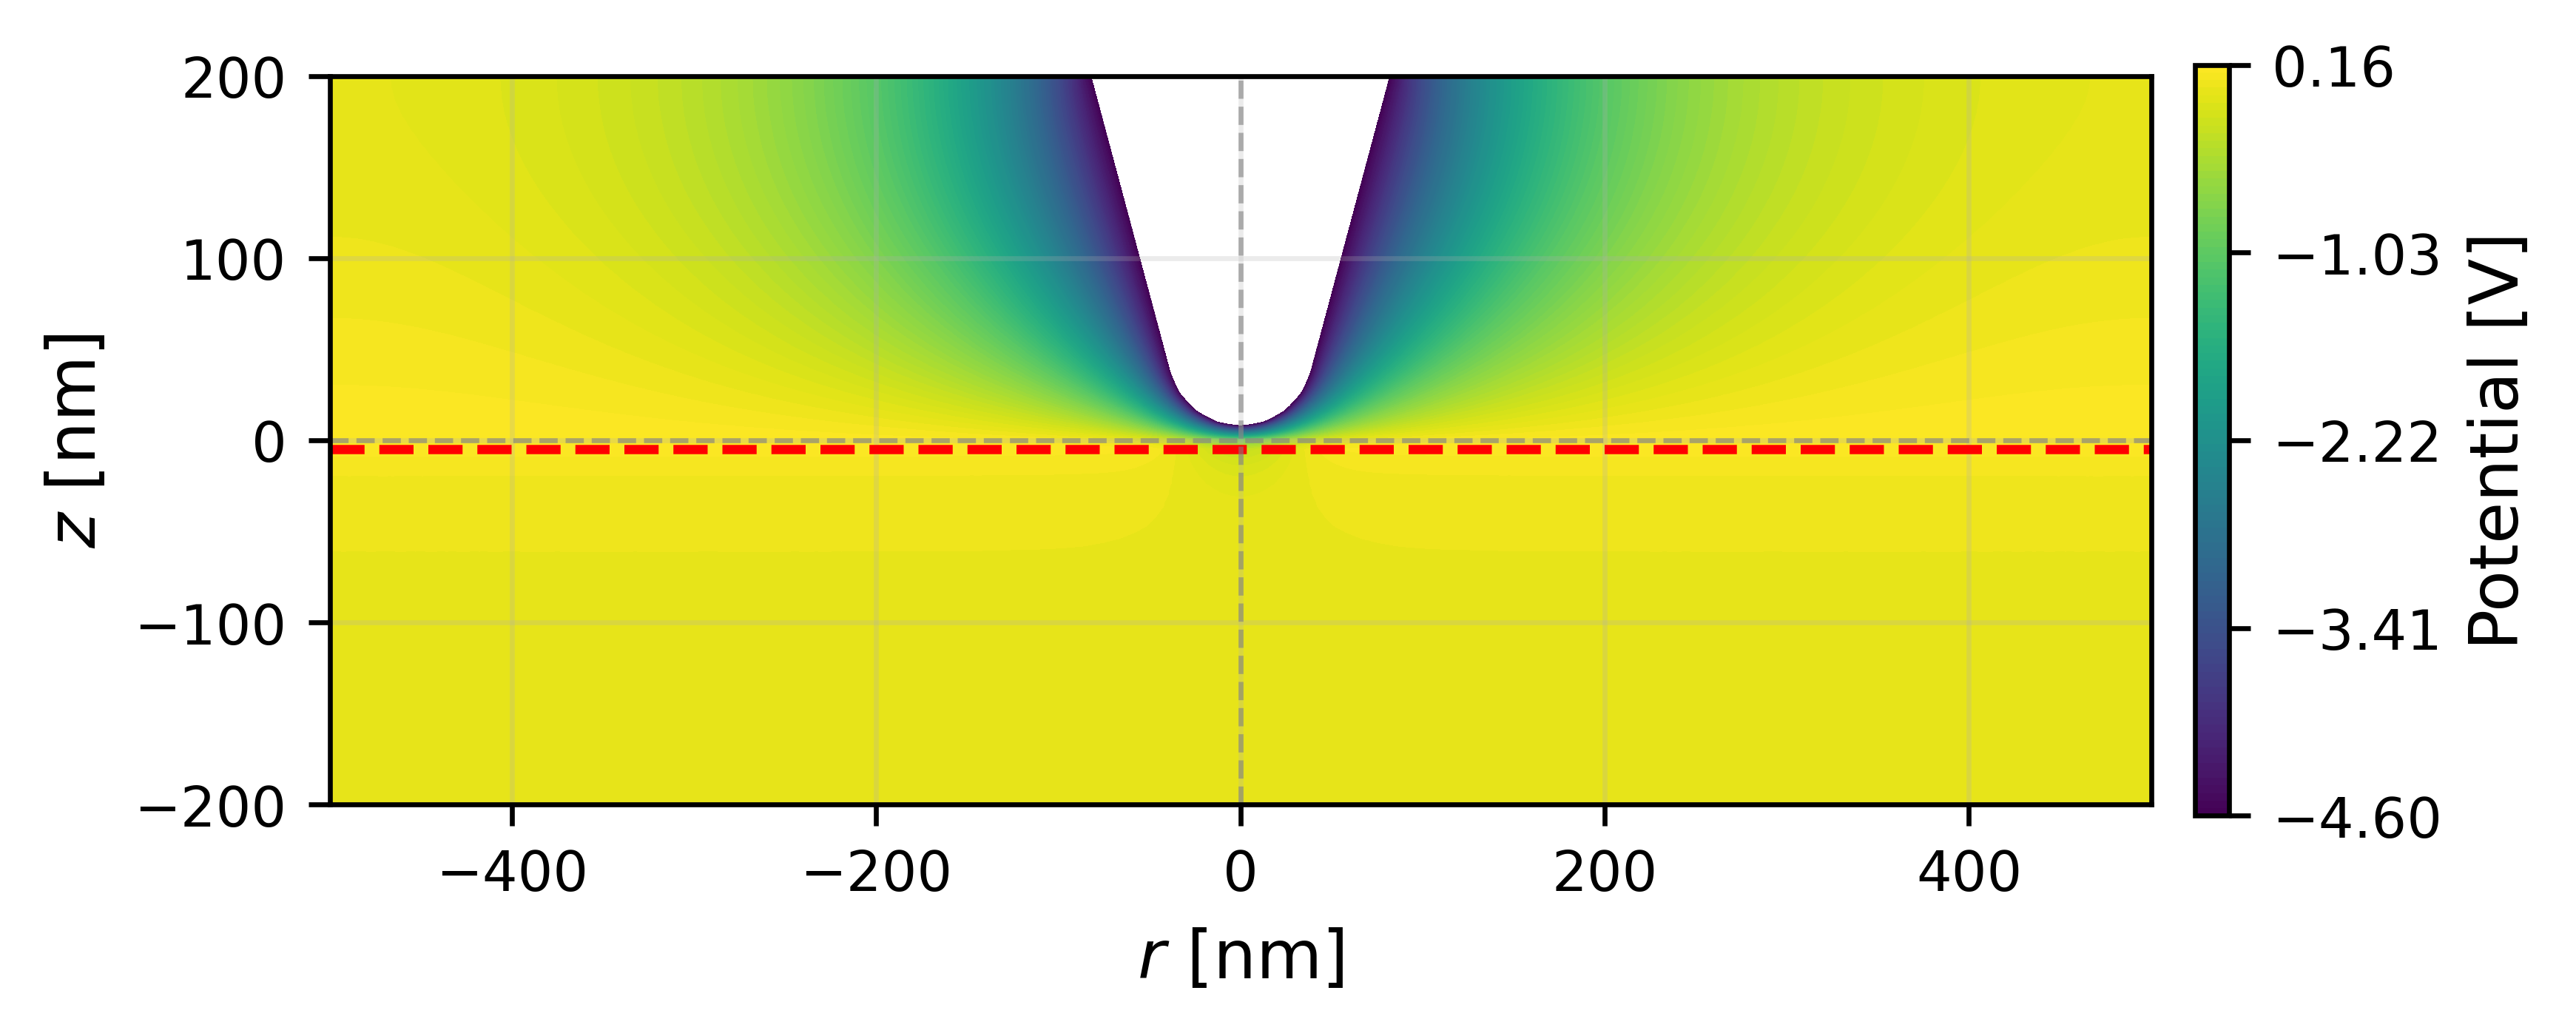

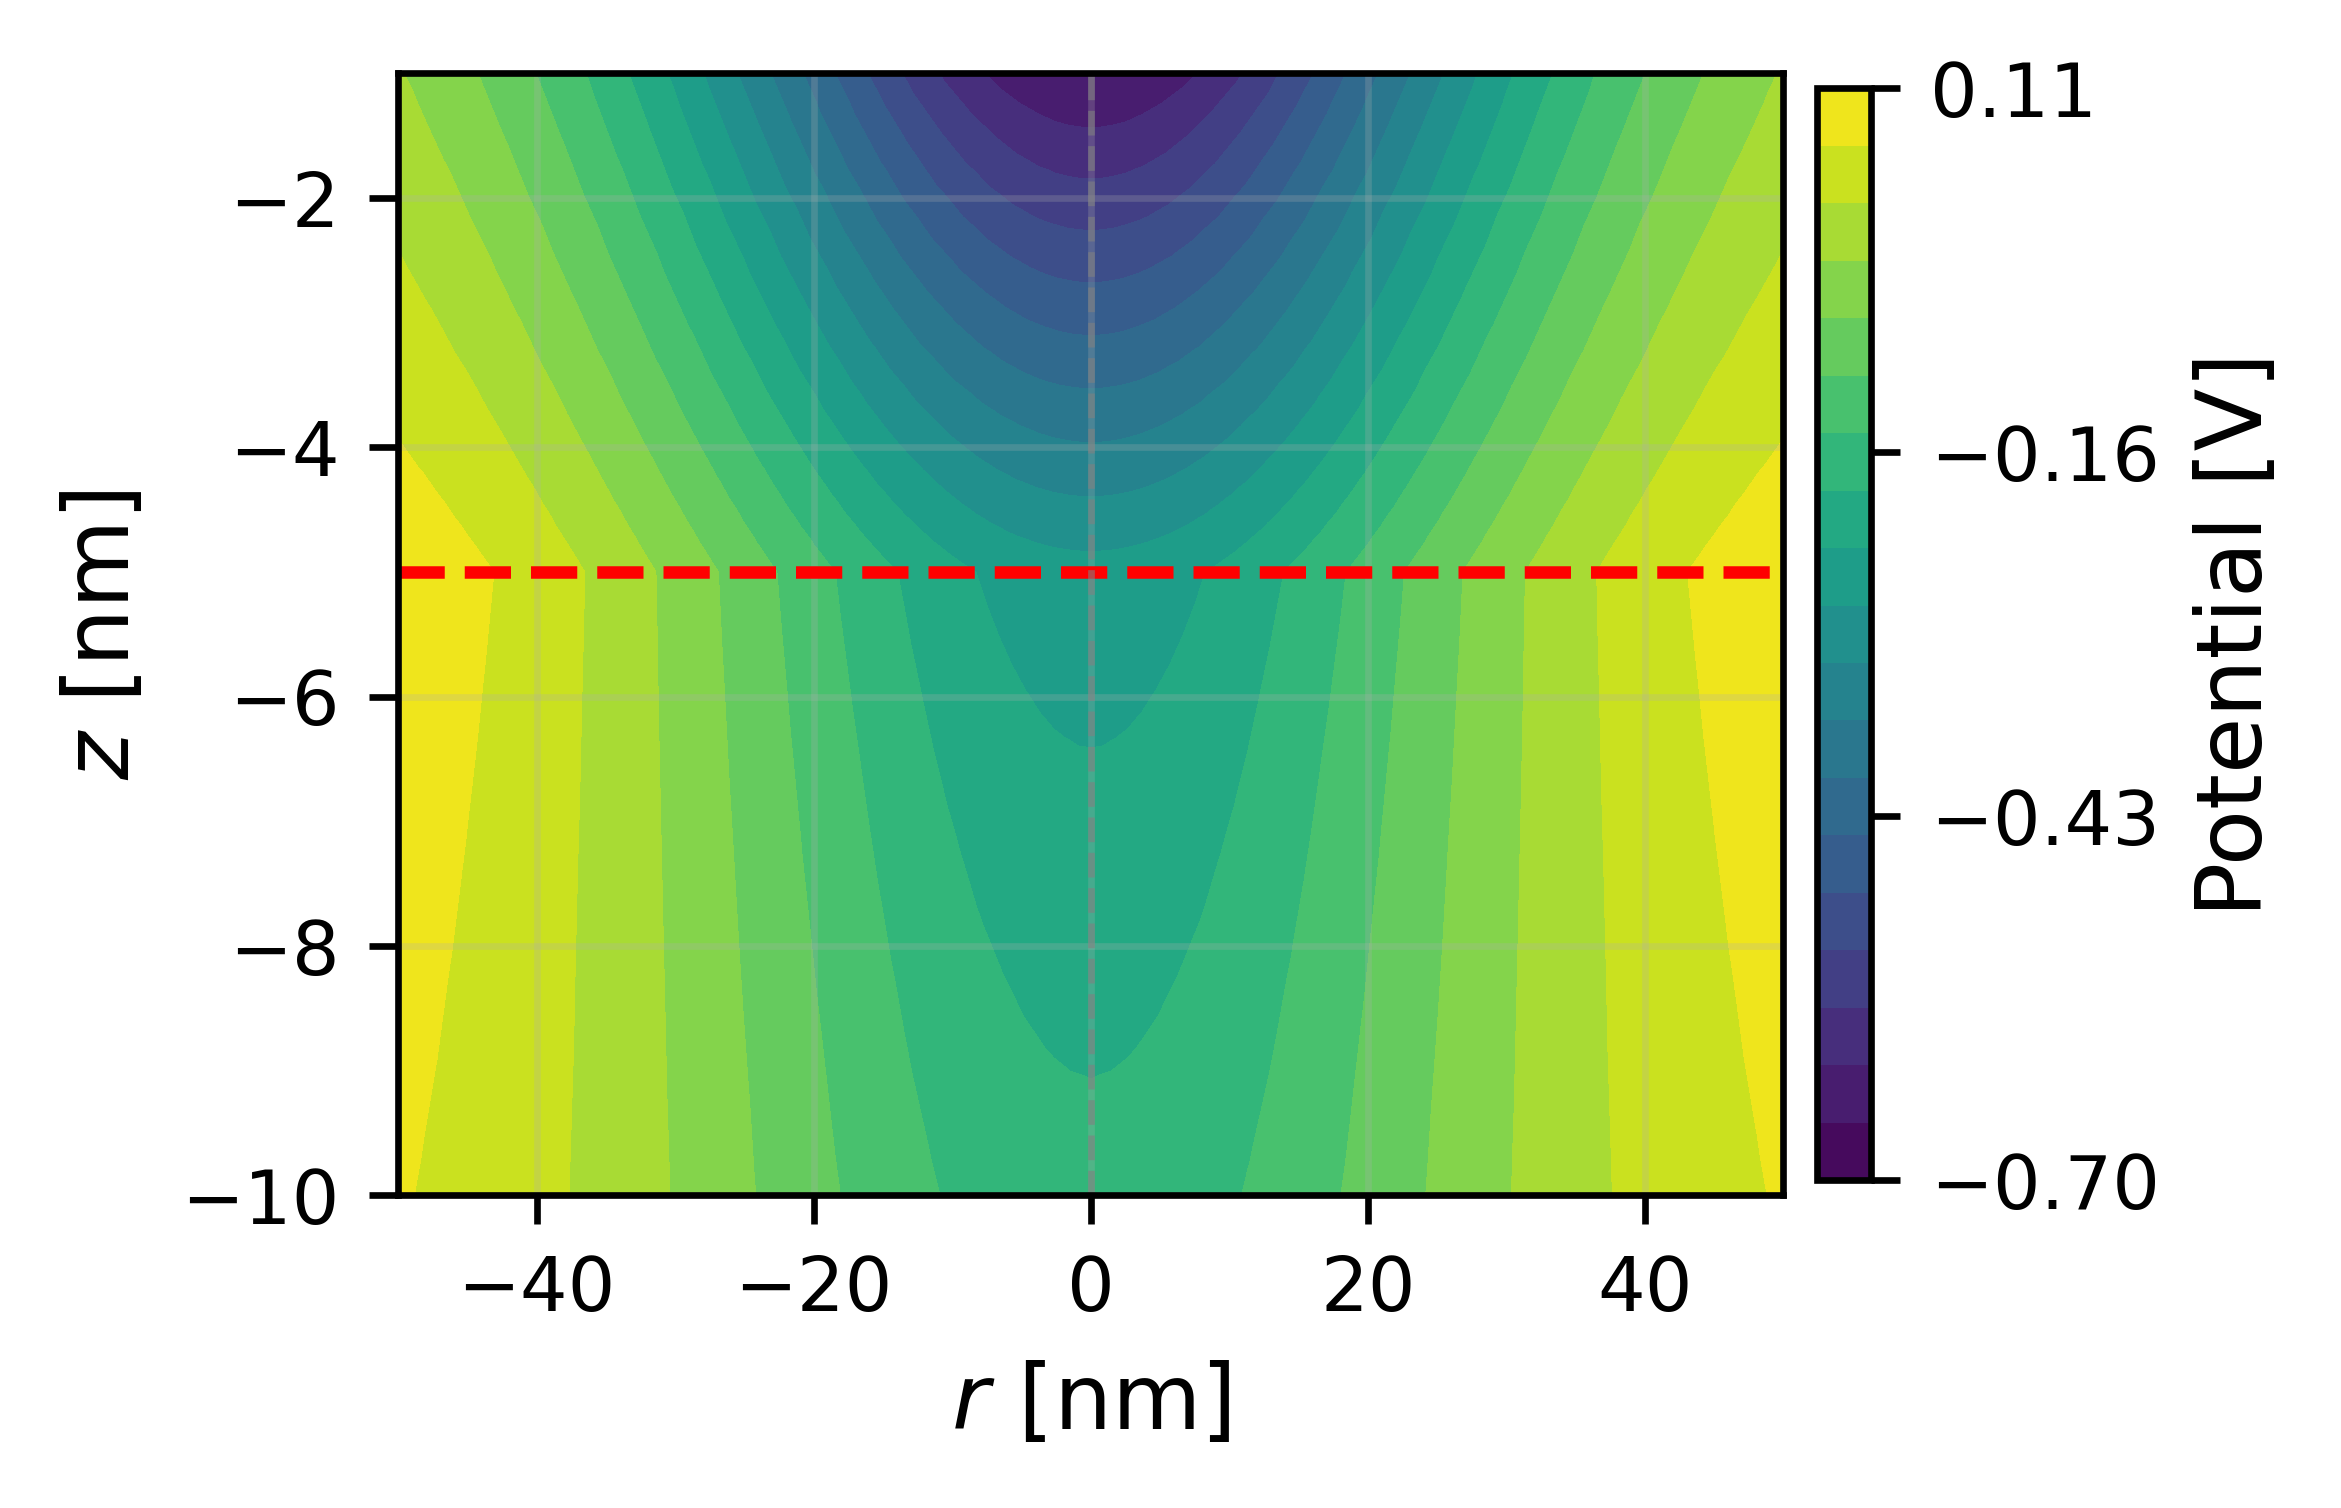

In [16]:
# ===== Plot potential map from "all nodes" CSV (x [nm], y [nm], u [V]) =====
# 必要: matplotlib, numpy, pandas（いずれも既に使っているはず）
# - CSV 例: 20250623/20250623_1412_u_all_nodes.csv
# - ドメインに穴（探針形状）があるので、Delaunay三角形の「長すぎる」三角形をマスクして穴埋めを抑制

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,        # 全体フォント
    "axes.titlesize": 12,   # タイトル
    "axes.labelsize": 11,   # 軸ラベル
    "xtick.labelsize": 9,   # 目盛り
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ==== 入力 ====
csv_path = Path("R_vs_V_out_ringA_V_tip+/20251123_1219_ALLNODES.csv")  # ここを自分の保存ファイルに
out_png  = csv_path.with_name(csv_path.stem + "_potential_map.png")

# 参考ライン（任意）
Y_SEMIVAC      = 0.0       # 真空/半導体境界
FILM_THICKNESS = 5.0       # SiO2 厚み [nm]
TIP_TO_SURFACE = 8.0       # 先端ギャップ [nm]（縦ライン用）
X_MIN, X_MAX   = -500.0, 500.0
Y_MIN, Y_MAX   = -200.0, 200.0

# ==== 読み込み ====
df = pd.read_csv(csv_path)
# 列名が 'x (nm)', 'y (nm)', 'u (V)' で保存されている想定（あなたのコード準拠）
colx = [c for c in df.columns if c.lower().startswith("x")][0]
coly = [c for c in df.columns if c.lower().startswith("y")][0]
colu = [c for c in df.columns if c.lower().startswith("u")][0]

x = df[colx].to_numpy(float)
y = df[coly].to_numpy(float)
u = df[colu].to_numpy(float)

# ==== 三角形分割（Delaunay） ====
tri = mtri.Triangulation(x, y)

# ---- “穴”を跨ぐ長すぎる三角形をマスク（ヒューリスティック） ----
# エッジ長の中央値から外れ値（三辺の最大長が閾値を超える三角形）を除外
tri_coords = np.column_stack([x, y])
triangles  = tri.triangles
p0 = tri_coords[triangles[:,0]]
p1 = tri_coords[triangles[:,1]]
p2 = tri_coords[triangles[:,2]]
L0 = np.linalg.norm(p1 - p0, axis=1)
L1 = np.linalg.norm(p2 - p1, axis=1)
L2 = np.linalg.norm(p0 - p2, axis=1)
Lmax = np.maximum.reduce([L0, L1, L2])
med  = np.median(Lmax)
thr  = med * 4   # 閾値倍率は 2.5~4.0 あたりで調整可
mask = Lmax > thr
# tri.set_mask(mask)

# ==== 描画 ====
fig, ax = plt.subplots(figsize=(6, 3), dpi=600)

# 等高線塗りつぶし（レベル数や範囲はお好みで）
VMIN, VMAX = -4.5999, 0.16           # 手動で指定
levels = np.linspace(VMIN, VMAX, 100)

tcf = ax.tricontourf(tri, u, levels=levels)
cbar = fig.colorbar(
    tcf, ax=ax, label="Potential [V]",
    shrink=0.65, pad=0.02, aspect=22,
    ticks=np.linspace(VMIN, VMAX, 5)   # 0, 0.02, ..., 0.10
)

# 目盛りも小さめ
cbar.ax.tick_params(labelsize=9)

# 等高線（細線）を重ねたい場合はコメント解除
# ax.tricontour(tri, u, levels=10, linewidths=0.5, colors='k', alpha=0.4)

# 参考ライン（任意）
ax.axhline(Y_SEMIVAC,      color="gray", ls="--", lw=0.8, alpha=0.6)
ax.axhline(-FILM_THICKNESS, color="r",  ls="--", alpha=1)
ax.axvline(0.0,            color="gray", ls="--", lw=0.8, alpha=0.6)
# axz.axhline(TIP_TO_SURFACE, color="tab:orange", ls="--", lw=0.8, alpha=0.6, label="tip apex height")

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("$r$ [nm]")
ax.set_ylabel("$z$ [nm]")
# ax.set_title("Electrostatic Potential map")
ax.grid(True, alpha=0.25)
# ax.legend(loc="center left", bbox_to_anchor=(1.2, 0.5), framealpha=0.9)

fig.tight_layout()
fig.savefig(out_png, bbox_inches="tight")
print(f"[viz] saved: {out_png}")


# ==== チップ周辺の拡大図を別グラフで ====
# 拡大する範囲（任意に調整）
xlim_tip = (-50, 50)  # nm
ylim_tip = (-10, -1)     # nm
rmin, rmax = xlim_tip
zmin, zmax = ylim_tip
r_span = rmax - rmin
z_span = zmax - zmin

fig_zoom, axz = plt.subplots(figsize=(4, 4), dpi=600)

kappa = 100.0   # r を 1/κ に圧縮して見せる（κ>1 で横を縮める）
axz.set_aspect( (z_span / r_span) * kappa )   # 数値は「z:x の比」

# ズーム図専用のカラーバー範囲
VMIN_ZOOM, VMAX_ZOOM = -0.7, 0.11   # ここを自由に設定 (例: 0〜0.2 V)
levels_zoom = np.linspace(VMIN_ZOOM, VMAX_ZOOM, 20)

# メインとは独立した levels/norm を指定
tcf_zoom = axz.tricontourf(
    tri, u,
    levels=levels_zoom,
    vmin=VMIN_ZOOM, vmax=VMAX_ZOOM,
    cmap="viridis"
)

# 独立カラーバー
cbarz = fig_zoom.colorbar(
    tcf_zoom, ax=axz, label="Potential [V]",
    shrink=0.5, pad=0.02, aspect=20,
    ticks=np.linspace(VMIN_ZOOM, VMAX_ZOOM, 4)  # 0,0.05,0.10,0.15,0.20
)
cbarz.ax.tick_params(labelsize=9)

# 参考ライン（必要なものを再描画）
axz.axhline(Y_SEMIVAC,      color="gray", ls="--", lw=0.8, alpha=0.6, label="vac/SiO$_2$ boundary ($z=0$ nm)")
axz.axhline(-FILM_THICKNESS, color="r",  ls="--", alpha=1, label=f"SiO$_2$/SiC boundary ($z= -{FILM_THICKNESS}$ nm)")
axz.axvline(0.0,            color="gray", ls="--", lw=0.8, alpha=0.6)
# axz.axhline(TIP_TO_SURFACE, color="tab:orange", ls="--", lw=0.8, alpha=0.6, label="tip apex height")

axz.set_xlim(*xlim_tip)
axz.set_ylim(*ylim_tip)
axz.set_xlabel("$r$ [nm]")
axz.set_ylabel("$z$ [nm]")
# axz.set_title("Electrostatic Potential (Zoom near tip)")
axz.grid(True, alpha=0.25)

fig_zoom.tight_layout()
out_png_zoom = csv_path.with_name(csv_path.stem + "_potential_map_zoom.png")
fig_zoom.savefig(out_png_zoom, bbox_inches="tight")
print(f"[viz] saved: {out_png_zoom}")


[INFO] saved: R_vs_V_out\20251219_1556_line_profile_r0_s_scan.png
[INFO] saved: R_vs_V_out\20251219_1556_r_profile_z-5nm_Vtip_scan.png


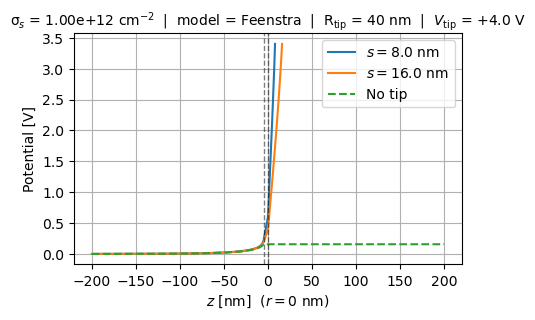

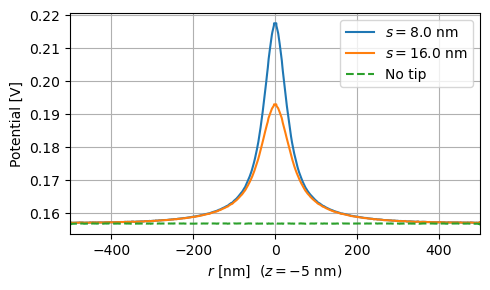

In [23]:
# -*- coding: utf-8 -*-
# Compute R(Vtip) at a fixed tip-sample distance using Feenstra/Boltzmann core.
# - CPD を実験値で補正: 計算は V_applied = V_tip - CPD を使用（出力・表示は元の V_tip 表記）
# - Saves base R(Vtip) (R>=0), and a mirrored symmetric discrete CSV (±R) as well.
# - Also saves per-level CSVs.
# - Draw(u) の単位切り替え: V / eV（同値）/ kT(無次元)
# - 新機能: r=0 のラインプロファイルを V_tip=±4 V, チップ無し の3ケースで重ね描き
# - 追加: z = -5 nm (SiO2/SiC界面) の r 方向プロファイル（r<0は補完）を A/B/C まとめて描画

import argparse, os, json, csv, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
import ngsolve as ng
from ngsolve.solvers import Newton
from netgen.geom2d import SplineGeometry
from scipy.optimize import brentq
from ngsolve.webgui import Draw
from dataclasses import asdict, dataclass

# ---------------- Core FEM (Feenstra/Boltzmann) ----------------

@dataclass
class PhysicalParameters:
    T: float = 300.0; Nd: float = 1e22; Na: float = 0.0; sigma_s: float = 1e16
    m_de: float = 0.42 * const.m_e; m_dh: float = 1.0 * const.m_e
    Eg: float = 3.26; Ed_offset_hex: float = 0.124; Ed_offset_cub: float = 0.066
    Ed_ratio_c_to_h: float = 1.88; Ea_offset: float = 0.2; ni: float = 8.2e15
    eps_sic: float = 9.7; eps_sio2: float = 3.9; eps_vac: float = 1.0
    n0: float = 0.0; p0: float = 0.0; Nc: float = 0.0; Nv: float = 0.0
    Ec: float = 0.0; Ev: float = 0.0; Edh: float = 0.0; Edc: float = 0.0
    Nd_h: float = 0.0; Nd_c: float = 0.0; kTeV: float = 0.0; Ef: float = 0.0
    def __post_init__(self):
        self.kTeV = const.k * self.T / const.e
        total_ratio = 1.0 + self.Ed_ratio_c_to_h
        self.Nd_h = self.Nd * 1.0 / total_ratio
        self.Nd_c = self.Nd * self.Ed_ratio_c_to_h / total_ratio
        self.n0 = (self.Nd + np.sqrt(self.Nd**2 + 4 * self.ni**2))/2
        self.p0 = self.ni**2 / self.n0
        self.Nc = 2*(2*np.pi*self.m_de*const.k*self.T/(const.h**2))**1.5
        self.Nv = 2*(2*np.pi*self.m_dh*const.k*self.T/(const.h**2))**1.5
        self.Ev = 0; self.Ec = self.Ev + self.Eg
        self.Edh = self.Ec - self.Ed_offset_hex; self.Edc = self.Ec - self.Ed_offset_cub

@dataclass
class GeometricParameters:
    L_c: float = 1e-9; l_sio2: float = 5.0; tip_radius: float = 45.0; tip_height: float = 8.0
    l_vac: float = 200.0; region_radius: float = 500.0; n_tip_arc_points: int = 7
    def __post_init__(self):
        assert self.n_tip_arc_points % 2 == 1


def fermi_dirac_integral(x: np.ndarray) -> np.ndarray:
    """
    Fermi-Dirac integral of order 1/2 (j=1/2) using the approximation
    by Aymerich-Humet et al. (1981).
    """
    a1 = 6.316
    a2 = 12.92
    C_deg = 0.75224956896
    result = np.piecewise(
        x,
        [x < -10.0],
        [
            lambda x: np.exp(x),
            lambda x: 1.0 / (np.exp(-x) + (C_deg * (x**2 + a1 * x + a2)**0.75)**(-1.0))
        ]
    )
    return result

def find_fermi_level(params: PhysicalParameters, out_dir: str, plot: bool=False):
    def neutrality(Ef):
        p = params.Nv * fermi_dirac_integral((params.Ev - Ef)/params.kTeV)
        n = params.Nc * fermi_dirac_integral((Ef - params.Ec)/params.kTeV)
        Ndp_h = params.Nd_h/(1 + 2*np.exp((Ef - params.Edh)/params.kTeV))
        Ndp_c = params.Nd_c/(1 + 2*np.exp((Ef - params.Edc)/params.kTeV))
        return np.log(p + Ndp_h + Ndp_c) - np.log(n)
    return brentq(neutrality, params.Ev + params.kTeV, params.Ec - params.kTeV)

def create_mesh(geom: GeometricParameters, include_tip: bool=True):
    L_c = geom.L_c
    R_dimless = geom.region_radius * 1e-9 / L_c
    sio2_depth_dimless = geom.l_sio2 * 1e-9 / L_c
    vac_depth_dimless  = geom.l_vac * 1e-9 / L_c
    tip_z_dimless      = geom.tip_height * 1e-9 / L_c
    tip_radius_dimless = geom.tip_radius * 1e-9 / L_c
    tip_arc_angle = 75*np.pi/180; n_mid = geom.n_tip_arc_points

    geo = SplineGeometry()
    p1=geo.AppendPoint(0, -vac_depth_dimless); p2=geo.AppendPoint(0, -sio2_depth_dimless); o=geo.AppendPoint(0,0)
    q1=geo.AppendPoint(R_dimless, -vac_depth_dimless); q2=geo.AppendPoint(R_dimless, -sio2_depth_dimless)
    q3=geo.AppendPoint(R_dimless,0); q4=geo.AppendPoint(R_dimless,vac_depth_dimless)

    # bottom/side boundaries
    geo.Append(["line", p1, p2], bc="axis", leftdomain=0, rightdomain=1, maxh=5)
    geo.Append(["line", p2, q2], bc="sic/sio2", leftdomain=2, rightdomain=1, maxh=1)
    geo.Append(["line", q2, q1], bc="far-field", leftdomain=0, rightdomain=1)
    geo.Append(["line", q1, p1], bc="ground", leftdomain=0, rightdomain=1)
    geo.Append(["line", o, p2], bc="axis", leftdomain=2, rightdomain=0, maxh=0.5)
    geo.Append(["line", q2, q3], bc="far-field", leftdomain=2, rightdomain=0)
    geo.Append(["line", q3, o], bc="sio2/vacuum", leftdomain=2, rightdomain=3)

    if include_tip:
        tip1=geo.AppendPoint(0, tip_z_dimless)
        tip2=geo.AppendPoint(tip_radius_dimless*np.sin(tip_arc_angle),
                             tip_z_dimless + tip_radius_dimless*(1-np.cos(tip_arc_angle)))
        tipM=[geo.AppendPoint(tip_radius_dimless*np.sin(a),
                              tip_z_dimless + tip_radius_dimless*(1-np.cos(a)))
              for a in np.linspace(0, tip_arc_angle, n_mid+2)[1:-1]]
        tip3=geo.AppendPoint(tip_radius_dimless*np.sin(tip_arc_angle) +
                             (vac_depth_dimless - tip_z_dimless - tip_radius_dimless*(1-np.cos(tip_arc_angle)))/np.tan(tip_arc_angle),
                             vac_depth_dimless)
        geo.Append(["line", o, tip1], bc="axis", leftdomain=0, rightdomain=3, maxh=0.5)
        for i in range(0,len(tipM),2):
            pts=[tip1 if i==0 else tipM[i-1], tipM[i], tip2 if i==len(tipM)-1 else tipM[i+1]]
            geo.Append(["spline3", *pts], bc="tip", leftdomain=0, rightdomain=3, maxh=0.5)
        geo.Append(["line", tip2, tip3], bc="tip", leftdomain=0, rightdomain=3)
        geo.Append(["line", tip3, q4], bc="top", leftdomain=0, rightdomain=3)
    else:
        pTop=geo.AppendPoint(0, vac_depth_dimless)
        geo.Append(["line", o, pTop], bc="axis", leftdomain=0, rightdomain=3, maxh=0.5)
        geo.Append(["line", pTop, q4], bc="top", leftdomain=0, rightdomain=3)

    geo.Append(["line", q4, q3], bc="far-field", leftdomain=0, rightdomain=3)
    geo.SetMaterial(1,"sic"); geo.SetMaterial(2,"sio2"); geo.SetMaterial(3,"vac")
    return ng.Mesh(geo.GenerateMesh(maxh=10, grading=0.2))

def _setup_weak_form(fes, epsilon_r, phys, V_c, L_c, hom_q, hom_s, geom, msh, Feenstra, assume_full_ionization):
    uh, vh = fes.TnT(); r = ng.x
    C0 = (const.e * L_c**2) / (const.epsilon_0 * V_c)
    Ef, Ec, Ev = phys.Ef/V_c, phys.Ec/V_c, phys.Ev/V_c
    Edh, Edc = phys.Edh/V_c, phys.Edc/V_c
    lam_ff = 1/(geom.region_radius*1e-9/L_c)
    sig_t = (phys.sigma_s * const.e * L_c) / (const.epsilon_0 * V_c)
    def clamp(v,b): return ng.IfPos(v-b, b, ng.IfPos(-b-v, -b, v))
    def sexp(x): return ng.exp(clamp(x,40.0))
    def F12(x):
        x=clamp(x,40.0)
        return ng.IfPos(x-25.0, (2/np.sqrt(np.pi))*((2/3)*x**1.5+(np.pi**2/12)*x**(-0.5)),
                        sexp(x)/(1+0.27*sexp(x)))
    u = clamp(uh,120.0)
    if Feenstra:
        n = C0 * phys.Nc * F12((Ef - Ec) + u)
        p = C0 * phys.Nv * F12((Ev - Ef) - u)
        if assume_full_ionization: Ndp = C0 * phys.Nd
        else:
            Ndp = C0*phys.Nd_h/(1+2*sexp((Ef-Edh)+u)) + C0*phys.Nd_c/(1+2*sexp((Ef-Edc)+u))
    else:
        n = C0 * phys.n0 * sexp(u)
        p = C0 * phys.p0 * sexp(-u)
        Ndp = C0 * phys.Nd
    rho = hom_q * (p + Ndp - n)
    sigma = hom_s * sig_t
    a = ng.BilinearForm(fes, symmetric=False)
    a += epsilon_r * ng.grad(uh)*ng.grad(vh) * r * ng.dx
    a += epsilon_r * lam_ff * uh * vh * r * ng.ds("far-field")
    a += -rho * vh * r * ng.dx(definedon=msh.Materials("sic"))
    a += -sigma * vh * r * ng.ds("sic/sio2"); return a

def _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh):
    w=fes.TrialFunction(); v=fes.TestFunction(); r=ng.x
    lam_ff=1/geom.region_radius; aL=ng.BilinearForm(fes); aL+=epsilon_r*ng.grad(w)*ng.grad(v)*r*ng.dx
    aL+=epsilon_r*lam_ff*w*v*r*ng.ds("far-field"); fL=ng.LinearForm(fes)
    u.vec[:]=0.0; uh=ng.GridFunction(fes)
    for vv in np.linspace(0.0, V_tip, 5)[1:]:
        uh=ng.GridFunction(fes); uh.Set(0, definedon=msh.Boundaries("ground")); uh.Set(vv/V_c, definedon=msh.Boundaries("tip"))
        aL.Assemble(); fL.Assemble(); rv=fL.vec.CreateVector(); rv.data=fL.vec - aL.mat*uh.vec
        free=fes.FreeDofs(); free &= ~fes.GetDofs(msh.Boundaries("ground")); free &= ~fes.GetDofs(msh.Boundaries("tip"))
        uh.vec.data += aL.mat.Inverse(free, inverse="sparsecholesky")*rv; u.vec.data = uh.vec

def solve_with_homotopy(a, u, fes, msh, hq, hs):
    def stage(p):
        t, step = 0.0, 0.1; backup=ng.GridFunction(fes); backup.vec.data=u.vec
        free=fes.FreeDofs(); free &= ~fes.GetDofs(msh.Boundaries("ground")); free &= ~fes.GetDofs(msh.Boundaries("tip"))
        kw=dict(freedofs=free,maxit=100,maxerr=1e-11,inverse="sparsecholesky",dampfactor=0.7,printing=False)
        while t < 1-1e-12:
            trial=min(1.0, t+step); p.Set(trial); a.Assemble()
            try:
                conv, it = Newton(a, u, **kw)
                if conv < 0: raise RuntimeError
                t=trial; backup.vec.data=u.vec; 
                if step<0.5: step*=1.5
            except:
                u.vec.data=backup.vec; step*=0.5
                if step<1e-4: raise
    hs.Set(0.0); stage(hq); hq.Set(1.0); stage(hs)

def save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    msh.ngmesh.Save(os.path.join(out_dir,"mesh.vol"))
    u_np=u.vec.FV().NumPy(); np.save(os.path.join(out_dir,"u_dimless.npy"), u_np)
    np.save(os.path.join(out_dir,"u_volts.npy"), u_np*V_c)
    meta={"V_c":V_c,"Feenstra":Feenstra,"ndof":u.space.ndof,"fes":"H1","order":u.space.globalorder,
          "materials":list(msh.GetMaterials()),"boundaries":list(msh.GetBoundaries())}
    with open(os.path.join(out_dir,"metadata.json"),"w") as f: json.dump(meta,f,indent=2)
    # also export potential in volts for VTK
    ng.VTKOutput(ma=msh, coefs=[u, u*V_c], names=["potential_dimless","potential_V"],
                 filename=os.path.join(out_dir,"solution"), subdivision=0).Do()

def load_results(out_dir:str, geom, V_c: float, include_tip: bool=True):
    msh=create_mesh(geom, include_tip=include_tip)
    fes=ng.H1(msh, order=1); u=ng.GridFunction(fes, name="potential_dimless")
    with open(os.path.join(out_dir,"metadata.json")) as f: meta=json.load(f)
    if meta["ndof"]!=fes.ndof: raise RuntimeError("DOF mismatch")
    vec=np.load(os.path.join(out_dir,"u_dimless.npy")); u.vec.FV().NumPy()[:]=vec
    return msh, u, vec*V_c

def run_fem_simulation(phys, geom, V_tip, Feenstra, out_dir, assume_full_ionization, include_tip: bool=True):
    msh=create_mesh(geom, include_tip=include_tip); V_c=const.k*phys.T/const.e
    fes=ng.H1(msh, order=1); u=ng.GridFunction(fes, name="potential_dimless")
    epsilon_r=ng.CoefficientFunction([phys.eps_sic, phys.eps_sio2, phys.eps_vac])
    hq=ng.Parameter(0.0); hs=ng.Parameter(0.0)
    a=_setup_weak_form(fes, epsilon_r, phys, V_c, geom.L_c, hq, hs, geom, msh, Feenstra, assume_full_ionization)
    u.Set(0, definedon=msh.Boundaries("ground"))
    if include_tip:
        u.Set(V_tip/V_c, definedon=msh.Boundaries("tip"))
        _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh)
    solve_with_homotopy(a, u, fes, msh, hq, hs)
    save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir)
    return V_c

def gaussian_smooth_1d(x: np.ndarray, y: np.ndarray, sigma_nm: float) -> np.ndarray:
    """
    1D Gaussian smoothing on a uniform grid x with spacing ~const.
    Assumes x is sorted and approximately uniform.
    Mirror padding at both ends to avoid edge artifacts.
    """
    y = np.asarray(y, float)
    if sigma_nm <= 0.0 or len(y) < 5:
        return y.copy()

    dx = np.median(np.diff(x))
    if dx <= 0:
        return y.copy()

    sigma_pts = max(sigma_nm / dx, 0.5)
    k_radius = int(np.ceil(3.0 * sigma_pts))
    idx = np.arange(-k_radius, k_radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (idx / sigma_pts)**2)
    kernel /= kernel.sum()

    # mirror padding
    y_pad = np.concatenate((y[1:][::-1], y, y[-2::-1]))
    conv  = np.convolve(y_pad, kernel, mode="same")
    start = len(y) - 1
    end   = start + len(y)
    return conv[start:end]


# ---------------- Utility (post) ----------------

def sample_profile_on_z(msh, u, V_c, z_nm: float, r_max_nm: float, npts:int=1201):
    rs = np.linspace(0.0, r_max_nm, npts)
    prof = np.full_like(rs, np.nan, dtype=float)
    for i, r in enumerate(rs):
        try: prof[i] = float(u(msh(r, z_nm))) * V_c
        except: pass
    return rs, prof

def sample_axis_profile(msh, u, V_c, zmin_nm: float, zmax_nm: float, npts:int=1601):
    zs = np.linspace(zmin_nm, zmax_nm, npts)
    prof = np.full_like(zs, np.nan, dtype=float)
    for i, z in enumerate(zs):
        try: prof[i] = float(u(msh(0.0, z))) * V_c
        except: pass
    return zs, prof

# === NEW: r<0 を鏡映補完して −R..+R を返す ===
def sample_profile_on_z_signed(msh, u, V_c, z_nm: float,
                               r_limit_nm: float = 500.0, npos:int = 1201):
    """
    r ∈ [0, R] を評価し、r<0 は鏡写し（補完）して [-R, +R] を返す。
    返り値: (rs_signed[-R..+R], prof_signed)
    """
    R = float(r_limit_nm)
    rs_pos, prof_pos = sample_profile_on_z(msh, u, V_c, z_nm=z_nm, r_max_nm=R, npts=npos)
    # rs_pos: 0, ..., R  →  ミラーで -R, ..., -0 を作って結合
    rs_signed   = np.concatenate((-rs_pos[::-1][:-1], rs_pos))
    prof_signed = np.concatenate((prof_pos[::-1][:-1], prof_pos))
    return rs_signed, prof_signed

def enforce_neumann_center(
    rs: np.ndarray,
    prof: np.ndarray,
    center_width_nm: float = 20.0,
    min_points: int = 5,
):
    """
    z = const の r プロファイルに対して、
    |r| <= center_width_nm の範囲をほぼ一定値にし、
    その区間で dV/dr ≃ 0（Neumann 条件）を満たすようにする。

    - rs: r 座標 [nm]（sample_profile_on_z_signed の出力）
    - prof: ポテンシャル [V] の配列
    - center_width_nm: r=0 からこの距離以内を「フラット」にする
    - min_points: フラット化に最低限必要な点数
    """
    rs = np.asarray(rs, float)
    prof = np.asarray(prof, float)

    if center_width_nm <= 0 or len(rs) < min_points:
        return rs, prof  # 何もしない

    mask = np.abs(rs) <= center_width_nm
    if np.count_nonzero(mask) < min_points:
        return rs, prof  # 点数が少なすぎるなら何もしない

    prof_new = prof.copy()
    # この中心領域の平均値を代表値として採用
    v0 = np.nanmean(prof[mask])
    prof_new[mask] = v0

    return rs, prof_new




def ring_radius_from_profile(rs, prof, level):
    rs=np.asarray(rs,float); prof=np.asarray(prof,float); lev=float(level)
    dif=prof-lev; m_pair=np.isfinite(dif[:-1]) & np.isfinite(dif[1:])
    chg=((dif[:-1]<=0)&(dif[1:]>=0))|((dif[:-1]>=0)&(dif[1:]<=0))
    idx=np.where(m_pair & chg)[0]
    if idx.size==0: return np.nan
    roots=[]
    for i in idx:
        r0,r1=rs[i],rs[i+1]; y0,y1=prof[i],prof[i+1]
        if not np.isfinite(y0+y1) or (y1==y0): continue
        r=r0+(lev-y0)*(r1-r0)/(y1-y0)
        if r>=-1e-12: roots.append(max(0.0,float(r)))
    return float(min(roots)) if roots else np.nan

def write_symmetric_csv(
    path,
    V_list,
    R_list,
    center_npts: int = 11,
):
    """
    対称 (±R) の CSV を作成する。

    - まず、R>=0 のデータから ±R に鏡映コピーして r=0 での偶関数性を保証
    - その後、中心付近の複数点 (center_npts) を「ほぼ平坦」にして
      離散的な Neumann 条件 (dV/dR ≃ 0) を課す

    center_npts:
        r=0 付近で「傾きゼロ」にしたい点の数（全体での点数）。
        奇数を推奨 (例: 5, 7, 9 ...)。0 or 1 の場合は何もしない。
    """
    rec = []
    for v, r in zip(V_list, R_list):
        if not (np.isfinite(v) and np.isfinite(r)):
            continue
        rabs = abs(float(r))
        # r>=0 側から ±R に鏡映コピー
        rec.append((-rabs, v))
        rec.append((+rabs, v))

    if not rec:
        return

    # R で昇順ソート（… -R, ..., 0, ..., +R）
    arr = np.asarray(rec, float)
    arr = arr[np.argsort(arr[:, 0])]

    R = arr[:, 0]
    V = arr[:, 1]

    # ===============================
    # 中心付近の複数点に Neumann 条件
    # ===============================
    if center_npts is None:
        center_npts = 0
    if center_npts > 1 and len(R) >= center_npts:
        # R=0 に最も近いインデックス
        c = int(np.argmin(np.abs(R)))

        # 中心を挟んだ center_npts 個のインデックスを決める
        half = center_npts // 2
        i0 = max(c - half, 0)
        i1 = min(c + half, len(R) - 1)
        idx = np.arange(i0, i1 + 1)

        # この領域を「ほぼ Neumann」にする: V を一定値にそろえる
        # → 離散微分 (V[i+1] - V[i]) がほぼ 0 になる
        V_center = float(np.mean(V[idx]))
        V[idx] = V_center

        arr[:, 1] = V

    # CSV 書き出し
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["R (nm)", "Vtip (V)"])
        w.writerows(arr.tolist())



# ---------------- Main: R(Vtip) + line profiles ----------------

def main(argv=None):
    ap = argparse.ArgumentParser()
    ap.add_argument("--Vtip_list", type=float, nargs=3,
                    default=[2.0, -2.0, 9], help="start stop num")
    ap.add_argument("--levels", type=float, nargs=3,
                    default=[0.12, 0.20, 5], help="start stop num_levels")
    ap.add_argument("--sample_z_nm", type=float, default=-5.0)
    ap.add_argument("--tip_radius", type=float, default=45.0)
    ap.add_argument("--tip_height", type=float, default=8.0)
    ap.add_argument("--Nd_cm3", type=float, default=1e16)
    ap.add_argument("--sigma_s", type=float, default=1e12)
    ap.add_argument("--T", type=float, default=300.0)
    ap.add_argument("--l_sio2", type=float, default=5.0)
    ap.add_argument("--model", type=str, choices=["Feenstra","Boltzmann","F","B"],
                    default="Feenstra")
    ap.add_argument("--assume_full_ionization", action="store_true")
    ap.add_argument("--CPD", type=float, default=0.0,
                    help="Contact Potential Difference [V]")
    ap.add_argument("--outdir", type=str, default="R_vs_V_out")
    ap.add_argument("--show", action="store_true",
                    help="Show Draw(u) after the last solve")
    ap.add_argument("--draw_unit", type=str, choices=["V", "eV", "kT"], default="V",
                    help="Draw(u) display unit: V / eV / kT (dimensionless)")

    # ★ 追加: Vtip を掃くか s を掃くかを選ぶ
    ap.add_argument("--scan_mode", type=str, choices=["Vtip", "s"],
                    default="Vtip",
                    help="Choose 'Vtip' to sweep bias or 's' to sweep tip-sample distance")

    # ★ 追加: s-mode 用の s スイープ範囲 [nm]
    ap.add_argument("--s_list", type=float, nargs=3,
                    default=[8.0, 16.0, 3],
                    help="start stop num_s for tip-sample distance s in nm (s-mode only)")

    args, _ = ap.parse_known_args(argv)

    os.makedirs(args.outdir, exist_ok=True)

    # Vtip_list は Vtip-mode では掃引に使う。s-mode では先頭要素を「固定 Vtip」として使う
    Vtips = np.linspace(args.Vtip_list[0],
                        args.Vtip_list[1],
                        int(args.Vtip_list[2]))
    LEVELS = np.linspace(args.levels[0],
                         args.levels[1],
                         int(args.levels[2]))  # （今は未使用だが残しておく）

    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

    # 物理パラメータ
    phys = PhysicalParameters(T=args.T,
                              Nd=args.Nd_cm3*1e6,
                              sigma_s=args.sigma_s*1e4)
    phys.Ef = find_fermi_level(phys, args.outdir, plot=False)

    # 基本 geometry（Vtip-mode や no-tip で使い回す）
    geom_base = GeometricParameters(
        l_sio2=args.l_sio2,
        tip_radius=args.tip_radius,
        tip_height=args.tip_height,
        # l_vac, region_radius, n_tip_arc_points はデフォルト値を利用
    )
    Feenstra = (args.model[0].upper() == "F")

    last_msh = None
    last_u = None
    last_Vc = None

    # ------------ 共通: no-tip 参照解（どちらのモードでも使う） ------------
    subdir_no = os.path.join(args.outdir, "LINE_NO_TIP")
    Vc_no = run_fem_simulation(
        phys, geom_base,
        V_tip=0.0,
        Feenstra=Feenstra,
        out_dir=subdir_no,
        assume_full_ionization=args.assume_full_ionization,
        include_tip=False,
    )
    msh_no, u_no, _ = load_results(subdir_no, geom_base, Vc_no, include_tip=False)
    last_msh, last_u, last_Vc = msh_no, u_no, Vc_no

    # r=0 軸プロファイル (no tip)
    zs_no, prof_no = sample_axis_profile(
        msh_no, u_no, Vc_no,
        zmin_nm=-geom_base.l_vac,
        zmax_nm=geom_base.l_vac,
        npts=2001,
    )

    # z = -t_ox (= -l_sio2) での r プロファイル (no tip)
    z_line = -geom_base.l_sio2
    r_no, pr_no = sample_profile_on_z_signed(
        msh_no, u_no, Vc_no,
        z_nm=z_line,
        r_limit_nm=geom_base.region_radius,
        npos=3000,
    )

    # ============================================================
    #  scan_mode == "Vtip": すでにある Vtip 掃引プロット
    # ============================================================
    if args.scan_mode == "Vtip":
        # Vtip_list から代表的な 2 点（端点）を選んで重ね描き
        if len(Vtips) >= 2:
            V_list_for_plot = [Vtips[0], Vtips[-1]]
        else:
            V_list_for_plot = [Vtips[0]]
        axis_profiles = []
        axis_zs = []
        r_profiles = []
        labels = []

        for Vtip in V_list_for_plot:
            V_applied = Vtip - args.CPD
            subdir = os.path.join(args.outdir, f"LINE_V_{Vtip:+.3f}V")
            Vc = run_fem_simulation(
                phys, geom_base,
                V_tip=V_applied,
                Feenstra=Feenstra,
                out_dir=subdir,
                assume_full_ionization=args.assume_full_ionization,
                include_tip=True,
            )
            msh, u, _ = load_results(subdir, geom_base, Vc, include_tip=True)
            last_msh, last_u, last_Vc = msh, u, Vc

            # r=0 プロファイル
            zmax = min(geom_base.tip_height, geom_base.l_vac)
            zs, prof = sample_axis_profile(
                msh, u, Vc,
                zmin_nm=-geom_base.l_vac,
                zmax_nm=zmax,
                npts=2001,
            )
            axis_zs.append(zs)
            axis_profiles.append(prof)
            labels.append(rf"$V_{{\mathrm{{tip}}}} = {Vtip:+.1f}\ \mathrm{{V}}$")

            # z = -l_sio2 での r プロファイル
            r_s, pr_s = sample_profile_on_z_signed(
                msh, u, Vc,
                z_nm=z_line,
                r_limit_nm=geom_base.region_radius,
                npos=3000,
            )
            r_profiles.append((r_s, pr_s))

        # ---- 図1: r=0 軸方向プロファイル (Vtip 掃引) ----
        fig2, ax2 = plt.subplots(figsize=(5, 3))
        model_label = "Feenstra" if args.model[0].upper() == "F" else "Boltzmann"
        title_str = (rf"σ$_{{s}}$ = {args.sigma_s:.2e} cm$^{{-2}}$  |  "
                     rf"model = {model_label}  |  R$_{{\mathrm{{tip}}}}$ = {geom_base.tip_radius:.0f} nm  |  "
                     rf"s = {geom_base.tip_height:.0f} nm")
        ax2.set_title(title_str, fontsize=10)

        for zs, prof, lab in zip(axis_zs, axis_profiles, labels):
            ax2.plot(zs, prof, label=lab)
        ax2.plot(zs_no, prof_no, label="No tip", ls="--")

        ax2.axvline(-geom_base.l_sio2, color='k', ls='--', lw=1, alpha=0.5)  # SiO2/SiC
        ax2.axvline(0.0,               color='k', ls='--', lw=1, alpha=0.5)  # 表面
        ax2.set_xlabel("$z$ [nm]  ($r = 0$ nm)")
        ax2.set_ylabel("Potential [V]")
        ax2.grid(True)
        ax2.legend()
        fig2.savefig(Path(args.outdir) / f"{stamp}_line_profile_r0_Vtip_scan.png",
                     dpi=600, bbox_inches="tight")
        print("[INFO] saved:", Path(args.outdir) /
              f"{stamp}_line_profile_r0_Vtip_scan.png")

        # ---- 図2: z = -5 nm の r プロファイル (Vtip 掃引) ----
        # ---- NEW: z = -5 nm での r プロファイル (Vtip 掃引) ----
        figR, axR = plt.subplots(figsize=(5, 3))
        for (r_s, pr_s), lab in zip(r_profiles, labels):
            # 中心付近をフラットにして Neumann 条件を近似
            r_s_flat, pr_s_flat = enforce_neumann_center(
                r_s, pr_s,
                center_width_nm=3.0,  # ← 好きな値に調整 (10〜30 nm くらいから試すと良い)
                min_points=11,
            )
            axR.plot(r_s_flat, pr_s_flat, label=lab)
    
        # no-tip の参照も同様に処理したければ:
        r_no_flat, pr_no_flat = enforce_neumann_center(
            r_no, pr_no,
            center_width_nm=3.0,
            min_points=11,
        )
        axR.plot(r_no_flat, pr_no_flat, label="No tip", ls="--")


        axR.set_xlim(-geom_base.region_radius, geom_base.region_radius)
        axR.set_xlabel("$r$ [nm]  ($z = -5$ nm)")
        axR.set_ylabel("Potential [V]")
        axR.grid(True)
        axR.legend()
        figR.tight_layout()
        figR.savefig(Path(args.outdir) /
                     f"{stamp}_r_profile_z-5nm_Vtip_scan.png",
                     dpi=600, bbox_inches="tight")
        print("[INFO] saved:", Path(args.outdir) /
              f"{stamp}_r_profile_z-5nm_Vtip_scan.png")

    # ============================================================
    #  scan_mode == "s": 一定 Vtip で s を掃引
    # ============================================================
    else:  # args.scan_mode == "s"
        # s を nm で掃引
        s_vals = np.linspace(args.s_list[0],
                             args.s_list[1],
                             int(args.s_list[2]))
        # 一定 Vtip（s-mode では Vtip_list の先頭値を使う）
        Vtip_const = Vtips[0]
        V_applied_const = Vtip_const - args.CPD

        axis_profiles = []
        axis_zs = []
        r_profiles = []
        labels = []

        for s_nm in s_vals:
            # tip-height = s_nm にした geometry を都度作り直す
            geom_s = GeometricParameters(
                l_sio2=args.l_sio2,
                tip_radius=args.tip_radius,
                tip_height=s_nm,
                l_vac=geom_base.l_vac,
                region_radius=geom_base.region_radius,
            )

            subdir = os.path.join(args.outdir, f"LINE_s_{s_nm:.3f}nm")
            Vc_s = run_fem_simulation(
                phys, geom_s,
                V_tip=V_applied_const,
                Feenstra=Feenstra,
                out_dir=subdir,
                assume_full_ionization=args.assume_full_ionization,
                include_tip=True,
            )
            msh_s, u_s, _ = load_results(subdir, geom_s, Vc_s, include_tip=True)
            last_msh, last_u, last_Vc = msh_s, u_s, Vc_s

            # r=0 プロファイル
            zmax_s = min(geom_s.tip_height, geom_s.l_vac)
            zs_s, prof_s = sample_axis_profile(
                msh_s, u_s, Vc_s,
                zmin_nm=-geom_s.l_vac,
                zmax_nm=zmax_s,
                npts=2001,
            )
            axis_zs.append(zs_s)
            axis_profiles.append(prof_s)
            labels.append(rf"$s = {s_nm:.1f}\ \mathrm{{nm}}$")

            # z = -l_sio2 での r プロファイル
            r_s, pr_s = sample_profile_on_z_signed(
                msh_s, u_s, Vc_s,
                z_nm=z_line,
                r_limit_nm=geom_s.region_radius,
                npos=3000,
            )
            r_profiles.append((r_s, pr_s))

        # ---- 図1: r=0 軸方向プロファイル (s 掃引) ----
        fig2, ax2 = plt.subplots(figsize=(5, 3))
        model_label = "Feenstra" if args.model[0].upper() == "F" else "Boltzmann"
        title_str = (rf"σ$_{{s}}$ = {args.sigma_s:.2e} cm$^{{-2}}$  |  "
                     rf"model = {model_label}  |  R$_{{\mathrm{{tip}}}}$ = {geom_base.tip_radius:.0f} nm  |  "
                     rf"$V_{{\mathrm{{tip}}}}$ = {Vtip_const:+.1f} V")
        ax2.set_title(title_str, fontsize=10)

        for zs_s, prof_s, lab in zip(axis_zs, axis_profiles, labels):
            ax2.plot(zs_s, prof_s, label=lab)
        ax2.plot(zs_no, prof_no, label="No tip", ls="--")

        ax2.axvline(-geom_base.l_sio2, color='k', ls='--', lw=1, alpha=0.5)
        ax2.axvline(0.0,               color='k', ls='--', lw=1, alpha=0.5)
        ax2.set_xlabel("$z$ [nm]  ($r = 0$ nm)")
        ax2.set_ylabel("Potential [V]")
        ax2.grid(True)
        ax2.legend()
        fig2.savefig(Path(args.outdir) /
                     f"{stamp}_line_profile_r0_s_scan.png",
                     dpi=600, bbox_inches="tight")
        print("[INFO] saved:", Path(args.outdir) /
              f"{stamp}_line_profile_r0_s_scan.png")

        # ---- 図2: z = -5 nm の r プロファイル (s 掃引) ----
        figR, axR = plt.subplots(figsize=(5, 3))
        for (r_s, pr_s), lab in zip(r_profiles, labels):
            r_s_flat, pr_s_flat = enforce_neumann_center(
                r_s, pr_s,
                center_width_nm=3.0,
                min_points=11,
            )
            axR.plot(r_s_flat, pr_s_flat, label=lab)
        r_no_flat, pr_no_flat = enforce_neumann_center(
            r_no, pr_no,
            center_width_nm=3.0,
            min_points=11,
        )
        axR.plot(r_no_flat, pr_no_flat, label="No tip", ls="--")
        
        axR.set_xlim(-geom_base.region_radius, geom_base.region_radius)
        axR.set_xlabel("$r$ [nm]  ($z = -5$ nm)")
        axR.set_ylabel("Potential [V]")
        axR.grid(True)
        axR.legend()
        figR.tight_layout()
        figR.savefig(Path(args.outdir) /
                     f"{stamp}_r_profile_z-5nm_Vtip_scan.png",
                     dpi=600, bbox_inches="tight")
        print("[INFO] saved:", Path(args.outdir) /
              f"{stamp}_r_profile_z-5nm_Vtip_scan.png")    

    # ------------ optional: 最後の解を Draw で可視化 ------------
    if args.show and last_msh is not None and last_u is not None and last_Vc is not None:
        try:
            if args.draw_unit.lower() in ("v", "ev"):
                coef = last_u * last_Vc
                label = "potential_V" if args.draw_unit.lower() == "v" else "potential_eV"
            else:
                coef = last_u
                label = "potential_kT"
            Draw(coef, last_msh, label)
        except Exception as e:
            print("[WARN] Draw(u) failed:", e)


if __name__=="__main__":
    main([
        "--scan_mode", "s",
        "--Vtip_list", "4.0", "2.0", "2",    # s-mode では先頭要素 2.0V を固定バイアスとして使用
        "--s_list", "8.0", "16.0", "2",      # s = 4, 10, 16 nm の 3 本を描画
        "--sample_z_nm", "-5",
        "--tip_radius", "40",
        "--tip_height", "8",                 # 初期値（no-tip geometry などに使う）
        "--Nd_cm3", "1e16",
        "--sigma_s", "1e12",
        "--T", "300",
        "--model", "Feenstra",
        "--CPD", "0.6",
    ])



WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

[INFO] R(Vtip) computed. (CSV output for R vs Vtip is disabled as requested.)
[INFO] saved: R_vs_V_out\20260212_1106_line_profile_r0.csv
[INFO] saved: R_vs_V_out\20260212_1106_line_profile_r0_zoom.csv
[INFO] saved: R_vs_V_out\20260212_1106_line_profile_r0.png
[INFO] saved: R_vs_V_out\20260212_1106_line_profile_r0_2.png


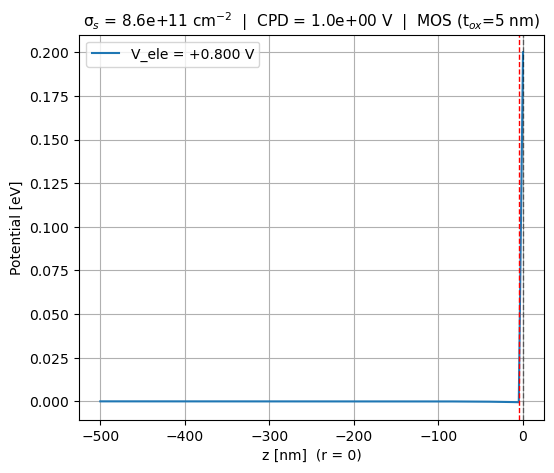

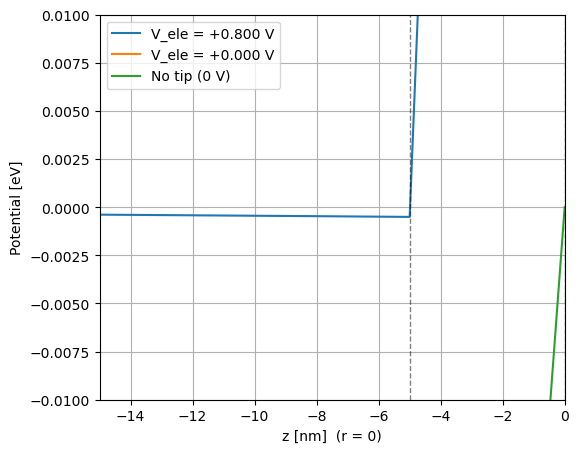

In [1]:
# -*- coding: utf-8 -*-
# Compute R(Vtip) at a fixed tip-sample distance using Feenstra/Boltzmann core.
# - CPD を実験値で補正: 計算は V_applied = V_tip - CPD を使用（出力・表示は元の V_tip 表記）
# - (変更) R vs Vtip のCSV出力は削除（保存しない）
# - (変更) 図で出している z 方向プロファイル（r=0）をCSVで保存する
# - Draw(u) の単位切り替え: V / eV（同値）/ kT(無次元)
# - r=0 のラインプロファイルを V_tip=Vtip_A, Vtip_B, チップ無し のケースで計算（CSVには全て保存）
from __future__ import annotations

import argparse, os, json, csv, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
import ngsolve as ng
from ngsolve.solvers import Newton
from netgen.geom2d import SplineGeometry
from scipy.optimize import brentq
from ngsolve.webgui import Draw
from dataclasses import asdict, dataclass


# ---------------- Core FEM (Feenstra/Boltzmann) ----------------

@dataclass
class PhysicalParameters:
    T: float = 300.0; Nd: float = 1e22; Na: float = 0.0; sigma_s: float = 1e16
    m_de: float = 0.42 * const.m_e; m_dh: float = 1.0 * const.m_e
    Eg: float = 3.26; Ed_offset_hex: float = 0.124; Ed_offset_cub: float = 0.066
    Ed_ratio_c_to_h: float = 1.88; Ea_offset: float = 0.2; ni: float = 8.2e15
    eps_sic: float = 9.7; eps_sio2: float = 3.9; eps_vac: float = 1.0
    n0: float = 0.0; p0: float = 0.0; Nc: float = 0.0; Nv: float = 0.0
    Ec: float = 0.0; Ev: float = 0.0; Edh: float = 0.0; Edc: float = 0.0
    Nd_h: float = 0.0; Nd_c: float = 0.0; kTeV: float = 0.0; Ef: float = 0.0
    def __post_init__(self):
        self.kTeV = const.k * self.T / const.e
        total_ratio = 1.0 + self.Ed_ratio_c_to_h
        self.Nd_h = self.Nd * 1.0 / total_ratio
        self.Nd_c = self.Nd * self.Ed_ratio_c_to_h / total_ratio
        self.n0 = (self.Nd + np.sqrt(self.Nd**2 + 4 * self.ni**2))/2
        self.p0 = self.ni**2 / self.n0
        self.Nc = 2*(2*np.pi*self.m_de*const.k*self.T/(const.h**2))**1.5
        self.Nv = 2*(2*np.pi*self.m_dh*const.k*self.T/(const.h**2))**1.5
        self.Ev = 0; self.Ec = self.Ev + self.Eg
        self.Edh = self.Ec - self.Ed_offset_hex; self.Edc = self.Ec - self.Ed_offset_cub

@dataclass
class GeometricParameters:
    L_c: float = 1e-9; l_sio2: float = 5.0; tip_radius: float = 45.0; tip_height: float = 8.0
    l_vac: float = 500.0; region_radius: float = 45.5; n_tip_arc_points: int = 7
    def __post_init__(self):
        assert self.n_tip_arc_points % 2 == 1

def fermi_dirac_integral(x):
    return np.piecewise(x, [x>25],
        [lambda x:(2/np.sqrt(np.pi))*((2/3)*x**1.5 + (np.pi**2/12)*x**-0.5),
         lambda x: np.exp(x)/(1+0.27*np.exp(x))])

def find_fermi_level(params: PhysicalParameters, out_dir: str, plot: bool=False):
    def neutrality(Ef):
        p = params.Nv * fermi_dirac_integral((params.Ev - Ef)/params.kTeV)
        n = params.Nc * fermi_dirac_integral((Ef - params.Ec)/params.kTeV)
        Ndp_h = params.Nd_h/(1 + 2*np.exp((Ef - params.Edh)/params.kTeV))
        Ndp_c = params.Nd_c/(1 + 2*np.exp((Ef - params.Edc)/params.kTeV))
        return np.log(p + Ndp_h + Ndp_c) - np.log(n)
    return brentq(neutrality, params.Ev + params.kTeV, params.Ec - params.kTeV)

def create_mesh(geom: GeometricParameters, include_tip: bool=True):
    # ★ 平行平板MOS: 真空・tip領域は作らない。材料は SiC(1), SiO2(2)
    L_c = geom.L_c
    R_dimless = geom.region_radius * 1e-9 / L_c
    sio2_depth_dimless = geom.l_sio2 * 1e-9 / L_c
    sub_depth_dimless  = geom.l_vac * 1e-9 / L_c   # ★ 旧vac厚を基板下方向の厚みとして再利用

    geo = SplineGeometry()
    # 端点
    p1 = geo.AppendPoint(0, -sub_depth_dimless)      # 基板最下
    p2 = geo.AppendPoint(0, -sio2_depth_dimless)     # SiC/SiO2 界面 (z=-t_ox)
    o  = geo.AppendPoint(0, 0)                       # SiO2 上面 (ゲート)
    q1 = geo.AppendPoint(R_dimless, -sub_depth_dimless)
    q2 = geo.AppendPoint(R_dimless, -sio2_depth_dimless)
    q3 = geo.AppendPoint(R_dimless, 0)

    # 軸・境界
    geo.Append(["line", p1, p2], bc="axis", leftdomain=0, rightdomain=1, maxh=5)
    geo.Append(["line", p2, q2], bc="sic/sio2", leftdomain=2, rightdomain=1, maxh=1)
    geo.Append(["line", q2, q1], bc="far-field", leftdomain=0, rightdomain=1)   # SiC側 右端
    geo.Append(["line", q1, p1], bc="ground", leftdomain=0, rightdomain=1)      # 下端 Dirichlet=0V
    geo.Append(["line", o, p2],  bc="axis", leftdomain=2, rightdomain=0, maxh=0.5)
    geo.Append(["line", q2, q3], bc="far-field", leftdomain=2, rightdomain=0)   # SiO2側 右端
    geo.Append(["line", q3, o],  bc="gate", leftdomain=2, rightdomain=0)        # ★ ゲート（Dirichlet=V_tip）

    geo.SetMaterial(1,"sic"); geo.SetMaterial(2,"sio2")
    return ng.Mesh(geo.GenerateMesh(maxh=5, grading=0.2))

def _setup_weak_form(fes, epsilon_r, phys, V_c, L_c, hom_q, hom_s, geom, msh, Feenstra, assume_full_ionization):
    uh, vh = fes.TnT(); r = ng.x
    C0 = (const.e * L_c**2) / (const.epsilon_0 * V_c)
    Ef, Ec, Ev = phys.Ef/V_c, phys.Ec/V_c, phys.Ev/V_c
    Edh, Edc = phys.Edh/V_c, phys.Edc/V_c
    lam_ff = 1/(geom.region_radius*1e-9/L_c)
    sig_t = (phys.sigma_s * const.e * L_c) / (const.epsilon_0 * V_c)
    def clamp(v,b): return ng.IfPos(v-b, b, ng.IfPos(-b-v, -b, v))
    def sexp(x): return ng.exp(clamp(x,40.0))
    def F12(x):
        x=clamp(x,40.0)
        return ng.IfPos(x-25.0, (2/np.sqrt(np.pi))*((2/3)*x**1.5+(np.pi**2/12)*x**(-.5)),
                        sexp(x)/(1+0.27*sexp(x)))
    u = clamp(uh,120.0)
    if Feenstra:
        n = C0 * phys.Nc * F12((Ef - Ec) + u)
        p = C0 * phys.Nv * F12((Ev - Ef) - u)
        if assume_full_ionization: Ndp = C0 * phys.Nd
        else:
            Ndp = C0*phys.Nd_h/(1+2*sexp((Ef-Edh)+u)) + C0*phys.Nd_c/(1+2*sexp((Ef-Edc)+u))
    else:
        n = C0 * phys.n0 * sexp(u)
        p = C0 * phys.p0 * sexp(-u)
        Ndp = C0 * phys.Nd
    rho = hom_q * (p + Ndp - n)
    sigma = hom_s * sig_t
    a = ng.BilinearForm(fes, symmetric=False)
    a += epsilon_r * ng.grad(uh)*ng.grad(vh) * r * ng.dx
    a += epsilon_r * lam_ff * uh * vh * r * ng.ds("far-field")
    a += -rho * vh * r * ng.dx(definedon=msh.Materials("sic"))
    a += -sigma * vh * r * ng.ds("sic/sio2"); return a

def _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh):
    # ★ gate に対して線形ウォームスタート
    w=fes.TrialFunction(); v=fes.TestFunction(); r=ng.x
    lam_ff=1/geom.region_radius; aL=ng.BilinearForm(fes); aL+=epsilon_r*ng.grad(w)*ng.grad(v)*r*ng.dx
    aL+=epsilon_r*lam_ff*w*v*r*ng.ds("far-field"); fL=ng.LinearForm(fes)
    u.vec[:]=0.0; uh=ng.GridFunction(fes)
    for vv in np.linspace(0.0, V_tip, 5)[1:]:
        uh=ng.GridFunction(fes); uh.Set(0, definedon=msh.Boundaries("ground")); uh.Set(vv/V_c, definedon=msh.Boundaries("gate"))  # ★
        aL.Assemble(); fL.Assemble(); rv=fL.vec.CreateVector(); rv.data=fL.vec - aL.mat*uh.vec
        free=fes.FreeDofs(); free &= ~fes.GetDofs(msh.Boundaries("ground")); free &= ~fes.GetDofs(msh.Boundaries("gate"))  # ★
        uh.vec.data += aL.mat.Inverse(free, inverse="sparsecholesky")*rv; u.vec.data = uh.vec

def solve_with_homotopy(a, u, fes, msh, hq, hs):
    def stage(p):
        t, step = 0.0, 0.1; backup=ng.GridFunction(fes); backup.vec.data=u.vec
        free=fes.FreeDofs()
        # ★ Dirichlet除外境界: ground と gate
        free &= ~fes.GetDofs(msh.Boundaries("ground"));
        free &= ~fes.GetDofs(msh.Boundaries("gate"))
        kw=dict(freedofs=free,maxit=100,maxerr=1e-11,inverse="sparsecholesky",dampfactor=0.7,printing=False)
        while t < 1-1e-12:
            trial=min(1.0, t+step); p.Set(trial); a.Assemble()
            try:
                conv, it = Newton(a, u, **kw)
                if conv < 0: raise RuntimeError
                t=trial; backup.vec.data=u.vec;
                if step<0.5: step*=1.5
            except:
                u.vec.data=backup.vec; step*=0.5
                if step<1e-4: raise
    hs.Set(0.0); stage(hq); hq.Set(1.0); stage(hs)

def save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    msh.ngmesh.Save(os.path.join(out_dir,"mesh.vol"))
    u_np=u.vec.FV().NumPy(); np.save(os.path.join(out_dir,"u_dimless.npy"), u_np)
    np.save(os.path.join(out_dir,"u_volts.npy"), u_np*V_c)
    meta={"V_c":V_c,"Feenstra":Feenstra,"ndof":u.space.ndof,"fes":"H1","order":u.space.globalorder,
          "materials":list(msh.GetMaterials()),"boundaries":list(msh.GetBoundaries())}
    with open(os.path.join(out_dir,"metadata.json"),"w") as f: json.dump(meta,f,indent=2)
    ng.VTKOutput(ma=msh, coefs=[u, u*V_c], names=["potential_dimless","potential_V"],
                 filename=os.path.join(out_dir,"solution"), subdivision=0).Do()

def load_results(out_dir:str, geom, V_c: float, include_tip: bool=True):
    msh=create_mesh(geom, include_tip=include_tip)
    fes=ng.H1(msh, order=1); u=ng.GridFunction(fes, name="potential_dimless")
    with open(os.path.join(out_dir,"metadata.json")) as f: meta=json.load(f)
    if meta["ndof"]!=fes.ndof: raise RuntimeError("DOF mismatch")
    vec=np.load(os.path.join(out_dir,"u_dimless.npy")); u.vec.FV().NumPy()[:]=vec
    return msh, u, vec*V_c

def run_fem_simulation(phys, geom, V_tip, Feenstra, out_dir, assume_full_ionization, include_tip: bool=True):
    msh=create_mesh(geom, include_tip=include_tip); V_c=const.k*phys.T/const.e
    fes=ng.H1(msh, order=1); u=ng.GridFunction(fes, name="potential_dimless")
    # ★ 材料は SiC, SiO2 のみ
    epsilon_r=ng.CoefficientFunction([phys.eps_sic, phys.eps_sio2])  # ★
    hq=ng.Parameter(0.0); hs=ng.Parameter(0.0)
    a=_setup_weak_form(fes, epsilon_r, phys, V_c, geom.L_c, hq, hs, geom, msh, Feenstra, assume_full_ionization)
    u.Set(0, definedon=msh.Boundaries("ground"))              # 下端 0V
    u.Set(V_tip/V_c, definedon=msh.Boundaries("gate"))        # ★ SiO2上端 = V_tip
    _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh)
    solve_with_homotopy(a, u, fes, msh, hq, hs)
    save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir)
    return V_c


# ---------------- Utility (post) ----------------

def sample_profile_on_z(msh, u, V_c, z_nm: float, r_max_nm: float, npts:int=1201):
    rs = np.linspace(0.0, r_max_nm, npts)
    prof = np.full_like(rs, np.nan, dtype=float)
    for i, r in enumerate(rs):
        try: prof[i] = float(u(msh(r, z_nm))) * V_c
        except: pass
    return rs, prof

def sample_axis_profile(msh, u, V_c, zmin_nm: float, zmax_nm: float, npts:int=1601):
    zs = np.linspace(zmin_nm, zmax_nm, npts)
    prof = np.full_like(zs, np.nan, dtype=float)
    for i, z in enumerate(zs):
        try: prof[i] = float(u(msh(0.0, z))) * V_c
        except: pass
    return zs, prof

def ring_radius_from_profile(rs, prof, level):
    rs=np.asarray(rs,float); prof=np.asarray(prof,float); lev=float(level)
    dif=prof-lev; m_pair=np.isfinite(dif[:-1]) & np.isfinite(dif[1:])
    chg=((dif[:-1]<=0)&(dif[1:]>=0))|((dif[:-1]>=0)&(dif[1:]<=0))
    idx=np.where(m_pair & chg)[0]
    if idx.size==0: return np.nan
    roots=[]
    for i in idx:
        r0,r1=rs[i],rs[i+1]; y0,y1=prof[i],prof[i+1]
        if not np.isfinite(y0+y1) or (y1==y0): continue
        r=r0+(lev-y0)*(r1-r0)/(y1-y0)
        if r>=-1e-12: roots.append(max(0.0,float(r)))
    return float(min(roots)) if roots else np.nan

def _align_to(z_ref: np.ndarray, z: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Interpolate y(z) onto z_ref if grids differ. Keeps NaNs if insufficient finite points."""
    z_ref = np.asarray(z_ref, float)
    z = np.asarray(z, float)
    y = np.asarray(y, float)

    if z.shape == z_ref.shape and np.allclose(z, z_ref, rtol=0, atol=1e-12):
        return y

    m = np.isfinite(z) & np.isfinite(y)
    if np.count_nonzero(m) < 2:
        return np.full_like(z_ref, np.nan, dtype=float)

    # np.interp needs ascending x
    zz = z[m]
    yy = y[m]
    order = np.argsort(zz)
    zz = zz[order]
    yy = yy[order]

    y_ref = np.interp(z_ref, zz, yy, left=np.nan, right=np.nan)
    return y_ref

def save_z_profile_csv(
    path_csv: Path,
    z_nm: np.ndarray,
    profiles_V: Dict[str, Tuple[np.ndarray, np.ndarray]],
    meta: Dict[str, object],
    z_window: Optional[Tuple[float, float]] = None,
) -> None:
    """
    Save r=0 z-profile (the same data used in plots) to CSV.
      - z_nm: reference z grid
      - profiles_V: dict label -> (z_grid, phi_V(z))
      - meta: metadata saved to a sidecar JSON as well
      - z_window: optional (zmin, zmax) to trim rows
    """
    z_ref = np.asarray(z_nm, float)

    df = pd.DataFrame({"z_nm": z_ref})
    for label, (z_i, phiV_i) in profiles_V.items():
        phiV_on_ref = _align_to(z_ref, z_i, phiV_i)
        # plotted value is -phi (treating V == eV for energy shift in your plots)
        df[f"{label}_phi_V"] = phiV_on_ref
        df[f"{label}_E_eV_plot"] = -phiV_on_ref

    if z_window is not None:
        zmin, zmax = float(z_window[0]), float(z_window[1])
        m = (df["z_nm"] >= zmin) & (df["z_nm"] <= zmax)
        df = df.loc[m].reset_index(drop=True)

    df.to_csv(path_csv, index=False, encoding="utf-8")

    # metadata sidecar
    meta_path = path_csv.with_suffix(".json")
    try:
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2, ensure_ascii=False)
    except Exception as e:
        print("[WARN] could not save metadata json:", e)


# ---------------- Main: R(Vtip) + line profiles ----------------

def main(argv=None):
    # allow_abbrev=False で ipykernel の -f などが紛れ込んでも壊れにくくする
    ap = argparse.ArgumentParser(allow_abbrev=False)
    ap.add_argument("--Vtip_list", type=float, nargs=3, default=[2.0, -2.0, 9], help="start stop num")
    ap.add_argument("--levels", type=float, nargs=3, default=[0.12, 0.20, 5], help="start stop num_levels")
    ap.add_argument("--sample_z_nm", type=float, default=-5.0)
    ap.add_argument("--tip_radius", type=float, default=45.0)
    ap.add_argument("--tip_height", type=float, default=8.0)
    ap.add_argument("--Nd_cm3", type=float, default=1e16)
    ap.add_argument("--sigma_s", type=float, default=1e12)
    ap.add_argument("--T", type=float, default=300.0)
    ap.add_argument("--l_sio2", type=float, default=5.0)
    ap.add_argument("--model", type=str, choices=["Feenstra","Boltzmann","F","B"], default="Feenstra")
    ap.add_argument("--assume_full_ionization", action="store_true")
    ap.add_argument("--CPD", type=float, default=0.0, help="Contact Potential Difference [V]")
    ap.add_argument("--outdir", type=str, default="R_vs_V_out")
    ap.add_argument("--show", action="store_true", help="Show Draw(u) after the last Vtip solve")
    ap.add_argument("--draw_unit", type=str, choices=["V", "eV", "kT"], default="V",
                    help="Draw(u) display unit: V / eV / kT (dimensionless)")

    # line-profile cases (optional knobs)
    ap.add_argument("--line_Vtip_A", type=float, default=0.8, help="Line profile case-A: V_tip [V] (display value)")
    ap.add_argument("--line_Vtip_B", type=float, default=0.0, help="Line profile case-B: V_tip [V] (display value)")
    ap.add_argument("--line_zmin_nm", type=float, default=None, help="Override zmin for line profile (nm). default=-l_vac")
    ap.add_argument("--line_zmax_nm", type=float, default=0.0, help="Override zmax for line profile (nm). default=0")
    ap.add_argument("--line_npts", type=int, default=5001, help="Number of points for z profile")

    # zoom window CSV
    ap.add_argument("--zoom_zmin_nm", type=float, default=-15.0, help="Zoom CSV: zmin (nm)")
    ap.add_argument("--zoom_zmax_nm", type=float, default=0.0, help="Zoom CSV: zmax (nm)")

    args, _ = ap.parse_known_args(argv)

    os.makedirs(args.outdir, exist_ok=True)
    Vtips = np.linspace(args.Vtip_list[0], args.Vtip_list[1], int(args.Vtip_list[2]))
    LEVELS = np.linspace(args.levels[0], args.levels[1], int(args.levels[2]))

    phys = PhysicalParameters(T=args.T, Nd=args.Nd_cm3*1e6, sigma_s=args.sigma_s*1e4)
    phys.Ef = find_fermi_level(phys, args.outdir, plot=False)
    geom = GeometricParameters(l_sio2=args.l_sio2, tip_radius=args.tip_radius, tip_height=args.tip_height)
    Feenstra = (args.model[0].upper()=="F")

    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

    # ---------------- R(Vtip) (MOS: gate@SiO2 top) ----------------
    # (CSV出力はしないが、計算自体は残す)
    R_dict = {lev: [] for lev in LEVELS}
    for Vtip in Vtips:
        V_applied = float(Vtip - args.CPD)  # ★ CPD補正（計算用）
        subdir = os.path.join(args.outdir, f"V_{Vtip:+.3f}V")  # 表示・保存は元の Vtip
        V_c = run_fem_simulation(phys, geom, V_tip=V_applied,
                                 Feenstra=Feenstra, out_dir=subdir,
                                 assume_full_ionization=args.assume_full_ionization,
                                 include_tip=True)
        msh, u, _ = load_results(subdir, geom, V_c, include_tip=True)

        if args.show and Vtip == Vtips[-1]:
            try:
                if args.draw_unit.lower() in ("v", "ev"):
                    label = "potential_V" if args.draw_unit.lower() == "v" else "potential_eV"
                    Draw(u * V_c, u.space.mesh, label)
                else:
                    Draw(u, u.space.mesh, "potential_kT")
            except Exception as e:
                print("[WARN] Draw(u) failed:", e)

        rs, prof = sample_profile_on_z(msh, u, V_c, z_nm=args.sample_z_nm,
                                       r_max_nm=geom.region_radius, npts=1401)
        for lev in LEVELS:
            R_dict[lev].append(ring_radius_from_profile(rs, prof, lev))

    print("[INFO] R(Vtip) computed. (CSV output for R vs Vtip is disabled as requested.)")

    # ---------------- r=0ラインプロファイル（図で出しているz方向プロファイル） ----------------
    zmin = float(args.line_zmin_nm) if args.line_zmin_nm is not None else -float(geom.l_vac)
    zmax = float(args.line_zmax_nm)
    npts = int(args.line_npts)

    # Case A
    Vtip_A = float(args.line_Vtip_A)
    V_applied_A = Vtip_A - args.CPD
    subdir_A = os.path.join(args.outdir, f"LINE_V_{Vtip_A:+.3f}V")
    Vc_A = run_fem_simulation(phys, geom, V_tip=V_applied_A, Feenstra=Feenstra,
                              out_dir=subdir_A, assume_full_ionization=args.assume_full_ionization,
                              include_tip=True)
    msh_A, u_A, _ = load_results(subdir_A, geom, Vc_A, include_tip=True)
    zs_A, prof_A = sample_axis_profile(msh_A, u_A, Vc_A, zmin_nm=zmin, zmax_nm=zmax, npts=npts)

    # Case B
    Vtip_B = float(args.line_Vtip_B)
    V_applied_B = Vtip_B - args.CPD
    subdir_B = os.path.join(args.outdir, f"LINE_V_{Vtip_B:+.3f}V")
    Vc_B = run_fem_simulation(phys, geom, V_tip=V_applied_B, Feenstra=Feenstra,
                              out_dir=subdir_B, assume_full_ionization=args.assume_full_ionization,
                              include_tip=True)
    msh_B, u_B, _ = load_results(subdir_B, geom, Vc_B, include_tip=True)
    zs_B, prof_B = sample_axis_profile(msh_B, u_B, Vc_B, zmin_nm=zmin, zmax_nm=zmax, npts=npts)

    # Case C (no tip) - kept for compatibility
    subdir_C = os.path.join(args.outdir, "LINE_NO_TIP")
    Vc_C = run_fem_simulation(phys, geom, V_tip=0.0, Feenstra=Feenstra,
                              out_dir=subdir_C, assume_full_ionization=args.assume_full_ionization,
                              include_tip=False)
    msh_C, u_C, _ = load_results(subdir_C, geom, Vc_C, include_tip=False)
    zs_C, prof_C = sample_axis_profile(msh_C, u_C, Vc_C, zmin_nm=zmin, zmax_nm=zmax, npts=npts)

    # --- CSV保存（図で使っているz方向プロファイル） ---
    meta = {
        "stamp": stamp,
        "model": ("Feenstra" if Feenstra else "Boltzmann"),
        "sigma_s_cm2": float(args.sigma_s),
        "CPD_V": float(args.CPD),
        "t_ox_nm": float(geom.l_sio2),
        "Nd_cm3": float(args.Nd_cm3),
        "T_K": float(args.T),
        "zmin_nm": float(zmin),
        "zmax_nm": float(zmax),
        "npts": int(npts),
        "caseA_Vtip_display_V": float(Vtip_A),
        # "caseB_Vtip_display_V": float(Vtip_B),
        # "caseC": "no_tip (V_tip=0 applied)",
        "note_y_plot": "E_eV_plot = -phi_V (same as your plot)",
    }

    profiles = {
        f"caseA_Vele_{Vtip_A:+.3f}V": (zs_A, prof_A),
        f"caseB_Vele_{Vtip_B:+.3f}V": (zs_B, prof_B),
        "caseC_no_tip": (zs_C, prof_C),
    }

    csv_full = Path(args.outdir) / f"{stamp}_line_profile_r0.csv"
    save_z_profile_csv(csv_full, zs_A, profiles, meta, z_window=None)
    print("[INFO] saved:", csv_full)

    csv_zoom = Path(args.outdir) / f"{stamp}_line_profile_r0_zoom.csv"
    save_z_profile_csv(
        csv_zoom, zs_A, profiles, meta,
        z_window=(float(args.zoom_zmin_nm), float(args.zoom_zmax_nm))
    )
    print("[INFO] saved:", csv_zoom)

    # ---------------- 図示（既存の図出力は維持） ----------------
    fig2, ax2 = plt.subplots(figsize=(6,5))
    title_str = rf"σ$_{{s}}$ = {args.sigma_s:.1e} cm$^{{-2}}$  |  CPD = {args.CPD:.1e} V  |  MOS (t$_{{ox}}$={geom.l_sio2:.0f} nm)"
    ax2.set_title(title_str, fontsize=11)
    ax2.plot(zs_A, -prof_A, label=f"V_ele = {Vtip_A:+.3f} V")
    # 既存の見た目を変えたくない場合は以下2行をコメントアウトしてください
    # ax2.plot(zs_B, -prof_B, label=f"V_ele = {Vtip_B:+.3f} V")
    # ax2.plot(zs_C, -prof_C, label="No tip (0 V)")

    ax2.axvline(-geom.l_sio2, color='r', ls='--', lw=1, alpha=1)    # SiO2/SiC
    ax2.axvline(0.0,         color='k', ls='--', lw=1, alpha=0.5)   # 表面 (gate)
    ax2.set_xlabel("z [nm]  (r = 0)")
    ax2.set_ylabel("Potential [eV]")
    ax2.grid(True); ax2.legend()
    fig2.savefig(Path(args.outdir) / f"{stamp}_line_profile_r0.png", dpi=200, bbox_inches="tight")
    print("[INFO] saved:", Path(args.outdir) / f"{stamp}_line_profile_r0.png")

    fig3, ax3 = plt.subplots(figsize=(6,5))
    ax3.plot(zs_A, -prof_A, label=f"V_ele = {Vtip_A:+.3f} V")
    ax3.plot(zs_B, -prof_B, label=f"V_ele = {Vtip_B:+.3f} V")
    ax3.plot(zs_C, -prof_C, label="No tip (0 V)")
    ax3.axvline(-geom.l_sio2, color='k', ls='--', lw=1, alpha=0.5)
    ax3.axvline(0.0,         color='k', ls='--', lw=1, alpha=0.5)
    ax3.set_xlabel("z [nm]  (r = 0)")
    ax3.set_ylabel("Potential [eV]")
    ax3.grid(True); ax3.legend()
    ax3.set_xlim(float(args.zoom_zmin_nm), float(args.zoom_zmax_nm))
    ax3.set_ylim(-0.01, 0.01)
    fig3.savefig(Path(args.outdir) / f"{stamp}_line_profile_r0_2.png", dpi=200, bbox_inches="tight")
    print("[INFO] saved:", Path(args.outdir) / f"{stamp}_line_profile_r0_2.png")


if __name__=="__main__":
    # --- Jupyter でも動く既定値（必要に応じて編集してください） ---
    main([
        "--show",
        "--Vtip_list", "-0.232", "-0.232", "1",
        "--levels", "-0.16", "-0.24", "1",
        "--sample_z_nm", "-5",
        "--tip_radius", "45",
        "--tip_height", "8",
        "--Nd_cm3", "1e16",
        "--sigma_s", "8.65e+11",
        "--T", "300",
        "--model", "Feenstra",
        "--CPD", "1.0",
        "--line_Vtip_A", "0.8",
        "--line_Vtip_B", "0.0",
        "--zoom_zmin_nm", "-15",
        "--zoom_zmax_nm", "0",
    ])


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

[INFO] R(Vtip) computed. (CSV output for R vs Vtip is disabled as requested.)
[INFO] saved: R_vs_V_out\20260213_1335_line_profile_r0.csv
[INFO] saved: R_vs_V_out\20260213_1335_line_profile_r0_zoom.csv
[INFO] saved: R_vs_V_out\20260213_1335_line_profile_r0.png
[INFO] saved: R_vs_V_out\20260213_1335_line_profile_r0_2.png


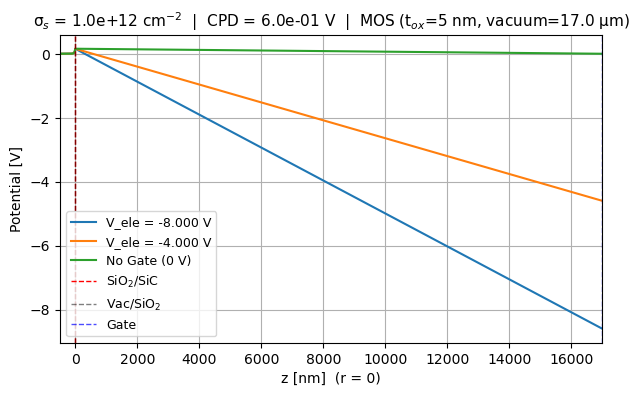

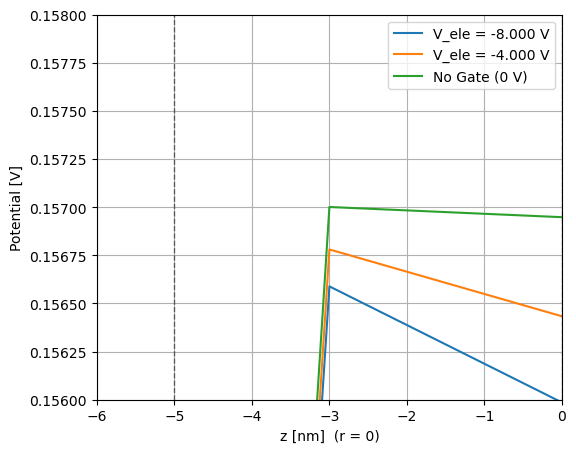

In [22]:
# -*- coding: utf-8 -*-
# Compute R(Vtip) at a fixed tip-sample distance using Feenstra/Boltzmann core.
# - CPD を実験値で補正: 計算は V_applied = V_tip - CPD を使用（出力・表示は元の V_tip 表記）
# - (変更) R vs Vtip のCSV出力は削除（保存しない）
# - (変更) 図で出している z 方向プロファイル（r=0）をCSVで保存する
# - Draw(u) の単位切り替え: V / eV（同値）/ kT(無次元)
# - r=0 のラインプロファイルを V_tip=Vtip_A, Vtip_B, チップ無し のケースで計算（CSVには全て保存）
# - (NEW) 金属板(gate)とSiO2の間に真空層（厚さ 17 μm）を追加
# - (NEW) ポテンシャルの反転処理をやめる（plot/CSVともに符号反転なし）
# - (NEW) fig2 に真空層＋ゲート境界まで含めて表示
from __future__ import annotations

import argparse, os, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
import ngsolve as ng
from ngsolve.solvers import Newton
from netgen.geom2d import SplineGeometry
from scipy.optimize import brentq
from ngsolve.webgui import Draw
from dataclasses import dataclass
from typing import Dict, Tuple, Optional


# ---------------- Core FEM (Feenstra/Boltzmann) ----------------

@dataclass
class PhysicalParameters:
    T: float = 300.0; Nd: float = 1e22; Na: float = 0.0; sigma_s: float = 1e16
    m_de: float = 0.42 * const.m_e; m_dh: float = 1.0 * const.m_e
    Eg: float = 3.26; Ed_offset_hex: float = 0.124; Ed_offset_cub: float = 0.066
    Ed_ratio_c_to_h: float = 1.88; Ea_offset: float = 0.2; ni: float = 8.2e15
    eps_sic: float = 9.7; eps_sio2: float = 3.9; eps_vac: float = 1.0
    n0: float = 0.0; p0: float = 0.0; Nc: float = 0.0; Nv: float = 0.0
    Ec: float = 0.0; Ev: float = 0.0; Edh: float = 0.0; Edc: float = 0.0
    Nd_h: float = 0.0; Nd_c: float = 0.0; kTeV: float = 0.0; Ef: float = 0.0
    def __post_init__(self):
        self.kTeV = const.k * self.T / const.e
        total_ratio = 1.0 + self.Ed_ratio_c_to_h
        self.Nd_h = self.Nd * 1.0 / total_ratio
        self.Nd_c = self.Nd * self.Ed_ratio_c_to_h / total_ratio
        self.n0 = (self.Nd + np.sqrt(self.Nd**2 + 4 * self.ni**2))/2
        self.p0 = self.ni**2 / self.n0
        self.Nc = 2*(2*np.pi*self.m_de*const.k*self.T/(const.h**2))**1.5
        self.Nv = 2*(2*np.pi*self.m_dh*const.k*self.T/(const.h**2))**1.5
        self.Ev = 0; self.Ec = self.Ev + self.Eg
        self.Edh = self.Ec - self.Ed_offset_hex; self.Edc = self.Ec - self.Ed_offset_cub

@dataclass
class GeometricParameters:
    L_c: float = 1e-9
    l_sio2: float = 5.0              # [nm]
    tip_radius: float = 45.0
    tip_height: float = 8.0
    l_vac: float = 500.0             # [nm]  ★従来どおり「基板(SiC)厚」として使用
    l_vac_gate: float = 17000.0      # [nm]  ★SiO2上の真空層厚 (17 μm = 17000 nm)
    region_radius: float = 45.5
    n_tip_arc_points: int = 7
    def __post_init__(self):
        assert self.n_tip_arc_points % 2 == 1

def fermi_dirac_integral(x):
    return np.piecewise(x, [x>25],
        [lambda x:(2/np.sqrt(np.pi))*((2/3)*x**1.5 + (np.pi**2/12)*x**-0.5),
         lambda x: np.exp(x)/(1+0.27*np.exp(x))])

def find_fermi_level(params: PhysicalParameters, out_dir: str, plot: bool=False):
    def neutrality(Ef):
        p = params.Nv * fermi_dirac_integral((params.Ev - Ef)/params.kTeV)
        n = params.Nc * fermi_dirac_integral((Ef - params.Ec)/params.kTeV)
        Ndp_h = params.Nd_h/(1 + 2*np.exp((Ef - params.Edh)/params.kTeV))
        Ndp_c = params.Nd_c/(1 + 2*np.exp((Ef - params.Edc)/params.kTeV))
        return np.log(p + Ndp_h + Ndp_c) - np.log(n)
    return brentq(neutrality, params.Ev + params.kTeV, params.Ec - params.kTeV)

def create_mesh(geom: GeometricParameters, include_tip: bool=True):
    # ★ 平行平板MOS: tip領域は作らない。材料は SiC(1), SiO2(2), Vacuum(3)
    # ★ SiO2上に vacuum gap(=l_vac_gate) を追加し、その上端を gate(Dirichlet=V_tip) とする
    L_c = geom.L_c
    R_dimless = geom.region_radius * 1e-9 / L_c
    sio2_depth_dimless = geom.l_sio2 * 1e-9 / L_c
    sub_depth_dimless  = geom.l_vac * 1e-9 / L_c
    vac_gate_dimless   = geom.l_vac_gate * 1e-9 / L_c

    maxh_global = 200.0
    maxh_vac    = max(200.0, geom.l_vac_gate / 40.0)  # 真空は粗く
    geo = SplineGeometry()

    # axis側
    p1 = geo.AppendPoint(0, -sub_depth_dimless)
    p2 = geo.AppendPoint(0, -sio2_depth_dimless)
    o  = geo.AppendPoint(0, 0)
    t  = geo.AppendPoint(0, vac_gate_dimless)

    # 右端
    q1 = geo.AppendPoint(R_dimless, -sub_depth_dimless)
    q2 = geo.AppendPoint(R_dimless, -sio2_depth_dimless)
    q3 = geo.AppendPoint(R_dimless, 0)
    q4 = geo.AppendPoint(R_dimless, vac_gate_dimless)

    # Axis
    geo.Append(["line", p1, p2], bc="axis", leftdomain=0, rightdomain=1, maxh=5)
    geo.Append(["line", p2, o],  bc="axis", leftdomain=0, rightdomain=2, maxh=0.5)
    geo.Append(["line", o, t],   bc="axis", leftdomain=0, rightdomain=3, maxh=maxh_vac)

    # Interfaces
    geo.Append(["line", p2, q2], bc="sic/sio2", leftdomain=2, rightdomain=1, maxh=1)
    geo.Append(["line", o,  q3], bc="sio2/vac", leftdomain=3, rightdomain=2, maxh=2)

    # Far-field
    geo.Append(["line", q4, q3], bc="far-field", leftdomain=0, rightdomain=3, maxh=maxh_vac)
    geo.Append(["line", q3, q2], bc="far-field", leftdomain=0, rightdomain=2, maxh=10)
    geo.Append(["line", q2, q1], bc="far-field", leftdomain=0, rightdomain=1, maxh=20)

    # Bottom & Top
    geo.Append(["line", q1, p1], bc="ground", leftdomain=0, rightdomain=1, maxh=50)
    geo.Append(["line", t,  q4], bc="gate",   leftdomain=0, rightdomain=3, maxh=maxh_vac)

    geo.SetMaterial(1, "sic")
    geo.SetMaterial(2, "sio2")
    geo.SetMaterial(3, "vac")

    return ng.Mesh(geo.GenerateMesh(maxh=maxh_global, grading=0.2))

def _setup_weak_form(fes, epsilon_r, phys, V_c, L_c, hom_q, hom_s, geom, msh, Feenstra, assume_full_ionization):
    uh, vh = fes.TnT(); r = ng.x
    C0 = (const.e * L_c**2) / (const.epsilon_0 * V_c)
    Ef, Ec, Ev = phys.Ef/V_c, phys.Ec/V_c, phys.Ev/V_c
    Edh, Edc = phys.Edh/V_c, phys.Edc/V_c
    lam_ff = 1/(geom.region_radius*1e-9/L_c)
    sig_t = (phys.sigma_s * const.e * L_c) / (const.epsilon_0 * V_c)

    def clamp(v,b): return ng.IfPos(v-b, b, ng.IfPos(-b-v, -b, v))
    def sexp(x): return ng.exp(clamp(x,40.0))
    def F12(x):
        x=clamp(x,40.0)
        return ng.IfPos(x-25.0, (2/np.sqrt(np.pi))*((2/3)*x**1.5+(np.pi**2/12)*x**(-.5)),
                        sexp(x)/(1+0.27*sexp(x)))

    u = clamp(uh,120.0)

    if Feenstra:
        n = C0 * phys.Nc * F12((Ef - Ec) + u)
        p = C0 * phys.Nv * F12((Ev - Ef) - u)
        if assume_full_ionization:
            Ndp = C0 * phys.Nd
        else:
            Ndp = C0*phys.Nd_h/(1+2*sexp((Ef-Edh)+u)) + C0*phys.Nd_c/(1+2*sexp((Ef-Edc)+u))
    else:
        n = C0 * phys.n0 * sexp(u)
        p = C0 * phys.p0 * sexp(-u)
        Ndp = C0 * phys.Nd

    rho = hom_q * (p + Ndp - n)
    sigma = hom_s * sig_t

    a = ng.BilinearForm(fes, symmetric=False)
    a += epsilon_r * ng.grad(uh)*ng.grad(vh) * r * ng.dx
    a += epsilon_r * lam_ff * uh * vh * r * ng.ds("far-field")
    a += -rho * vh * r * ng.dx(definedon=msh.Materials("sic"))
    a += -sigma * vh * r * ng.ds("sic/sio2")
    return a

def _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh):
    w=fes.TrialFunction(); v=fes.TestFunction(); r=ng.x
    lam_ff=1/geom.region_radius
    aL=ng.BilinearForm(fes)
    aL+=epsilon_r*ng.grad(w)*ng.grad(v)*r*ng.dx
    aL+=epsilon_r*lam_ff*w*v*r*ng.ds("far-field")
    fL=ng.LinearForm(fes)

    u.vec[:]=0.0
    for vv in np.linspace(0.0, V_tip, 5)[1:]:
        uh=ng.GridFunction(fes)
        uh.Set(0, definedon=msh.Boundaries("ground"))
        uh.Set(vv/V_c, definedon=msh.Boundaries("gate"))
        aL.Assemble(); fL.Assemble()
        rv=fL.vec.CreateVector()
        rv.data=fL.vec - aL.mat*uh.vec

        free=fes.FreeDofs()
        free &= ~fes.GetDofs(msh.Boundaries("ground"))
        free &= ~fes.GetDofs(msh.Boundaries("gate"))

        uh.vec.data += aL.mat.Inverse(free, inverse="sparsecholesky")*rv
        u.vec.data = uh.vec

def solve_with_homotopy(a, u, fes, msh, hq, hs):
    def stage(p):
        t, step = 0.0, 0.1
        backup=ng.GridFunction(fes); backup.vec.data=u.vec
        free=fes.FreeDofs()
        free &= ~fes.GetDofs(msh.Boundaries("ground"))
        free &= ~fes.GetDofs(msh.Boundaries("gate"))
        kw=dict(freedofs=free,maxit=100,maxerr=1e-11,inverse="sparsecholesky",dampfactor=0.7,printing=False)
        while t < 1-1e-12:
            trial=min(1.0, t+step)
            p.Set(trial); a.Assemble()
            try:
                conv, it = Newton(a, u, **kw)
                if conv < 0: raise RuntimeError
                t=trial; backup.vec.data=u.vec
                if step<0.5: step*=1.5
            except:
                u.vec.data=backup.vec
                step*=0.5
                if step<1e-4: raise
    hs.Set(0.0); stage(hq)
    hq.Set(1.0); stage(hs)

def save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    msh.ngmesh.Save(os.path.join(out_dir,"mesh.vol"))
    u_np=u.vec.FV().NumPy()
    np.save(os.path.join(out_dir,"u_dimless.npy"), u_np)
    np.save(os.path.join(out_dir,"u_volts.npy"), u_np*V_c)
    meta={"V_c":V_c,"Feenstra":Feenstra,"ndof":u.space.ndof,"fes":"H1","order":u.space.globalorder,
          "materials":list(msh.GetMaterials()),"boundaries":list(msh.GetBoundaries())}
    with open(os.path.join(out_dir,"metadata.json"),"w") as f:
        json.dump(meta,f,indent=2)
    ng.VTKOutput(ma=msh, coefs=[u, u*V_c], names=["potential_dimless","potential_V"],
                 filename=os.path.join(out_dir,"solution"), subdivision=0).Do()

def load_results(out_dir:str, geom, V_c: float, include_tip: bool=True):
    msh=create_mesh(geom, include_tip=include_tip)
    fes=ng.H1(msh, order=1)
    u=ng.GridFunction(fes, name="potential_dimless")
    with open(os.path.join(out_dir,"metadata.json")) as f:
        meta=json.load(f)
    if meta["ndof"]!=fes.ndof:
        raise RuntimeError("DOF mismatch")
    vec=np.load(os.path.join(out_dir,"u_dimless.npy"))
    u.vec.FV().NumPy()[:]=vec
    return msh, u, vec*V_c

def run_fem_simulation(phys, geom, V_tip, Feenstra, out_dir, assume_full_ionization, include_tip: bool=True):
    msh=create_mesh(geom, include_tip=include_tip)
    V_c=const.k*phys.T/const.e
    fes=ng.H1(msh, order=1)
    u=ng.GridFunction(fes, name="potential_dimless")

    epsilon_r=ng.CoefficientFunction([phys.eps_sic, phys.eps_sio2, phys.eps_vac])

    hq=ng.Parameter(0.0); hs=ng.Parameter(0.0)
    a=_setup_weak_form(fes, epsilon_r, phys, V_c, geom.L_c, hq, hs, geom, msh, Feenstra, assume_full_ionization)

    u.Set(0, definedon=msh.Boundaries("ground"))
    u.Set(V_tip/V_c, definedon=msh.Boundaries("gate"))

    _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh)
    solve_with_homotopy(a, u, fes, msh, hq, hs)
    save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir)
    return V_c


# ---------------- Utility (post) ----------------

def sample_profile_on_z(msh, u, V_c, z_nm: float, r_max_nm: float, npts:int=1201):
    rs = np.linspace(0.0, r_max_nm, npts)
    prof = np.full_like(rs, np.nan, dtype=float)
    for i, r in enumerate(rs):
        try:
            prof[i] = float(u(msh(r, z_nm))) * V_c
        except:
            pass
    return rs, prof

def sample_axis_profile(msh, u, V_c, zmin_nm: float, zmax_nm: float, npts:int=1601):
    zs = np.linspace(zmin_nm, zmax_nm, npts)
    prof = np.full_like(zs, np.nan, dtype=float)
    for i, z in enumerate(zs):
        try:
            prof[i] = float(u(msh(0.0, z))) * V_c
        except:
            pass
    return zs, prof

def ring_radius_from_profile(rs, prof, level):
    rs=np.asarray(rs,float); prof=np.asarray(prof,float); lev=float(level)
    dif=prof-lev; m_pair=np.isfinite(dif[:-1]) & np.isfinite(dif[1:])
    chg=((dif[:-1]<=0)&(dif[1:]>=0))|((dif[:-1]>=0)&(dif[1:]<=0))
    idx=np.where(m_pair & chg)[0]
    if idx.size==0: return np.nan
    roots=[]
    for i in idx:
        r0,r1=rs[i],rs[i+1]; y0,y1=prof[i],prof[i+1]
        if not np.isfinite(y0+y1) or (y1==y0): continue
        r=r0+(lev-y0)*(r1-r0)/(y1-y0)
        if r>=-1e-12: roots.append(max(0.0,float(r)))
    return float(min(roots)) if roots else np.nan

def _align_to(z_ref: np.ndarray, z: np.ndarray, y: np.ndarray) -> np.ndarray:
    z_ref = np.asarray(z_ref, float)
    z = np.asarray(z, float)
    y = np.asarray(y, float)

    if z.shape == z_ref.shape and np.allclose(z, z_ref, rtol=0, atol=1e-12):
        return y

    m = np.isfinite(z) & np.isfinite(y)
    if np.count_nonzero(m) < 2:
        return np.full_like(z_ref, np.nan, dtype=float)

    zz = z[m]
    yy = y[m]
    order = np.argsort(zz)
    zz = zz[order]
    yy = yy[order]

    y_ref = np.interp(z_ref, zz, yy, left=np.nan, right=np.nan)
    return y_ref

def save_z_profile_csv(
    path_csv: Path,
    z_nm: np.ndarray,
    profiles_V: Dict[str, Tuple[np.ndarray, np.ndarray]],
    meta: Dict[str, object],
    z_window: Optional[Tuple[float, float]] = None,
) -> None:
    """
    Save r=0 z-profile to CSV.
      - 反転処理なし（phi_V をそのまま保存）
      - 互換のため E_eV_plot 列名は残すが、中身は phi_V と同一（反転なし）
    """
    z_ref = np.asarray(z_nm, float)

    df = pd.DataFrame({"z_nm": z_ref})
    for label, (z_i, phiV_i) in profiles_V.items():
        phiV_on_ref = _align_to(z_ref, z_i, phiV_i)
        df[f"{label}_phi_V"] = phiV_on_ref
        df[f"{label}_E_eV_plot"] = phiV_on_ref   # ★反転なし（V と eV を同値扱い）

    if z_window is not None:
        zmin, zmax = float(z_window[0]), float(z_window[1])
        m = (df["z_nm"] >= zmin) & (df["z_nm"] <= zmax)
        df = df.loc[m].reset_index(drop=True)

    df.to_csv(path_csv, index=False, encoding="utf-8")

    meta_path = path_csv.with_suffix(".json")
    try:
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2, ensure_ascii=False)
    except Exception as e:
        print("[WARN] could not save metadata json:", e)


# ---------------- Main: R(Vtip) + line profiles ----------------

def main(argv=None):
    ap = argparse.ArgumentParser(allow_abbrev=False)
    ap.add_argument("--Vtip_list", type=float, nargs=3, default=[2.0, -2.0, 9], help="start stop num")
    ap.add_argument("--levels", type=float, nargs=3, default=[0.12, 0.20, 5], help="start stop num_levels")
    ap.add_argument("--sample_z_nm", type=float, default=-5.0)
    ap.add_argument("--tip_radius", type=float, default=45.0)
    ap.add_argument("--tip_height", type=float, default=8.0)
    ap.add_argument("--Nd_cm3", type=float, default=1e16)
    ap.add_argument("--sigma_s", type=float, default=1e12)
    ap.add_argument("--T", type=float, default=300.0)
    ap.add_argument("--l_sio2", type=float, default=5.0)
    ap.add_argument("--l_vac_gate_um", type=float, default=17.0, help="Vacuum gap between SiO2 and metal gate [um]")
    ap.add_argument("--model", type=str, choices=["Feenstra","Boltzmann","F","B"], default="Feenstra")
    ap.add_argument("--assume_full_ionization", action="store_true")
    ap.add_argument("--CPD", type=float, default=0.0, help="Contact Potential Difference [V]")
    ap.add_argument("--outdir", type=str, default="R_vs_V_out")
    ap.add_argument("--show", action="store_true", help="Show Draw(u) after the last Vtip solve")
    ap.add_argument("--draw_unit", type=str, choices=["V", "eV", "kT"], default="V",
                    help="Draw(u) display unit: V / eV / kT (dimensionless)")

    ap.add_argument("--line_Vtip_A", type=float, default=0.8)
    ap.add_argument("--line_Vtip_B", type=float, default=0.0)
    ap.add_argument("--line_zmin_nm", type=float, default=None, help="Override zmin for line profile (nm). default=-l_vac")
    ap.add_argument("--line_zmax_nm", type=float, default=None,
                    help="Override zmax for line profile (nm). default=+l_vac_gate (gate)")
    ap.add_argument("--line_npts", type=int, default=5001)

    ap.add_argument("--zoom_zmin_nm", type=float, default=-6)
    ap.add_argument("--zoom_zmax_nm", type=float, default=0.0)

    args, _ = ap.parse_known_args(argv)

    os.makedirs(args.outdir, exist_ok=True)
    Vtips = np.linspace(args.Vtip_list[0], args.Vtip_list[1], int(args.Vtip_list[2]))
    LEVELS = np.linspace(args.levels[0], args.levels[1], int(args.levels[2]))

    phys = PhysicalParameters(T=args.T, Nd=args.Nd_cm3*1e6, sigma_s=args.sigma_s*1e4)
    phys.Ef = find_fermi_level(phys, args.outdir, plot=False)

    geom = GeometricParameters(
        l_sio2=args.l_sio2,
        tip_radius=args.tip_radius,
        tip_height=args.tip_height,
        l_vac_gate=float(args.l_vac_gate_um) * 1000.0,   # um -> nm
    )
    Feenstra = (args.model[0].upper()=="F")

    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

    # ---------------- R(Vtip) ----------------
    R_dict = {lev: [] for lev in LEVELS}
    for Vtip in Vtips:
        V_applied = float(Vtip - args.CPD)
        subdir = os.path.join(args.outdir, f"V_{Vtip:+.3f}V")
        V_c = run_fem_simulation(phys, geom, V_tip=V_applied,
                                 Feenstra=Feenstra, out_dir=subdir,
                                 assume_full_ionization=args.assume_full_ionization,
                                 include_tip=True)
        msh, u, _ = load_results(subdir, geom, V_c, include_tip=True)

        if args.show and Vtip == Vtips[-1]:
            try:
                if args.draw_unit.lower() in ("v", "ev"):
                    label = "potential_V" if args.draw_unit.lower() == "v" else "potential_eV"
                    Draw(u * V_c, u.space.mesh, label)
                else:
                    Draw(u, u.space.mesh, "potential_kT")
            except Exception as e:
                print("[WARN] Draw(u) failed:", e)

        rs, prof = sample_profile_on_z(msh, u, V_c, z_nm=args.sample_z_nm,
                                       r_max_nm=geom.region_radius, npts=1401)
        for lev in LEVELS:
            R_dict[lev].append(ring_radius_from_profile(rs, prof, lev))

    print("[INFO] R(Vtip) computed. (CSV output for R vs Vtip is disabled as requested.)")

    # ---------------- r=0ラインプロファイル ----------------
    zmin = float(args.line_zmin_nm) if args.line_zmin_nm is not None else -float(geom.l_vac)
    zmax = float(args.line_zmax_nm) if args.line_zmax_nm is not None else float(geom.l_vac_gate)  # ★gateまで
    npts = int(args.line_npts)

    # Case A
    Vtip_A = float(args.line_Vtip_A)
    V_applied_A = Vtip_A - args.CPD
    subdir_A = os.path.join(args.outdir, f"LINE_V_{Vtip_A:+.3f}V")
    Vc_A = run_fem_simulation(phys, geom, V_tip=V_applied_A, Feenstra=Feenstra,
                              out_dir=subdir_A, assume_full_ionization=args.assume_full_ionization,
                              include_tip=True)
    msh_A, u_A, _ = load_results(subdir_A, geom, Vc_A, include_tip=True)
    zs_A, prof_A = sample_axis_profile(msh_A, u_A, Vc_A, zmin_nm=zmin, zmax_nm=zmax, npts=npts)

    # Case B
    Vtip_B = float(args.line_Vtip_B)
    V_applied_B = Vtip_B - args.CPD
    subdir_B = os.path.join(args.outdir, f"LINE_V_{Vtip_B:+.3f}V")
    Vc_B = run_fem_simulation(phys, geom, V_tip=V_applied_B, Feenstra=Feenstra,
                              out_dir=subdir_B, assume_full_ionization=args.assume_full_ionization,
                              include_tip=True)
    msh_B, u_B, _ = load_results(subdir_B, geom, Vc_B, include_tip=True)
    zs_B, prof_B = sample_axis_profile(msh_B, u_B, Vc_B, zmin_nm=zmin, zmax_nm=zmax, npts=npts)

    # Case C (no tip) - kept for compatibility
    subdir_C = os.path.join(args.outdir, "LINE_NO_TIP")
    Vc_C = run_fem_simulation(phys, geom, V_tip=0.0, Feenstra=Feenstra,
                              out_dir=subdir_C, assume_full_ionization=args.assume_full_ionization,
                              include_tip=False)
    msh_C, u_C, _ = load_results(subdir_C, geom, Vc_C, include_tip=False)
    zs_C, prof_C = sample_axis_profile(msh_C, u_C, Vc_C, zmin_nm=zmin, zmax_nm=zmax, npts=npts)

    meta = {
        "stamp": stamp,
        "model": ("Feenstra" if Feenstra else "Boltzmann"),
        "sigma_s_cm2": float(args.sigma_s),
        "CPD_V": float(args.CPD),
        "t_ox_nm": float(geom.l_sio2),
        "t_vac_gate_um": float(args.l_vac_gate_um),
        "Nd_cm3": float(args.Nd_cm3),
        "T_K": float(args.T),
        "zmin_nm": float(zmin),
        "zmax_nm": float(zmax),
        "npts": int(npts),
        "caseA_Vtip_display_V": float(Vtip_A),
        "note": "No sign inversion: plot & CSV store phi(z) as-is.",
    }

    profiles = {
        f"caseA_Vele_{Vtip_A:+.3f}V": (zs_A, prof_A),
        f"caseB_Vele_{Vtip_B:+.3f}V": (zs_B, prof_B),
        "caseC_no_tip": (zs_C, prof_C),
    }

    csv_full = Path(args.outdir) / f"{stamp}_line_profile_r0.csv"
    save_z_profile_csv(csv_full, zs_A, profiles, meta, z_window=None)
    print("[INFO] saved:", csv_full)

    csv_zoom = Path(args.outdir) / f"{stamp}_line_profile_r0_zoom.csv"
    save_z_profile_csv(
        csv_zoom, zs_A, profiles, meta,
        z_window=(float(args.zoom_zmin_nm), float(args.zoom_zmax_nm))
    )
    print("[INFO] saved:", csv_zoom)

    # ---------------- 図示 ----------------
    # fig2: 真空層＋ゲート境界まで含める（SiC/SiO2/vac/gate 全部見える）
    fig2, ax2 = plt.subplots(figsize=(7,4))
    title_str = (
        rf"σ$_{{s}}$ = {args.sigma_s:.1e} cm$^{{-2}}$  |  CPD = {args.CPD:.1e} V  |  "
        rf"MOS (t$_{{ox}}$={geom.l_sio2:.0f} nm, vacuum={args.l_vac_gate_um:.1f} μm)"
    )
    ax2.set_title(title_str, fontsize=11)

    # ★反転なし
    ax2.plot(zs_A, prof_A, label=f"V_ele = {Vtip_A:+.3f} V")
    ax2.plot(zs_B, prof_B, label=f"V_ele = {Vtip_B:+.3f} V")
    ax2.plot(zs_C, prof_C, label="No Gate (0 V)")
    # boundaries
    ax2.axvline(-geom.l_sio2,      color='r', ls='--', lw=1, alpha=1.0, label="SiO$_2$/SiC")
    ax2.axvline(0.0,              color='k', ls='--', lw=1, alpha=0.5, label="Vac/SiO$_2$")
    ax2.axvline(+geom.l_vac_gate, color='b', ls='--', lw=1, alpha=0.7, label="Gate")

    ax2.set_xlabel("z [nm]  (r = 0)")
    ax2.set_ylabel("Potential [V]")
    ax2.grid(True)
    ax2.legend(loc="best", fontsize=9)

    # ★描画範囲に真空層を含める
    ax2.set_xlim(zmin, geom.l_vac_gate)

    fig2.savefig(Path(args.outdir) / f"{stamp}_line_profile_r0.png", dpi=200, bbox_inches="tight")
    print("[INFO] saved:", Path(args.outdir) / f"{stamp}_line_profile_r0.png")

    # fig3: 近傍ズーム（反転なし）
    fig3, ax3 = plt.subplots(figsize=(6,5))
    ax3.plot(zs_A, prof_A, label=f"V_ele = {Vtip_A:+.3f} V")
    ax3.plot(zs_B, prof_B, label=f"V_ele = {Vtip_B:+.3f} V")
    ax3.plot(zs_C, prof_C, label="No Gate (0 V)")
    ax3.axvline(-geom.l_sio2, color='k', ls='--', lw=1, alpha=0.5)
    ax3.axvline(0.0,         color='k', ls='--', lw=1, alpha=0.5)
    ax3.set_xlabel("z [nm]  (r = 0)")
    ax3.set_ylabel("Potential [V]")
    ax3.grid(True); ax3.legend()
    ax3.set_xlim(float(args.zoom_zmin_nm), float(args.zoom_zmax_nm))
    ax3.set_ylim(0.156, 0.158)
    fig3.savefig(Path(args.outdir) / f"{stamp}_line_profile_r0_2.png", dpi=200, bbox_inches="tight")
    print("[INFO] saved:", Path(args.outdir) / f"{stamp}_line_profile_r0_2.png")


if __name__=="__main__":
    main([
        "--show",
        "--Vtip_list", "8", "8", "1",
        "--levels", "-0.16", "-0.24", "1",
        "--sample_z_nm", "-5",
        "--tip_radius", "45",
        "--tip_height", "8",
        "--Nd_cm3", "1e16",
        "--sigma_s", "1E12",
        "--T", "300",
        "--model", "Feenstra",
        "--CPD", "0.6",
        "--line_Vtip_A", "-8",
        "--line_Vtip_B", "-4",
        "--zoom_zmin_nm", "-6",
        "--zoom_zmax_nm", "0",
        "--l_vac_gate_um", "17",
        # "--line_zmax_nm", "0.0",  # ←必要なら明示的に 0 に戻せます
    ])


In [18]:
# -*- coding: utf-8 -*-
# MOS (SiC/SiO2) parallel-plate FEM with Feenstra/Boltzmann core
# 追加: scan_mode = sigma_s_line
#   - ラインプロファイル（r=0 の z方向ポテンシャル）と同じ条件で σs だけを掃引
#   - Vtip 掃引はしない
#   - 図に使ったプロファイルを CSV 保存する

from __future__ import annotations

import argparse
import os
import json
import csv
import datetime
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, Union, Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
import ngsolve as ng
from ngsolve.solvers import Newton
from netgen.geom2d import SplineGeometry
from scipy.optimize import brentq
from ngsolve.webgui import Draw


# ---------------- Core FEM (Feenstra/Boltzmann) ----------------

@dataclass
class PhysicalParameters:
    T: float = 300.0
    Nd: float = 1e22
    Na: float = 0.0
    sigma_s: float = 1e16

    m_de: float = 0.42 * const.m_e
    m_dh: float = 1.0 * const.m_e
    Eg: float = 3.26
    Ed_offset_hex: float = 0.124
    Ed_offset_cub: float = 0.066
    Ed_ratio_c_to_h: float = 1.88
    Ea_offset: float = 0.2
    ni: float = 8.2e15

    eps_sic: float = 9.7
    eps_sio2: float = 3.9
    eps_vac: float = 1.0

    n0: float = 0.0
    p0: float = 0.0
    Nc: float = 0.0
    Nv: float = 0.0
    Ec: float = 0.0
    Ev: float = 0.0
    Edh: float = 0.0
    Edc: float = 0.0
    Nd_h: float = 0.0
    Nd_c: float = 0.0
    kTeV: float = 0.0
    Ef: float = 0.0

    def __post_init__(self):
        self.kTeV = const.k * self.T / const.e
        total_ratio = 1.0 + self.Ed_ratio_c_to_h
        self.Nd_h = self.Nd * 1.0 / total_ratio
        self.Nd_c = self.Nd * self.Ed_ratio_c_to_h / total_ratio

        self.n0 = (self.Nd + np.sqrt(self.Nd**2 + 4 * self.ni**2)) / 2
        self.p0 = self.ni**2 / self.n0

        self.Nc = 2 * (2 * np.pi * self.m_de * const.k * self.T / (const.h**2))**1.5
        self.Nv = 2 * (2 * np.pi * self.m_dh * const.k * self.T / (const.h**2))**1.5

        self.Ev = 0.0
        self.Ec = self.Ev + self.Eg
        self.Edh = self.Ec - self.Ed_offset_hex
        self.Edc = self.Ec - self.Ed_offset_cub


@dataclass
class GeometricParameters:
    L_c: float = 1e-9
    l_sio2: float = 5.0
    tip_radius: float = 45.0
    tip_height: float = 8.0
    l_vac: float = 500.0
    region_radius: float = 45.5
    n_tip_arc_points: int = 7

    def __post_init__(self):
        assert self.n_tip_arc_points % 2 == 1


def fermi_dirac_integral(x):
    return np.piecewise(
        x,
        [x > 25],
        [
            lambda x: (2 / np.sqrt(np.pi)) * ((2 / 3) * x**1.5 + (np.pi**2 / 12) * x**-0.5),
            lambda x: np.exp(x) / (1 + 0.27 * np.exp(x)),
        ],
    )


def find_fermi_level(params: PhysicalParameters, out_dir: str, plot: bool = False):
    def neutrality(Ef):
        p = params.Nv * fermi_dirac_integral((params.Ev - Ef) / params.kTeV)
        n = params.Nc * fermi_dirac_integral((Ef - params.Ec) / params.kTeV)
        Ndp_h = params.Nd_h / (1 + 2 * np.exp((Ef - params.Edh) / params.kTeV))
        Ndp_c = params.Nd_c / (1 + 2 * np.exp((Ef - params.Edc) / params.kTeV))
        return np.log(p + Ndp_h + Ndp_c) - np.log(n)

    return brentq(neutrality, params.Ev + params.kTeV, params.Ec - params.kTeV)


def create_mesh(geom: GeometricParameters, include_tip: bool = True):
    # ★ 平行平板MOS: 真空・tip領域は作らない。材料は SiC(1), SiO2(2)
    L_c = geom.L_c
    R_dimless = geom.region_radius * 1e-9 / L_c
    sio2_depth_dimless = geom.l_sio2 * 1e-9 / L_c
    sub_depth_dimless = geom.l_vac * 1e-9 / L_c  # ★ 旧vac厚を基板下方向の厚みとして再利用

    geo = SplineGeometry()
    p1 = geo.AppendPoint(0, -sub_depth_dimless)
    p2 = geo.AppendPoint(0, -sio2_depth_dimless)
    o = geo.AppendPoint(0, 0)
    q1 = geo.AppendPoint(R_dimless, -sub_depth_dimless)
    q2 = geo.AppendPoint(R_dimless, -sio2_depth_dimless)
    q3 = geo.AppendPoint(R_dimless, 0)

    geo.Append(["line", p1, p2], bc="axis", leftdomain=0, rightdomain=1, maxh=5)
    geo.Append(["line", p2, q2], bc="sic/sio2", leftdomain=2, rightdomain=1, maxh=1)
    geo.Append(["line", q2, q1], bc="far-field", leftdomain=0, rightdomain=1)
    geo.Append(["line", q1, p1], bc="ground", leftdomain=0, rightdomain=1)
    geo.Append(["line", o, p2], bc="axis", leftdomain=2, rightdomain=0, maxh=0.5)
    geo.Append(["line", q2, q3], bc="far-field", leftdomain=2, rightdomain=0)
    geo.Append(["line", q3, o], bc="gate", leftdomain=2, rightdomain=0)

    geo.SetMaterial(1, "sic")
    geo.SetMaterial(2, "sio2")
    return ng.Mesh(geo.GenerateMesh(maxh=10, grading=0.2))


def _setup_weak_form(fes, epsilon_r, phys, V_c, L_c, hom_q, hom_s, geom, msh, Feenstra, assume_full_ionization):
    uh, vh = fes.TnT()
    r = ng.x
    C0 = (const.e * L_c**2) / (const.epsilon_0 * V_c)

    Ef, Ec, Ev = phys.Ef / V_c, phys.Ec / V_c, phys.Ev / V_c
    Edh, Edc = phys.Edh / V_c, phys.Edc / V_c
    lam_ff = 1 / (geom.region_radius * 1e-9 / L_c)
    sig_t = (phys.sigma_s * const.e * L_c) / (const.epsilon_0 * V_c)

    def clamp(v, b):
        return ng.IfPos(v - b, b, ng.IfPos(-b - v, -b, v))

    def sexp(x):
        return ng.exp(clamp(x, 40.0))

    def F12(x):
        x = clamp(x, 40.0)
        return ng.IfPos(
            x - 25.0,
            (2 / np.sqrt(np.pi)) * ((2 / 3) * x**1.5 + (np.pi**2 / 12) * x**(-0.5)),
            sexp(x) / (1 + 0.27 * sexp(x)),
        )

    u = clamp(uh, 120.0)

    if Feenstra:
        n = C0 * phys.Nc * F12((Ef - Ec) + u)
        p = C0 * phys.Nv * F12((Ev - Ef) - u)
        if assume_full_ionization:
            Ndp = C0 * phys.Nd
        else:
            Ndp = C0 * phys.Nd_h / (1 + 2 * sexp((Ef - Edh) + u)) + C0 * phys.Nd_c / (1 + 2 * sexp((Ef - Edc) + u))
    else:
        n = C0 * phys.n0 * sexp(u)
        p = C0 * phys.p0 * sexp(-u)
        Ndp = C0 * phys.Nd

    rho = hom_q * (p + Ndp - n)
    sigma = hom_s * sig_t

    a = ng.BilinearForm(fes, symmetric=False)
    a += epsilon_r * ng.grad(uh) * ng.grad(vh) * r * ng.dx
    a += epsilon_r * lam_ff * uh * vh * r * ng.ds("far-field")
    a += -rho * vh * r * ng.dx(definedon=msh.Materials("sic"))
    a += -sigma * vh * r * ng.ds("sic/sio2")
    return a


def _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh):
    w = fes.TrialFunction()
    v = fes.TestFunction()
    r = ng.x
    lam_ff = 1 / geom.region_radius

    aL = ng.BilinearForm(fes)
    aL += epsilon_r * ng.grad(w) * ng.grad(v) * r * ng.dx
    aL += epsilon_r * lam_ff * w * v * r * ng.ds("far-field")
    fL = ng.LinearForm(fes)

    u.vec[:] = 0.0
    uh = ng.GridFunction(fes)

    for vv in np.linspace(0.0, V_tip, 5)[1:]:
        uh = ng.GridFunction(fes)
        uh.Set(0, definedon=msh.Boundaries("ground"))
        uh.Set(vv / V_c, definedon=msh.Boundaries("gate"))
        aL.Assemble()
        fL.Assemble()
        rv = fL.vec.CreateVector()
        rv.data = fL.vec - aL.mat * uh.vec

        free = fes.FreeDofs()
        free &= ~fes.GetDofs(msh.Boundaries("ground"))
        free &= ~fes.GetDofs(msh.Boundaries("gate"))

        uh.vec.data += aL.mat.Inverse(free, inverse="sparsecholesky") * rv
        u.vec.data = uh.vec


def solve_with_homotopy(a, u, fes, msh, hq, hs):
    def stage(p):
        t, step = 0.0, 0.1
        backup = ng.GridFunction(fes)
        backup.vec.data = u.vec

        free = fes.FreeDofs()
        free &= ~fes.GetDofs(msh.Boundaries("ground"))
        free &= ~fes.GetDofs(msh.Boundaries("gate"))

        kw = dict(
            freedofs=free,
            maxit=100,
            maxerr=1e-11,
            inverse="sparsecholesky",
            dampfactor=0.7,
            printing=False,
        )

        while t < 1 - 1e-12:
            trial = min(1.0, t + step)
            p.Set(trial)
            a.Assemble()
            try:
                conv, it = Newton(a, u, **kw)
                if conv < 0:
                    raise RuntimeError
                t = trial
                backup.vec.data = u.vec
                if step < 0.5:
                    step *= 1.5
            except Exception:
                u.vec.data = backup.vec
                step *= 0.5
                if step < 1e-4:
                    raise

    hs.Set(0.0)
    stage(hq)
    hq.Set(1.0)
    stage(hs)


def save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    msh.ngmesh.Save(os.path.join(out_dir, "mesh.vol"))
    u_np = u.vec.FV().NumPy()
    np.save(os.path.join(out_dir, "u_dimless.npy"), u_np)
    np.save(os.path.join(out_dir, "u_volts.npy"), u_np * V_c)

    meta = {
        "V_c": V_c,
        "Feenstra": Feenstra,
        "ndof": u.space.ndof,
        "fes": "H1",
        "order": u.space.globalorder,
        "materials": list(msh.GetMaterials()),
        "boundaries": list(msh.GetBoundaries()),
    }
    with open(os.path.join(out_dir, "metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    ng.VTKOutput(
        ma=msh,
        coefs=[u, u * V_c],
        names=["potential_dimless", "potential_V"],
        filename=os.path.join(out_dir, "solution"),
        subdivision=0,
    ).Do()


def load_results(out_dir: str, geom, V_c: float, include_tip: bool = True):
    msh = create_mesh(geom, include_tip=include_tip)
    fes = ng.H1(msh, order=1)
    u = ng.GridFunction(fes, name="potential_dimless")
    with open(os.path.join(out_dir, "metadata.json")) as f:
        meta = json.load(f)
    if meta["ndof"] != fes.ndof:
        raise RuntimeError("DOF mismatch")
    vec = np.load(os.path.join(out_dir, "u_dimless.npy"))
    u.vec.FV().NumPy()[:] = vec
    return msh, u, vec * V_c


def run_fem_simulation(phys, geom, V_tip, Feenstra, out_dir, assume_full_ionization, include_tip: bool = True):
    msh = create_mesh(geom, include_tip=include_tip)
    V_c = const.k * phys.T / const.e
    fes = ng.H1(msh, order=1)
    u = ng.GridFunction(fes, name="potential_dimless")

    epsilon_r = ng.CoefficientFunction([phys.eps_sic, phys.eps_sio2])
    hq = ng.Parameter(0.0)
    hs = ng.Parameter(0.0)
    a = _setup_weak_form(fes, epsilon_r, phys, V_c, geom.L_c, hq, hs, geom, msh, Feenstra, assume_full_ionization)

    u.Set(0, definedon=msh.Boundaries("ground"))
    u.Set(V_tip / V_c, definedon=msh.Boundaries("gate"))

    _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh)
    solve_with_homotopy(a, u, fes, msh, hq, hs)

    save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir)
    return V_c


# ---------------- Utility (post) ----------------

def sample_axis_profile(msh, u, V_c, zmin_nm: float, zmax_nm: float, npts: int = 1601):
    zs = np.linspace(zmin_nm, zmax_nm, npts)
    prof = np.full_like(zs, np.nan, dtype=float)
    for i, z in enumerate(zs):
        try:
            prof[i] = float(u(msh(0.0, z))) * V_c
        except Exception:
            pass
    return zs, prof


def _make_sigma_s_list(
    sigma_s_vals: Optional[List[float]],
    sigma_s_scan: Tuple[float, float, int],
    scan_mode: str = "linear",
) -> np.ndarray:
    if sigma_s_vals is not None and len(sigma_s_vals) > 0:
        return np.asarray(sigma_s_vals, dtype=float)

    s0, s1, n = float(sigma_s_scan[0]), float(sigma_s_scan[1]), int(sigma_s_scan[2])
    n = max(n, 2)
    scan_mode = str(scan_mode).lower().strip()

    if scan_mode == "log":
        if s0 == 0 or s1 == 0 or (s0 * s1 < 0):
            raise ValueError("sigma_s_scan_mode=log requires same sign non-zero endpoints.")
        sign = 1.0 if s0 > 0 else -1.0
        return sign * np.logspace(np.log10(abs(s0)), np.log10(abs(s1)), n)
    else:
        return np.linspace(s0, s1, n)


def save_z_profiles_sigma_s_csv(
    path_csv: Path,
    z_nm: np.ndarray,
    profiles_V: Dict[str, np.ndarray],
    meta: Dict[str, object],
) -> None:
    """
    1本のCSVにまとめて保存:
      z_nm, <label1>, <label2>, ...
    meta は別途 json に保存（同名で .json）
    """
    z_nm = np.asarray(z_nm, float)
    cols = ["z_nm"] + list(profiles_V.keys())

    out_df = pd.DataFrame({"z_nm": z_nm})
    for k, v in profiles_V.items():
        vv = np.asarray(v, float)
        if vv.shape != z_nm.shape:
            # 念のため（通常同じgrid）
            vv = np.interp(z_nm, np.asarray(z_nm, float), vv, left=np.nan, right=np.nan)
        out_df[k] = vv

    out_df.to_csv(path_csv, index=False, encoding="utf-8")

    meta_path = path_csv.with_suffix(".json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)


# ---------------- Main: sigma_s sweep only for line profile ----------------

def main(argv=None):
    p = argparse.ArgumentParser(allow_abbrev=False)

    # ★ここだけ追加：scan_mode
    p.add_argument("--scan_mode", type=str, choices=["sigma_s_line"], default="sigma_s_line",
                   help="sigma_s_line: line profile condition with sigma_s sweep (NO Vtip sweep).")

    # line profile conditions (あなたの図の条件をそのまま使う想定)
    p.add_argument("--Vtip_line", type=float, default=0.8, help="Fixed Vtip used for line profile [V]. (NO sweep)")
    p.add_argument("--CPD", type=float, default=0.0, help="Contact Potential Difference [V]. Applied = Vtip - CPD")
    p.add_argument("--zmin_nm", type=float, default=None, help="zmin for axis profile [nm]. default: -l_vac")
    p.add_argument("--zmax_nm", type=float, default=0.0, help="zmax for axis profile [nm] (MOS top is 0)")
    p.add_argument("--npts_z", type=int, default=2001, help="number of points for z profile")

    # geometry/material
    p.add_argument("--tip_radius", type=float, default=45.0)
    p.add_argument("--tip_height", type=float, default=8.0)
    p.add_argument("--l_sio2", type=float, default=5.0)
    p.add_argument("--Nd_cm3", type=float, default=1e16)
    p.add_argument("--T", type=float, default=300.0)
    p.add_argument("--model", type=str, choices=["Feenstra", "Boltzmann", "F", "B"], default="Feenstra")
    p.add_argument("--assume_full_ionization", action="store_true")

    # ★ sigma_s sweep
    p.add_argument("--sigma_s_scan", type=float, nargs=3, default=[5e11, 5e11, 1],
                   help="sigma_s sweep in cm^-2: start stop num (Vtip is fixed)")
    p.add_argument("--sigma_s_scan_mode", type=str, choices=["linear", "log"], default="linear")
    p.add_argument("--sigma_s_vals", type=float, nargs="*", default=None,
                   help="explicit sigma_s list in cm^-2 (overrides sigma_s_scan)")

    # output
    p.add_argument("--outdir", type=str, default="R_vs_V_out")
    p.add_argument("--dpi", type=int, default=600)
    p.add_argument("--show", action="store_true")
    p.add_argument("--draw_unit", type=str, choices=["V", "eV", "kT"], default="V")

    # ipykernel 等の未知引数を無視
    args, _ = p.parse_known_args(argv)

    os.makedirs(args.outdir, exist_ok=True)
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

    geom = GeometricParameters(l_sio2=args.l_sio2, tip_radius=args.tip_radius, tip_height=args.tip_height)
    Feenstra = (args.model[0].upper() == "F")

    # z-range default
    zmin_nm = float(args.zmin_nm) if args.zmin_nm is not None else -float(geom.l_vac)
    zmax_nm = float(args.zmax_nm)

    # sigma_s list (cm^-2)
    sigma_list_cm2 = _make_sigma_s_list(args.sigma_s_vals, tuple(args.sigma_s_scan), args.sigma_s_scan_mode)

    # Ef は sigma_s に依らないので 1回だけ
    phys0 = PhysicalParameters(T=args.T, Nd=args.Nd_cm3 * 1e6, sigma_s=0.0)
    phys0.Ef = find_fermi_level(phys0, args.outdir, plot=False)
    Ef0 = phys0.Ef

    Vtip_line = float(args.Vtip_line)
    V_applied = float(Vtip_line - args.CPD)

    # -------- sigma_s sweep 本体（「本体処理」には手を入れず、外側で回すだけ） --------
    profiles: Dict[str, np.ndarray] = {}
    z_ref: Optional[np.ndarray] = None

    last_msh = None
    last_u = None
    last_Vc = None
    last_sigma = None

    for sigma_cm2 in sigma_list_cm2:
        # phys を新規作成（__post_init__ を通す）
        phys = PhysicalParameters(
            T=args.T,
            Nd=args.Nd_cm3 * 1e6,
            sigma_s=float(sigma_cm2) * 1e4,  # cm^-2 -> m^-2
        )
        phys.Ef = Ef0

        subdir = os.path.join(args.outdir, f"SIG_{sigma_cm2:+.3e}_LINE_V_{Vtip_line:+.3f}V")

        try:
            Vc = run_fem_simulation(
                phys, geom, V_tip=V_applied,
                Feenstra=Feenstra,
                out_dir=subdir,
                assume_full_ionization=args.assume_full_ionization,
                include_tip=True
            )
            msh, u, _ = load_results(subdir, geom, Vc, include_tip=True)
            zs, prof = sample_axis_profile(msh, u, Vc, zmin_nm=zmin_nm, zmax_nm=zmax_nm, npts=int(args.npts_z))

            # 既存の図は -prof を描いていたので、そのまま保存（図の条件維持）
            y_plot = -prof

            if z_ref is None:
                z_ref = zs.copy()
            else:
                # 念のため grid がズレたら補間
                if zs.shape != z_ref.shape or np.max(np.abs(zs - z_ref)) > 1e-12:
                    y_plot = np.interp(z_ref, zs, y_plot, left=np.nan, right=np.nan)

            col = f"sigma_s={sigma_cm2:+.3e}_cm^-2"
            profiles[col] = y_plot

            last_msh, last_u, last_Vc = msh, u, Vc
            last_sigma = float(sigma_cm2)

            print(f"[OK] sigma_s={sigma_cm2:+.3e} cm^-2 done")

        except Exception as e:
            # Newton が落ちても sweep を止めない（“本体”は触らず外側で握る）
            if z_ref is None:
                # まだ基準gridが無い場合はとりあえず作る
                z_ref = np.linspace(zmin_nm, zmax_nm, int(args.npts_z))
            col = f"sigma_s={sigma_cm2:+.3e}_cm^-2"
            profiles[col] = np.full_like(z_ref, np.nan, dtype=float)
            print(f"[NG] sigma_s={sigma_cm2:+.3e} cm^-2 failed: {type(e).__name__}: {e}")

    if z_ref is None:
        raise RuntimeError("All sigma_s runs failed (no profile generated).")

    # -------- 図（σs掃引の重ね描き） --------
    fig, ax = plt.subplots(figsize=(6, 5))
    model_label = "Feenstra" if args.model[0].upper() == "F" else "Boltzmann"
    title_str = (rf"Line profile ($r=0$): $V_{{tip}}$={Vtip_line:+.3f} V  |  "
                 rf"CPD={args.CPD:+.3f} V  |  model={model_label}  |  "
                 rf"$t_{{ox}}$={geom.l_sio2:.0f} nm")
    ax.set_title(title_str, fontsize=10)

    # プロット順は sigma_s の昇順
    for k in profiles.keys():
        ax.plot(z_ref, profiles[k], label=k)

    ax.axvline(-geom.l_sio2, color='k', ls='--', lw=1, alpha=0.5)  # SiO2/SiC
    ax.axvline(0.0,         color='k', ls='--', lw=1, alpha=0.5)  # gate
    ax.set_xlabel("z [nm]  (r = 0)")
    ax.set_ylabel("Potential [eV]  (=-V plotted)")  # 既存図の流儀を明示
    ax.grid(True)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0., frameon=True)
    fig.subplots_adjust(right=0.72)

    out_png = Path(args.outdir) / f"{stamp}_line_profile_r0_sigma_s_sweep.png"
    fig.savefig(out_png, dpi=int(args.dpi), bbox_inches="tight")
    plt.close(fig)
    print("[INFO] saved:", out_png)

    # -------- CSV保存（図のデータそのもの） --------
    out_csv = Path(args.outdir) / f"{stamp}_line_profile_r0_sigma_s_sweep.csv"
    meta = {
        "scan_mode": "sigma_s_line",
        "Vtip_line_V": Vtip_line,
        "CPD_V": float(args.CPD),
        "V_applied_V": V_applied,
        "zmin_nm": zmin_nm,
        "zmax_nm": zmax_nm,
        "npts_z": int(args.npts_z),
        "Nd_cm3": float(args.Nd_cm3),
        "T_K": float(args.T),
        "model": model_label,
        "t_ox_nm": float(geom.l_sio2),
        "sigma_s_list_cm^-2": [float(x) for x in sigma_list_cm2],
        "note": "CSV columns are the same curves plotted (y = -potential[V])",
    }
    save_z_profiles_sigma_s_csv(out_csv, z_ref, profiles, meta)
    print("[INFO] saved:", out_csv)

    # -------- optional Draw（最後に成功したものだけ） --------
    if args.show and last_msh is not None and last_u is not None and last_Vc is not None:
        try:
            if args.draw_unit.lower() in ("v", "ev"):
                coef = last_u * last_Vc
                label = "potential_V" if args.draw_unit.lower() == "v" else "potential_eV"
            else:
                coef = last_u
                label = "potential_kT"
            Draw(coef, last_msh, label)
            print(f"[INFO] Draw shown (last success sigma_s={last_sigma:+.3e} cm^-2)")
        except Exception as e:
            print("[WARN] Draw(u) failed:", e)


if __name__ == "__main__":
    # Notebook でセル実行するなら main([...]) を明示して呼ぶのが安全
    # 例（あなたの図条件に合わせて編集）:
    main([
        "--scan_mode", "sigma_s_line",
        "--Vtip_line", "0.8",
        "--CPD", "0.6",
        "--sigma_s_scan", "5e11", "2e12", "4",   # σsだけ掃引
        "--Nd_cm3", "1e16",
        "--l_sio2", "5",
        "--T", "300",
        "--model", "Feenstra",
        "--outdir", "R_vs_V_out",
        # "--show",
    ])


[OK] sigma_s=+5.000e+11 cm^-2 done
[OK] sigma_s=+1.000e+12 cm^-2 done
[OK] sigma_s=+1.500e+12 cm^-2 done
[OK] sigma_s=+2.000e+12 cm^-2 done
[INFO] saved: R_vs_V_out\20260120_1150_line_profile_r0_sigma_s_sweep.png
[INFO] saved: R_vs_V_out\20260120_1150_line_profile_r0_sigma_s_sweep.csv


In [25]:
# -*- coding: utf-8 -*-
# MOS (SiC/SiO2) parallel-plate FEM with Feenstra/Boltzmann core
# 追加:
#   - scan_mode = sigma_s_flatband : σs を探索してフラットバンド条件(Δphi≈0)を見つけ、
#                                    その σs* だけでラインプロファイル(図+CSV)を出力
#   - scan_mode = sigma_s_line     : 従来通り σs リストをそのまま実行して重ね描き(デバッグ用途)

from __future__ import annotations

import argparse
import os
import json
import datetime
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, Union, Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
import ngsolve as ng
from ngsolve.solvers import Newton
from netgen.geom2d import SplineGeometry
from scipy.optimize import brentq
from ngsolve.webgui import Draw


# ---------------- Core FEM (Feenstra/Boltzmann) ----------------

@dataclass
class PhysicalParameters:
    T: float = 300.0
    Nd: float = 1e22
    Na: float = 0.0
    sigma_s: float = 1e16

    m_de: float = 0.42 * const.m_e
    m_dh: float = 1.0 * const.m_e
    Eg: float = 3.26
    Ed_offset_hex: float = 0.124
    Ed_offset_cub: float = 0.066
    Ed_ratio_c_to_h: float = 1.88
    Ea_offset: float = 0.2
    ni: float = 8.2e15

    eps_sic: float = 9.7
    eps_sio2: float = 3.9
    eps_vac: float = 1.0

    n0: float = 0.0
    p0: float = 0.0
    Nc: float = 0.0
    Nv: float = 0.0
    Ec: float = 0.0
    Ev: float = 0.0
    Edh: float = 0.0
    Edc: float = 0.0
    Nd_h: float = 0.0
    Nd_c: float = 0.0
    kTeV: float = 0.0
    Ef: float = 0.0

    def __post_init__(self):
        self.kTeV = const.k * self.T / const.e
        total_ratio = 1.0 + self.Ed_ratio_c_to_h
        self.Nd_h = self.Nd * 1.0 / total_ratio
        self.Nd_c = self.Nd * self.Ed_ratio_c_to_h / total_ratio

        self.n0 = (self.Nd + np.sqrt(self.Nd**2 + 4 * self.ni**2)) / 2
        self.p0 = self.ni**2 / self.n0

        self.Nc = 2 * (2 * np.pi * self.m_de * const.k * self.T / (const.h**2))**1.5
        self.Nv = 2 * (2 * np.pi * self.m_dh * const.k * self.T / (const.h**2))**1.5

        self.Ev = 0.0
        self.Ec = self.Ev + self.Eg
        self.Edh = self.Ec - self.Ed_offset_hex
        self.Edc = self.Ec - self.Ed_offset_cub


@dataclass
class GeometricParameters:
    L_c: float = 1e-9
    l_sio2: float = 5.0
    tip_radius: float = 45.0
    tip_height: float = 8.0
    l_vac: float = 500.0     # (このコードではSiC側の厚みとして使っている)
    region_radius: float = 45.5
    n_tip_arc_points: int = 7

    def __post_init__(self):
        assert self.n_tip_arc_points % 2 == 1


def fermi_dirac_integral(x):
    return np.piecewise(
        x,
        [x > 25],
        [
            lambda x: (2 / np.sqrt(np.pi)) * ((2 / 3) * x**1.5 + (np.pi**2 / 12) * x**-0.5),
            lambda x: np.exp(x) / (1 + 0.27 * np.exp(x)),
        ],
    )


def find_fermi_level(params: PhysicalParameters, out_dir: str, plot: bool = False):
    def neutrality(Ef):
        p = params.Nv * fermi_dirac_integral((params.Ev - Ef) / params.kTeV)
        n = params.Nc * fermi_dirac_integral((Ef - params.Ec) / params.kTeV)
        Ndp_h = params.Nd_h / (1 + 2 * np.exp((Ef - params.Edh) / params.kTeV))
        Ndp_c = params.Nd_c / (1 + 2 * np.exp((Ef - params.Edc) / params.kTeV))
        return np.log(p + Ndp_h + Ndp_c) - np.log(n)

    return brentq(neutrality, params.Ev + params.kTeV, params.Ec - params.kTeV)


def create_mesh(geom: GeometricParameters, include_tip: bool = True):
    # ★ 平行平板MOS: 真空・tip領域は作らない。材料は SiC(1), SiO2(2)
    L_c = geom.L_c
    R_dimless = geom.region_radius * 1e-9 / L_c
    sio2_depth_dimless = geom.l_sio2 * 1e-9 / L_c
    sub_depth_dimless = geom.l_vac * 1e-9 / L_c  # ★ 旧vac厚を基板下方向の厚みとして再利用

    geo = SplineGeometry()
    p1 = geo.AppendPoint(0, -sub_depth_dimless)
    p2 = geo.AppendPoint(0, -sio2_depth_dimless)
    o = geo.AppendPoint(0, 0)
    q1 = geo.AppendPoint(R_dimless, -sub_depth_dimless)
    q2 = geo.AppendPoint(R_dimless, -sio2_depth_dimless)
    q3 = geo.AppendPoint(R_dimless, 0)

    geo.Append(["line", p1, p2], bc="axis", leftdomain=0, rightdomain=1, maxh=5)
    geo.Append(["line", p2, q2], bc="sic/sio2", leftdomain=2, rightdomain=1, maxh=1)
    geo.Append(["line", q2, q1], bc="far-field", leftdomain=0, rightdomain=1)
    geo.Append(["line", q1, p1], bc="ground", leftdomain=0, rightdomain=1)
    geo.Append(["line", o, p2], bc="axis", leftdomain=2, rightdomain=0, maxh=0.5)
    geo.Append(["line", q2, q3], bc="far-field", leftdomain=2, rightdomain=0)
    geo.Append(["line", q3, o], bc="gate", leftdomain=2, rightdomain=0)

    geo.SetMaterial(1, "sic")
    geo.SetMaterial(2, "sio2")
    return ng.Mesh(geo.GenerateMesh(maxh=10, grading=0.2))


def _setup_weak_form(fes, epsilon_r, phys, V_c, L_c, hom_q, hom_s, geom, msh, Feenstra, assume_full_ionization):
    uh, vh = fes.TnT()
    r = ng.x
    C0 = (const.e * L_c**2) / (const.epsilon_0 * V_c)

    Ef, Ec, Ev = phys.Ef / V_c, phys.Ec / V_c, phys.Ev / V_c
    Edh, Edc = phys.Edh / V_c, phys.Edc / V_c
    lam_ff = 1 / (geom.region_radius * 1e-9 / L_c)
    sig_t = (phys.sigma_s * const.e * L_c) / (const.epsilon_0 * V_c)

    def clamp(v, b):
        return ng.IfPos(v - b, b, ng.IfPos(-b - v, -b, v))

    def sexp(x):
        return ng.exp(clamp(x, 40.0))

    def F12(x):
        x = clamp(x, 40.0)
        return ng.IfPos(
            x - 25.0,
            (2 / np.sqrt(np.pi)) * ((2 / 3) * x**1.5 + (np.pi**2 / 12) * x**(-0.5)),
            sexp(x) / (1 + 0.27 * sexp(x)),
        )

    u = clamp(uh, 120.0)

    if Feenstra:
        n = C0 * phys.Nc * F12((Ef - Ec) + u)
        p = C0 * phys.Nv * F12((Ev - Ef) - u)
        if assume_full_ionization:
            Ndp = C0 * phys.Nd
        else:
            Ndp = C0 * phys.Nd_h / (1 + 2 * sexp((Ef - Edh) + u)) + C0 * phys.Nd_c / (1 + 2 * sexp((Ef - Edc) + u))
    else:
        n = C0 * phys.n0 * sexp(u)
        p = C0 * phys.p0 * sexp(-u)
        Ndp = C0 * phys.Nd

    rho = hom_q * (p + Ndp - n)
    sigma = hom_s * sig_t

    a = ng.BilinearForm(fes, symmetric=False)
    a += epsilon_r * ng.grad(uh) * ng.grad(vh) * r * ng.dx
    a += epsilon_r * lam_ff * uh * vh * r * ng.ds("far-field")
    a += -rho * vh * r * ng.dx(definedon=msh.Materials("sic"))
    a += -sigma * vh * r * ng.ds("sic/sio2")
    return a


def _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh):
    w = fes.TrialFunction()
    v = fes.TestFunction()
    r = ng.x
    lam_ff = 1 / geom.region_radius

    aL = ng.BilinearForm(fes)
    aL += epsilon_r * ng.grad(w) * ng.grad(v) * r * ng.dx
    aL += epsilon_r * lam_ff * w * v * r * ng.ds("far-field")
    fL = ng.LinearForm(fes)

    u.vec[:] = 0.0
    uh = ng.GridFunction(fes)

    for vv in np.linspace(0.0, V_tip, 5)[1:]:
        uh = ng.GridFunction(fes)
        uh.Set(0, definedon=msh.Boundaries("ground"))
        uh.Set(vv / V_c, definedon=msh.Boundaries("gate"))
        aL.Assemble()
        fL.Assemble()
        rv = fL.vec.CreateVector()
        rv.data = fL.vec - aL.mat * uh.vec

        free = fes.FreeDofs()
        free &= ~fes.GetDofs(msh.Boundaries("ground"))
        free &= ~fes.GetDofs(msh.Boundaries("gate"))

        uh.vec.data += aL.mat.Inverse(free, inverse="sparsecholesky") * rv
        u.vec.data = uh.vec


def solve_with_homotopy(a, u, fes, msh, hq, hs):
    def stage(p):
        t, step = 0.0, 0.1
        backup = ng.GridFunction(fes)
        backup.vec.data = u.vec

        free = fes.FreeDofs()
        free &= ~fes.GetDofs(msh.Boundaries("ground"))
        free &= ~fes.GetDofs(msh.Boundaries("gate"))

        kw = dict(
            freedofs=free,
            maxit=100,
            maxerr=1e-11,
            inverse="sparsecholesky",
            dampfactor=0.7,
            printing=False,
        )

        while t < 1 - 1e-12:
            trial = min(1.0, t + step)
            p.Set(trial)
            a.Assemble()
            try:
                conv, it = Newton(a, u, **kw)
                if conv < 0:
                    raise RuntimeError
                t = trial
                backup.vec.data = u.vec
                if step < 0.5:
                    step *= 1.5
            except Exception:
                u.vec.data = backup.vec
                step *= 0.5
                if step < 1e-4:
                    raise

    hs.Set(0.0)
    stage(hq)
    hq.Set(1.0)
    stage(hs)


def save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    msh.ngmesh.Save(os.path.join(out_dir, "mesh.vol"))
    u_np = u.vec.FV().NumPy()
    np.save(os.path.join(out_dir, "u_dimless.npy"), u_np)
    np.save(os.path.join(out_dir, "u_volts.npy"), u_np * V_c)

    meta = {
        "V_c": V_c,
        "Feenstra": Feenstra,
        "ndof": u.space.ndof,
        "fes": "H1",
        "order": u.space.globalorder,
        "materials": list(msh.GetMaterials()),
        "boundaries": list(msh.GetBoundaries()),
    }
    with open(os.path.join(out_dir, "metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    ng.VTKOutput(
        ma=msh,
        coefs=[u, u * V_c],
        names=["potential_dimless", "potential_V"],
        filename=os.path.join(out_dir, "solution"),
        subdivision=0,
    ).Do()


def load_results(out_dir: str, geom, V_c: float, include_tip: bool = True):
    msh = create_mesh(geom, include_tip=include_tip)
    fes = ng.H1(msh, order=1)
    u = ng.GridFunction(fes, name="potential_dimless")
    with open(os.path.join(out_dir, "metadata.json")) as f:
        meta = json.load(f)
    if meta["ndof"] != fes.ndof:
        raise RuntimeError("DOF mismatch")
    vec = np.load(os.path.join(out_dir, "u_dimless.npy"))
    u.vec.FV().NumPy()[:] = vec
    return msh, u, vec * V_c


def run_fem_simulation(phys, geom, V_tip, Feenstra, out_dir, assume_full_ionization, include_tip: bool = True):
    msh = create_mesh(geom, include_tip=include_tip)
    V_c = const.k * phys.T / const.e
    fes = ng.H1(msh, order=1)
    u = ng.GridFunction(fes, name="potential_dimless")

    epsilon_r = ng.CoefficientFunction([phys.eps_sic, phys.eps_sio2])
    hq = ng.Parameter(0.0)
    hs = ng.Parameter(0.0)
    a = _setup_weak_form(fes, epsilon_r, phys, V_c, geom.L_c, hq, hs, geom, msh, Feenstra, assume_full_ionization)

    u.Set(0, definedon=msh.Boundaries("ground"))
    u.Set(V_tip / V_c, definedon=msh.Boundaries("gate"))

    _warm_start_with_linear_solve(fes, u, epsilon_r, V_tip, V_c, geom, msh)
    solve_with_homotopy(a, u, fes, msh, hq, hs)

    save_results(msh, u, epsilon_r, V_c, Feenstra, out_dir)
    return V_c


# ---------------- Utility (post) ----------------

def sample_axis_profile(msh, u, V_c, zmin_nm: float, zmax_nm: float, npts: int = 1601):
    zs = np.linspace(zmin_nm, zmax_nm, npts)
    prof = np.full_like(zs, np.nan, dtype=float)
    for i, z in enumerate(zs):
        try:
            prof[i] = float(u(msh(0.0, z))) * V_c
        except Exception:
            pass
    return zs, prof


def _make_sigma_s_list(
    sigma_s_vals: Optional[List[float]],
    sigma_s_scan: Tuple[float, float, int],
    scan_mode: str = "linear",
) -> np.ndarray:
    if sigma_s_vals is not None and len(sigma_s_vals) > 0:
        return np.asarray(sigma_s_vals, dtype=float)

    s0, s1, n = float(sigma_s_scan[0]), float(sigma_s_scan[1]), int(sigma_s_scan[2])
    n = max(n, 2)
    scan_mode = str(scan_mode).lower().strip()

    if scan_mode == "log":
        if s0 == 0 or s1 == 0 or (s0 * s1 < 0):
            raise ValueError("sigma_s_scan_mode=log requires same sign non-zero endpoints.")
        sign = 1.0 if s0 > 0 else -1.0
        return sign * np.logspace(np.log10(abs(s0)), np.log10(abs(s1)), n)
    else:
        return np.linspace(s0, s1, n)


def _safe_filename_token(x: float) -> str:
    # folder/file 名に使える程度に短く
    # 例: +1.234e+12 -> p1p234e12
    s = f"{x:+.6e}"
    s = s.replace("+", "p").replace("-", "m").replace(".", "p")
    s = s.replace("e", "e")
    return s


def _phi_at_axis(msh, u, V_c, z_nm: float) -> float:
    try:
        return float(u(msh(0.0, z_nm))) * V_c
    except Exception:
        return float("nan")


def evaluate_flatband_metric(
    *,
    sigma_cm2: float,
    phys_template: PhysicalParameters,
    geom: GeometricParameters,
    V_applied: float,
    Feenstra: bool,
    outdir_base: str,
    assume_full_ionization: bool,
    z_near_nm: float,
    z_deep_nm: float,
) -> Tuple[float, str, Optional[Tuple[ng.Mesh, ng.GridFunction, float]]]:
    """
    返すもの:
      metric_V = phi(z_near) - phi(z_deep)  (SiC 内2点の差。これが 0 ならフラットバンドに近い)
      run_dir  = 計算結果保存ディレクトリ
      last_state = (msh,u,Vc) 取得できた場合
    """
    phys = PhysicalParameters(
        T=phys_template.T,
        Nd=phys_template.Nd,
        sigma_s=float(sigma_cm2) * 1e4,  # cm^-2 -> m^-2
    )
    phys.Ef = phys_template.Ef

    token = _safe_filename_token(float(sigma_cm2))
    run_dir = os.path.join(outdir_base, f"FB_{token}")

    # FEM
    Vc = run_fem_simulation(
        phys, geom, V_tip=V_applied,
        Feenstra=Feenstra,
        out_dir=run_dir,
        assume_full_ionization=assume_full_ionization,
        include_tip=True
    )
    msh, u, _ = load_results(run_dir, geom, Vc, include_tip=True)

    phi_near = _phi_at_axis(msh, u, Vc, z_near_nm)
    phi_deep = _phi_at_axis(msh, u, Vc, z_deep_nm)
    metric = phi_near - phi_deep
    return float(metric), run_dir, (msh, u, Vc)


def find_sigma_s_flatband(
    *,
    sigma_list_cm2: np.ndarray,
    phys_template: PhysicalParameters,
    geom: GeometricParameters,
    V_applied: float,
    Feenstra: bool,
    outdir_base: str,
    assume_full_ionization: bool,
    z_near_nm: float,
    z_deep_nm: float,
    target_metric_V: float = 0.0,
    tol_V: float = 1e-4,
    try_brentq: bool = True,
    brentq_maxiter: int = 25,
    refine_iters: int = 4,
    refine_points: int = 9,
) -> Dict[str, Any]:
    """
    1) 与えられた sigma_list を評価して sign change を探す
    2) あれば brentq で root を試す（失敗したらフォールバック）
    3) フォールバック: |metric-target| 最小の点を中心に局所再探索で改善

    戻り:
      {
        "sigma_star_cm2": ...,
        "metric_star_V": ...,
        "scan_table": DataFrame,
        "method": "brentq" or "refine" or "best_in_scan",
      }
    """
    sigma_list_cm2 = np.asarray(sigma_list_cm2, float)

    scan_rows = []
    best = None  # (abs_err, sigma, metric)
    states_cache: Dict[float, Tuple[str, Optional[Tuple[ng.Mesh, ng.GridFunction, float]]]] = {}

    for s in sigma_list_cm2:
        try:
            metric, run_dir, st = evaluate_flatband_metric(
                sigma_cm2=float(s),
                phys_template=phys_template,
                geom=geom,
                V_applied=V_applied,
                Feenstra=Feenstra,
                outdir_base=outdir_base,
                assume_full_ionization=assume_full_ionization,
                z_near_nm=z_near_nm,
                z_deep_nm=z_deep_nm,
            )
            ok = True
            states_cache[float(s)] = (run_dir, st)
        except Exception as e:
            metric = float("nan")
            ok = False
            states_cache[float(s)] = ("", None)

        err = metric - target_metric_V if np.isfinite(metric) else float("nan")
        abs_err = abs(err) if np.isfinite(err) else float("inf")

        scan_rows.append({
            "sigma_s_cm2": float(s),
            "metric_V": float(metric),
            "err_V": float(err) if np.isfinite(err) else float("nan"),
            "abs_err_V": float(abs_err) if np.isfinite(abs_err) else float("inf"),
            "ok": bool(ok),
        })

        if ok and np.isfinite(abs_err):
            if best is None or abs_err < best[0]:
                best = (abs_err, float(s), float(metric))

    scan_df = pd.DataFrame(scan_rows)

    if best is None:
        return {
            "sigma_star_cm2": float("nan"),
            "metric_star_V": float("nan"),
            "scan_table": scan_df,
            "method": "all_failed",
        }

    # sign change interval search (for g = metric - target)
    finite_df = scan_df[scan_df["ok"] & np.isfinite(scan_df["err_V"])]
    finite_df = finite_df.sort_values("sigma_s_cm2")
    sig = finite_df["sigma_s_cm2"].to_numpy()
    g = finite_df["err_V"].to_numpy()

    bracket = None
    for i in range(len(sig) - 1):
        g0, g1 = g[i], g[i+1]
        if (g0 == 0.0) or (g1 == 0.0) or (g0 * g1 < 0):
            bracket = (float(sig[i]), float(sig[i+1]))
            break

    # --- try brentq ---
    if try_brentq and bracket is not None:
        a, b = bracket

        def func(x):
            # x: sigma_cm2
            metric, _, _ = evaluate_flatband_metric(
                sigma_cm2=float(x),
                phys_template=phys_template,
                geom=geom,
                V_applied=V_applied,
                Feenstra=Feenstra,
                outdir_base=outdir_base,
                assume_full_ionization=assume_full_ionization,
                z_near_nm=z_near_nm,
                z_deep_nm=z_deep_nm,
            )
            if not np.isfinite(metric):
                # brentq に NaN を返すと即死なので例外
                raise RuntimeError("metric is NaN (Newton failure?)")
            return metric - target_metric_V

        try:
            root = brentq(func, a, b, xtol=0.0, rtol=0.0, maxiter=int(brentq_maxiter))
            # 最後に評価
            metric_root, _, _ = evaluate_flatband_metric(
                sigma_cm2=float(root),
                phys_template=phys_template,
                geom=geom,
                V_applied=V_applied,
                Feenstra=Feenstra,
                outdir_base=outdir_base,
                assume_full_ionization=assume_full_ionization,
                z_near_nm=z_near_nm,
                z_deep_nm=z_deep_nm,
            )
            return {
                "sigma_star_cm2": float(root),
                "metric_star_V": float(metric_root),
                "scan_table": scan_df,
                "method": "brentq",
                "bracket": bracket,
            }
        except Exception:
            # フォールバックに回す
            pass

    # --- fallback refine around best ---
    center = best[1]
    metric_center = best[2]
    # 初期幅: 近傍の点があればそれを使う。なければ全幅/5
    sigma_min = float(np.nanmin(sig)) if len(sig) > 0 else float(np.nanmin(sigma_list_cm2))
    sigma_max = float(np.nanmax(sig)) if len(sig) > 0 else float(np.nanmax(sigma_list_cm2))
    span = max(1e-30, 0.2 * (sigma_max - sigma_min))
    if span == 0.0:
        span = max(1.0, abs(center) * 0.2)

    best_local = (abs(metric_center - target_metric_V), center, metric_center)

    for _it in range(int(refine_iters)):
        lo = center - span
        hi = center + span
        xs = np.linspace(lo, hi, int(refine_points))
        for x in xs:
            try:
                metric, _, _ = evaluate_flatband_metric(
                    sigma_cm2=float(x),
                    phys_template=phys_template,
                    geom=geom,
                    V_applied=V_applied,
                    Feenstra=Feenstra,
                    outdir_base=outdir_base,
                    assume_full_ionization=assume_full_ionization,
                    z_near_nm=z_near_nm,
                    z_deep_nm=z_deep_nm,
                )
            except Exception:
                continue
            if not np.isfinite(metric):
                continue
            ae = abs(metric - target_metric_V)
            if ae < best_local[0]:
                best_local = (ae, float(x), float(metric))
                center = float(x)
        # 収束を早める
        span *= 0.33
        if best_local[0] <= tol_V:
            break

    return {
        "sigma_star_cm2": float(best_local[1]),
        "metric_star_V": float(best_local[2]),
        "scan_table": scan_df,
        "method": "refine" if best_local[1] != best[1] else "best_in_scan",
        "bracket": bracket,
    }


def save_single_line_profile_csv(
    path_csv: Path,
    z_nm: np.ndarray,
    phi_V: np.ndarray,
    meta: Dict[str, object],
) -> None:
    """
    1本の条件(σs*)のラインプロファイルをCSV保存:
      z_nm, phi_V, minus_phi_eV
    """
    z_nm = np.asarray(z_nm, float)
    phi_V = np.asarray(phi_V, float)
    out_df = pd.DataFrame({
        "z_nm": z_nm,
        "phi_V": phi_V,
        "minus_phi_eV": -phi_V,  # 電子のポテンシャルエネルギー表示（図で -phi を描いていた場合に対応）
    })
    out_df.to_csv(path_csv, index=False, encoding="utf-8")

    meta_path = path_csv.with_suffix(".json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)


# ---------------- Main ----------------

def main(argv=None):
    p = argparse.ArgumentParser(allow_abbrev=False)

    p.add_argument("--scan_mode", type=str, choices=["sigma_s_flatband", "sigma_s_line"], default="sigma_s_flatband")

    # line profile conditions
    p.add_argument("--Vtip_line", type=float, default=0.8, help="Fixed Vtip for line profile [V].")
    p.add_argument("--CPD", type=float, default=0.0, help="Contact Potential Difference [V]. Applied = Vtip - CPD")
    p.add_argument("--zmin_nm", type=float, default=None, help="zmin for axis profile [nm]. default: -l_vac")
    p.add_argument("--zmax_nm", type=float, default=0.0, help="zmax for axis profile [nm] (MOS top is 0)")
    p.add_argument("--npts_z", type=int, default=2001, help="number of points for z profile")

    # geometry/material
    p.add_argument("--tip_radius", type=float, default=45.0)
    p.add_argument("--tip_height", type=float, default=8.0)
    p.add_argument("--l_sio2", type=float, default=5.0)
    p.add_argument("--Nd_cm3", type=float, default=1e16)
    p.add_argument("--T", type=float, default=300.0)
    p.add_argument("--model", type=str, choices=["Feenstra", "Boltzmann", "F", "B"], default="Feenstra")
    p.add_argument("--assume_full_ionization", action="store_true")

    # sigma_s sweep input (cm^-2)
    p.add_argument("--sigma_s_scan", type=float, nargs=3, default=[5e11, 2e12, 21],
                   help="sigma_s sweep in cm^-2: start stop num")
    p.add_argument("--sigma_s_scan_mode", type=str, choices=["linear", "log"], default="linear")
    p.add_argument("--sigma_s_vals", type=float, nargs="*", default=None,
                   help="explicit sigma_s list in cm^-2 (overrides sigma_s_scan)")

    # flatband definition (SiC interior)
    p.add_argument("--fb_probe_near_nm", type=float, default=20.0,
                   help="probe depth below interface in SiC (near) [nm]")
    p.add_argument("--fb_probe_deep_nm", type=float, default=200.0,
                   help="probe depth below interface in SiC (deep) [nm]")
    p.add_argument("--fb_target_V", type=float, default=0.0, help="target metric (phi_near-phi_deep) [V]")
    p.add_argument("--fb_tol_V", type=float, default=1e-4, help="tolerance for |metric-target| [V]")
    p.add_argument("--fb_try_brentq", action="store_true", help="try brentq if sign-change bracket exists")
    p.add_argument("--fb_brentq_maxiter", type=int, default=25)

    # output
    p.add_argument("--outdir", type=str, default="R_vs_V_out")
    p.add_argument("--dpi", type=int, default=600)
    p.add_argument("--show", action="store_true")
    p.add_argument("--draw_unit", type=str, choices=["V", "eV", "kT"], default="V")
    p.add_argument("--save_scan_csv", action="store_true", help="save scan table sigma_s vs metric")

    args, _ = p.parse_known_args(argv)

    os.makedirs(args.outdir, exist_ok=True)
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

    geom = GeometricParameters(l_sio2=args.l_sio2, tip_radius=args.tip_radius, tip_height=args.tip_height)
    Feenstra = (args.model[0].upper() == "F")
    model_label = "Feenstra" if Feenstra else "Boltzmann"

    zmin_nm = float(args.zmin_nm) if args.zmin_nm is not None else -float(geom.l_vac)
    zmax_nm = float(args.zmax_nm)

    # sigma list
    sigma_list_cm2 = _make_sigma_s_list(args.sigma_s_vals, tuple(args.sigma_s_scan), args.sigma_s_scan_mode)

    # Ef only once
    phys0 = PhysicalParameters(T=args.T, Nd=args.Nd_cm3 * 1e6, sigma_s=0.0)
    phys0.Ef = find_fermi_level(phys0, args.outdir, plot=False)

    Vtip_line = float(args.Vtip_line)
    V_applied = float(Vtip_line - args.CPD)

    # flatband metric probe z positions (in SiC)
    z_interface = -float(geom.l_sio2)
    z_near = z_interface - float(args.fb_probe_near_nm)
    z_deep = z_interface - float(args.fb_probe_deep_nm)

    # clamp to domain a bit (avoid exactly on boundaries)
    z_deep = max(z_deep, -float(geom.l_vac) + 1.0)
    z_near = max(z_near, -float(geom.l_vac) + 2.0)
    if z_near <= z_deep:
        # ensure near is closer to interface than deep
        z_near = z_deep + 5.0

    # ------------------------------------------------------------------
    # scan_mode = sigma_s_line (デバッグ用途: 全部重ね描き)
    # scan_mode = sigma_s_flatband (本命: σs* を探索して、その条件だけ出力)
    # ------------------------------------------------------------------
    if args.scan_mode == "sigma_s_line":
        # 従来通り全条件を実行して重ね描き
        profiles: Dict[str, np.ndarray] = {}
        z_ref: Optional[np.ndarray] = None

        last_msh = None
        last_u = None
        last_Vc = None

        for sigma_cm2 in sigma_list_cm2:
            phys = PhysicalParameters(T=args.T, Nd=args.Nd_cm3 * 1e6, sigma_s=float(sigma_cm2) * 1e4)
            phys.Ef = phys0.Ef
            subdir = os.path.join(args.outdir, f"SIG_{_safe_filename_token(float(sigma_cm2))}_V_{Vtip_line:+.3f}V")

            try:
                Vc = run_fem_simulation(
                    phys, geom, V_tip=V_applied,
                    Feenstra=Feenstra,
                    out_dir=subdir,
                    assume_full_ionization=args.assume_full_ionization,
                    include_tip=True
                )
                msh, u, _ = load_results(subdir, geom, Vc, include_tip=True)
                zs, prof = sample_axis_profile(msh, u, Vc, zmin_nm=zmin_nm, zmax_nm=zmax_nm, npts=int(args.npts_z))

                y_plot = -prof
                if z_ref is None:
                    z_ref = zs.copy()
                else:
                    if zs.shape != z_ref.shape or np.max(np.abs(zs - z_ref)) > 1e-12:
                        y_plot = np.interp(z_ref, zs, y_plot, left=np.nan, right=np.nan)

                profiles[f"sigma_s={sigma_cm2:+.3e} cm^-2"] = y_plot
                last_msh, last_u, last_Vc = msh, u, Vc
                print(f"[OK] sigma_s={sigma_cm2:+.3e} cm^-2")

            except Exception as e:
                print(f"[NG] sigma_s={sigma_cm2:+.3e} cm^-2 failed: {type(e).__name__}: {e}")

        if z_ref is None or len(profiles) == 0:
            raise RuntimeError("No successful runs in sigma_s_line mode.")

        fig, ax = plt.subplots(figsize=(6, 5))
        title_str = (rf"Line profile ($r=0$): $V_{{tip}}$={Vtip_line:+.3f} V  |  "
                     rf"CPD={args.CPD:+.3f} V  |  model={model_label}  |  "
                     rf"$t_{{ox}}$={geom.l_sio2:.0f} nm")
        ax.set_title(title_str, fontsize=10)
        for k in profiles.keys():
            ax.plot(z_ref, profiles[k], label=k)
        ax.axvline(-geom.l_sio2, color='k', ls='--', lw=1, alpha=0.5)
        ax.axvline(0.0,         color='k', ls='--', lw=1, alpha=0.5)
        ax.set_xlabel("z [nm]  (r = 0)")
        ax.set_ylabel("Potential [eV]  (= -phi_V)")
        ax.grid(True)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
        fig.subplots_adjust(right=0.72)
        out_png = Path(args.outdir) / f"{stamp}_line_profile_r0_sigma_s_sweep.png"
        fig.savefig(out_png, dpi=int(args.dpi), bbox_inches="tight")
        plt.close(fig)
        print("[INFO] saved:", out_png)
        return

    # ------------------------------------------------------------------
    # sigma_s_flatband: σs* を探索 → その条件だけでラインプロファイルを出力
    # ------------------------------------------------------------------
    fb_dir = os.path.join(args.outdir, f"{stamp}_flatband_search")
    os.makedirs(fb_dir, exist_ok=True)

    res = find_sigma_s_flatband(
        sigma_list_cm2=sigma_list_cm2,
        phys_template=phys0,
        geom=geom,
        V_applied=V_applied,
        Feenstra=Feenstra,
        outdir_base=fb_dir,
        assume_full_ionization=args.assume_full_ionization,
        z_near_nm=z_near,
        z_deep_nm=z_deep,
        target_metric_V=float(args.fb_target_V),
        tol_V=float(args.fb_tol_V),
        try_brentq=bool(args.fb_try_brentq),
        brentq_maxiter=int(args.fb_brentq_maxiter),
        refine_iters=4,
        refine_points=9,
    )

    sigma_star = float(res["sigma_star_cm2"])
    metric_star = float(res["metric_star_V"])
    method = str(res["method"])

    print(f"[RESULT] sigma_s* = {sigma_star:+.6e} cm^-2")
    print(f"[RESULT] metric(phi(z_near)-phi(z_deep)) = {metric_star:+.6e} V  (target={args.fb_target_V:+.3e} V)")
    print(f"[RESULT] method = {method}")
    print(f"[INFO] z_near = {z_near:.2f} nm, z_deep = {z_deep:.2f} nm   (interface at z=-t_ox=-{geom.l_sio2:.2f} nm)")

    # optional: save scan table
    scan_df: pd.DataFrame = res["scan_table"]
    if args.save_scan_csv:
        scan_csv = Path(args.outdir) / f"{stamp}_flatband_scan_sigma_s_vs_metric.csv"
        scan_df.to_csv(scan_csv, index=False, encoding="utf-8")
        print("[INFO] saved:", scan_csv)

    if not np.isfinite(sigma_star):
        raise RuntimeError("Flatband search failed (sigma_star is NaN).")

    # ---- run once at sigma_star and output line profile (figure + csv) ----
    # 再評価（確実に最新を保存）
    metric, run_dir, last_state = evaluate_flatband_metric(
        sigma_cm2=sigma_star,
        phys_template=phys0,
        geom=geom,
        V_applied=V_applied,
        Feenstra=Feenstra,
        outdir_base=os.path.join(args.outdir, f"{stamp}_flatband_star_run"),
        assume_full_ionization=args.assume_full_ionization,
        z_near_nm=z_near,
        z_deep_nm=z_deep,
    )

    if last_state is None:
        raise RuntimeError("sigma_star run failed (no state).")
    msh_star, u_star, Vc_star = last_state

    zs, phi = sample_axis_profile(msh_star, u_star, Vc_star, zmin_nm=zmin_nm, zmax_nm=zmax_nm, npts=int(args.npts_z))
    y_plot = -phi  # 図の流儀に合わせる

    # Figure
    fig, ax = plt.subplots(figsize=(6, 5))
    title_str = (rf"Flatband-tuned line profile ($r=0$): "
                 rf"$V_{{tip}}$={Vtip_line:+.3f} V, CPD={args.CPD:+.3f} V, model={model_label}, "
                 rf"$t_{{ox}}$={geom.l_sio2:.0f} nm"
                 "\n"
                 rf"$\sigma_s^*$={sigma_star:+.3e} cm$^{{-2}}$  |  "
                 rf"$\Delta\phi$={metric:+.2e} V (z={z_near:.1f} - {z_deep:.1f} nm)")
    ax.set_title(title_str, fontsize=10)
    ax.plot(zs, y_plot, lw=1.8, label=r"$-\phi(z)$")
    ax.axvline(-geom.l_sio2, color='k', ls='--', lw=1, alpha=0.5, label="SiO2/SiC")
    ax.axvline(0.0,         color='k', ls='--', lw=1, alpha=0.5, label="gate")
    ax.axvline(z_near, color='r', ls=':', lw=1, alpha=0.8, label="fb probe near")
    ax.axvline(z_deep, color='b', ls=':', lw=1, alpha=0.8, label="fb probe deep")
    ax.set_xlabel("z [nm]  (r = 0)")
    ax.set_ylabel("Potential [eV]  (= -phi_V)")
    ax.grid(True)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    fig.subplots_adjust(right=0.72)

    out_png = Path(args.outdir) / f"{stamp}_line_profile_r0_flatband_sigma_s.png"
    fig.savefig(out_png, dpi=int(args.dpi), bbox_inches="tight")
    plt.close(fig)
    print("[INFO] saved:", out_png)

    # CSV (single)
    out_csv = Path(args.outdir) / f"{stamp}_line_profile_r0_flatband_sigma_s.csv"
    meta = {
        "scan_mode": "sigma_s_flatband",
        "method": method,
        "Vtip_line_V": Vtip_line,
        "CPD_V": float(args.CPD),
        "V_applied_V": V_applied,
        "zmin_nm": zmin_nm,
        "zmax_nm": zmax_nm,
        "npts_z": int(args.npts_z),
        "Nd_cm3": float(args.Nd_cm3),
        "T_K": float(args.T),
        "model": model_label,
        "t_ox_nm": float(geom.l_sio2),
        "sigma_s_star_cm^-2": sigma_star,
        "flatband_metric_V": float(metric),
        "flatband_target_V": float(args.fb_target_V),
        "fb_probe_near_nm": float(args.fb_probe_near_nm),
        "fb_probe_deep_nm": float(args.fb_probe_deep_nm),
        "z_near_nm": float(z_near),
        "z_deep_nm": float(z_deep),
        "note": "CSV columns: phi_V is electrostatic potential [V]; minus_phi_eV = -phi_V (1 V == 1 eV for electron).",
    }
    save_single_line_profile_csv(out_csv, zs, phi, meta)
    print("[INFO] saved:", out_csv)

    # optional Draw at sigma_star
    if args.show:
        try:
            if args.draw_unit.lower() in ("v", "ev"):
                coef = u_star * Vc_star
                label = "potential_V" if args.draw_unit.lower() == "v" else "potential_eV"
            else:
                coef = u_star
                label = "potential_kT"
            Draw(coef, msh_star, label)
        except Exception as e:
            print("[WARN] Draw(u) failed:", e)


if __name__ == "__main__":
    # 例: σs を探索して flatband 条件のラインプロファイルを出す
    main([
        "--scan_mode", "sigma_s_flatband",
        "--Vtip_line", "0.8",
        "--CPD", "1.0",
        "--sigma_s_scan", "8.6e11", "8.7e11", "21",
        "--fb_probe_near_nm", "20",
        "--fb_probe_deep_nm", "200",
        "--fb_tol_V", "1e-4",
        "--Nd_cm3", "1e16",
        "--l_sio2", "5",
        "--T", "300",
        "--model", "Feenstra",
        "--outdir", "R_vs_V_out",
        "--dpi", "600",
        "--save_scan_csv",
        # "--fb_try_brentq",   # sign-change が出た時だけ厳密rootを狙いたいならON
        # "--show",
    ])


[RESULT] sigma_s* = +8.620000e+11 cm^-2
[RESULT] metric(phi(z_near)-phi(z_deep)) = -1.126322e-05 V  (target=+0.000e+00 V)
[RESULT] method = best_in_scan
[INFO] z_near = -25.00 nm, z_deep = -205.00 nm   (interface at z=-t_ox=-5.00 nm)
[INFO] saved: R_vs_V_out\20260120_1203_flatband_scan_sigma_s_vs_metric.csv
[INFO] saved: R_vs_V_out\20260120_1203_line_profile_r0_flatband_sigma_s.png
[INFO] saved: R_vs_V_out\20260120_1203_line_profile_r0_flatband_sigma_s.csv


In [105]:
# -*- coding: utf-8 -*-
"""
Convert ring radius list -> potential [V] using a scattered-node potential map.

Inputs
  (1) u_all_nodes.csv : scattered nodes of potential map
      columns like: 'x (nm)', 'y (nm)', 'u (V)'  (header flexible: startswith 'x','y','u')
  (2) radiuslist.csv  : single column (with or without header) of ring radii [nm]

Manual params
  - Y_LEVEL [nm] (horizontal line where rings are defined)
  - Optional triangulation mask to avoid "bridging holes" with long triangles
  - Optional nearest-neighbor fallback when interpolation fails

Output
  - CSV with columns: radius_nm, y_level_nm, potential_V, method, ok
  - Filename includes timestamp to avoid overwrite, saved next to radiuslist.csv
"""

import numpy as np
import pandas as pd
import matplotlib.tri as mtri
from pathlib import Path
from datetime import datetime

# ========= Manual parameters =========
# Path to inputs
PATH_UALL   = Path("R_vs_V_out_ringA_V_tip+/20251204_0930_ALLNODES.csv")   # <- u_all_nodes.csv
PATH_RLIST  = Path("radius_snr_-4V.csv")                           # <- radius list (one column)

# Geometry / evaluation settings
Y_LEVEL = -5.0          # [nm]  ← リング半径を読む水平ライン
USE_ABS_RADIUS = True   # True: x=+|R| で評価（右半径）。False: x=R をそのまま使う

# Triangulation & masking (to suppress bridging across holes)
ENABLE_LONG_EDGE_MASK = True
LONG_EDGE_FACTOR = 3.0  # 大きいほど寛容（中央値×係数より長い辺を含む三角形をマスク）

# Interpolation fallback
ENABLE_NEAREST_FALLBACK = True  # 内挿できない点は最近傍ノード値で補完

# Optional: quick profile export for sanity-check (set to non-empty to save)
OPTIONAL_PROFILE_PNG = ""  # e.g. "profile_debug.png"  空文字なら保存しない

# =====================================

def _read_u_nodes(path: Path):
    df = pd.read_csv(path)
    cols_lower = [c.lower() for c in df.columns]
    try:
        colx = next(c for c in df.columns if c.lower().startswith("x"))
        coly = next(c for c in df.columns if c.lower().startswith("y"))
        colu = next(c for c in df.columns if c.lower().startswith("u"))
    except StopIteration:
        raise RuntimeError("u_all_nodes.csv must have columns that start with 'x','y','u'.")

    x = df[colx].to_numpy(float)
    y = df[coly].to_numpy(float)
    u = df[colu].to_numpy(float)
    return x, y, u

def _read_radius_list(path: Path):
    df = pd.read_csv(path, header=0)
    # 1列目のみ利用（ヘッダあり/なし両対応）
    r = df.iloc[:,0].to_numpy(float)
    r = r[np.isfinite(r)]
    return r

def _build_triangulation(x, y, mask_long=True, factor=3.0):
    tri = mtri.Triangulation(x, y)
    if mask_long and tri.triangles.size:
        pts = np.column_stack([x, y])
        tri_ix = tri.triangles
        p0, p1, p2 = pts[tri_ix[:,0]], pts[tri_ix[:,1]], pts[tri_ix[:,2]]
        L0 = np.linalg.norm(p1 - p0, axis=1)
        L1 = np.linalg.norm(p2 - p1, axis=1)
        L2 = np.linalg.norm(p0 - p2, axis=1)
        Lmax = np.maximum.reduce([L0, L1, L2])
        med  = np.median(Lmax)
        thr  = med * float(factor)
        mask = Lmax > thr
        tri.set_mask(mask)
    return tri

def _linear_interp_on_tri(tri, u, xq, yq):
    """Return linear interpolation on triangulation; masked points -> np.nan."""
    interpolator = mtri.LinearTriInterpolator(tri, u, trifinder=None)
    z = interpolator(xq, yq)
    return np.array(z, dtype=float)

def _nearest_fallback(x, y, u, xq, yq):
    """Nearest neighbor value for points where interp failed."""
    # simple vectorized nearest search (no scipy)
    xy = np.column_stack([x, y])
    q  = np.column_stack([xq, yq])
    out = np.full(len(xq), np.nan, float)
    # chunk to save memory on large arrays
    bs = max(1, int(1e5/ max(1,len(x))))
    for i0 in range(0, len(q), bs):
        qq = q[i0:i0+bs]
        # compute squared distances
        # (xy - qq)^2 = xy^2 + qq^2 - 2 xy·qq
        xy2 = np.sum(xy*xy, axis=1)  # (N,)
        qq2 = np.sum(qq*qq, axis=1)  # (B,)
        dots = xy @ qq.T             # (N,B)
        d2 = xy2[:,None] + qq2[None,:] - 2.0*dots
        idx = np.argmin(d2, axis=0)
        out[i0:i0+bs] = u[idx]
    return out

def main():
    # Load inputs
    x, y, u = _read_u_nodes(PATH_UALL)
    radii = _read_radius_list(PATH_RLIST)

    # Query points: (xq, yq) along y=Y_LEVEL
    rq = np.abs(radii) if USE_ABS_RADIUS else radii
    xq = rq.astype(float)
    yq = np.full_like(xq, float(Y_LEVEL), dtype=float)

    # Triangulate (+ optional long-edge mask)
    tri = _build_triangulation(x, y, mask_long=ENABLE_LONG_EDGE_MASK, factor=LONG_EDGE_FACTOR)

    # Linear interpolation
    v = _linear_interp_on_tri(tri, u, xq, yq)

    # Fallback for NaNs
    method = np.where(np.isfinite(v), "interp", "nan")
    if ENABLE_NEAREST_FALLBACK and np.any(~np.isfinite(v)):
        v_fb = _nearest_fallback(x, y, u, xq[~np.isfinite(v)], yq[~np.isfinite(v)])
        v[~np.isfinite(v)] = v_fb
        method[method=="nan"] = "nearest"

    ok = np.isfinite(v)

    # Save CSV (next to radius list), with timestamp
    now = datetime.now().strftime("%Y%m%d_%H%M")
    out_csv = PATH_RLIST.with_name(f"{PATH_RLIST.stem}_toV_{now}.csv")
    out_df = pd.DataFrame({
        "radius_nm": radii,
        "y_level_nm": float(Y_LEVEL),
        "potential_V": v,
        "method": method,
        "ok": ok.astype(int)
    })
    out_df.to_csv(out_csv, index=False, float_format="%.9g")
    print(f"[OK] saved: {out_csv}")

    # Optional: debug profile plot
    if OPTIONAL_PROFILE_PNG:
        import matplotlib.pyplot as plt
        # sample a full horizontal profile for context
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 2000)
        ys = np.full_like(xs, float(Y_LEVEL))
        prof = _linear_interp_on_tri(tri, u, xs, ys)
        plt.figure(figsize=(7,2.4), dpi=150)
        plt.plot(xs, prof, lw=1.2)
        plt.scatter(xq, v, s=18, zorder=3)
        plt.xlabel("x [nm]")
        plt.ylabel("u(x, y_level) [V]")
        plt.title(f"Horizontal profile at y={Y_LEVEL} nm")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(OPTIONAL_PROFILE_PNG, bbox_inches="tight")
        print(f"[INFO] profile plot saved: {OPTIONAL_PROFILE_PNG}")

if __name__ == "__main__":
    main()

# 使い方メモ

# PATH_UALL に *_u_all_nodes.csv、PATH_RLIST に半径CSVを指定。

# Y_LEVEL を、リング抽出に使っている水平ライン（例：-5 nm）に合わせてください。

# 半径は右半径（x≥0）前提なら USE_ABS_RADIUS=True のままでOKです。

# 先端の“穴”を跨ぐ内挿を避けたい場合は ENABLE_LONG_EDGE_MASK=True とし、LONG_EDGE_FACTOR を 2.5〜4.0 程度で調整。

# 内挿不能（領域外など）の点は、最近傍ノードで補完します（オフにしたい場合は ENABLE_NEAREST_FALLBACK=False）。


# 出力は radiuslist_toV_YYYYMMDD_HHMM.csv（上書き防止のタイムスタンプ付き）で、
# radius_nm, y_level_nm, potential_V, method(interp/nearest), ok(1/0) を含みます。

[OK] saved: radius_snr_-4V_toV_20251204_0946.csv


0.07899269176953401
[INFO] Using heuristic logistic params: SNR_th = 1.000, Δ = 0.100
[INFO] saved plot: detect_from_ALLNODES_Ez\20251204_1208_detection_from_ALLNODES_Ez_3panels.png
[INFO] saved Ez(r) plot: detect_from_ALLNODES_Ez\20251204_1208_Ez_vs_r.png
[INFO] saved logistic plots: detect_from_ALLNODES_Ez\20251204_1208_logistic_Pdet_plots.png
[INFO] saved curve data: detect_from_ALLNODES_Ez\20251204_1208_phi_vs_r.csv
[INFO] saved curve data: detect_from_ALLNODES_Ez\20251204_1208_Ez_norm_and_SNR_vs_r.csv
[INFO] saved curve data: detect_from_ALLNODES_Ez\20251204_1208_Ez_vs_r.csv
[INFO] saved curve data: detect_from_ALLNODES_Ez\20251204_1208_Ez_norm_and_SNR_vs_Et_minus_Ec.csv
[INFO] saved curve data: detect_from_ALLNODES_Ez\20251204_1208_Pdet_vs_SNR.csv
[INFO] saved curve data: detect_from_ALLNODES_Ez\20251204_1208_Pdet_vs_r.csv
[INFO] Estimated detection-limited radius R_detect ≈ 52.3 nm


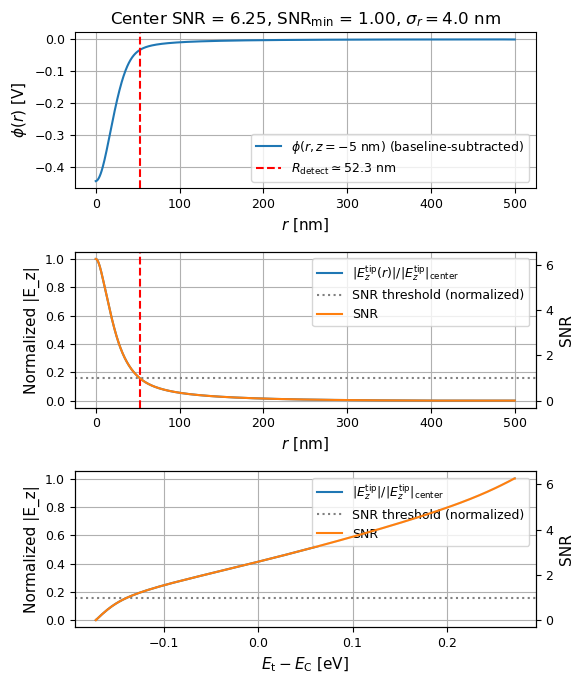

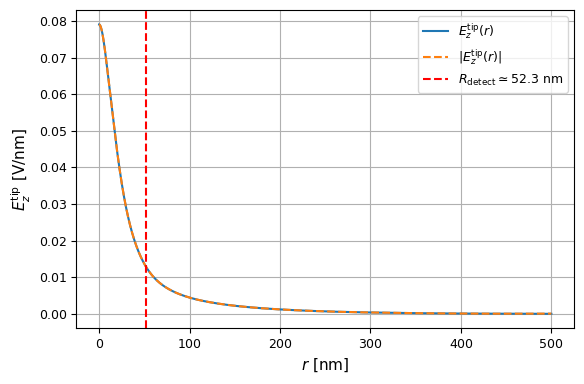

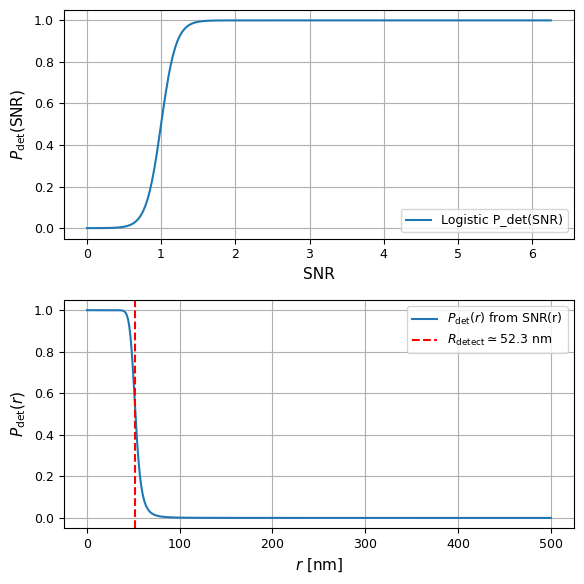

In [107]:
# -*- coding: utf-8 -*-
"""
Post-process FEM ALLNODES.csv to estimate:
  (i) tip-induced vertical field profile Ez(r) at z = -5 nm
  (ii) detection-limited radius R_detect from SNR(r)
  (iii) SNR and normalized |Ez| as a function of (E_t - E_c)
  (iv) Logistic detection model P_det(SNR) and P_det(r)

Assumptions:
- Input CSV has columns: "x (nm)", "y (nm)", "u (V)"
  where x is signed radius r, y is depth z, u is potential [V].
- The FEM run corresponds to a single bias (e.g., V_tip = +4 V).
- States are detected when SNR(r) >= SNR_min (for R_detect).
"""

import os
import datetime
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User parameters
# ============================================================

# --- Input ALLNODES CSV ---
ALLNODES_PATH = "R_vs_V_out_ringA_V_tip+/20251204_0930_ALLNODES.csv"  # ★ここを実際のパスに書き換えてください

# --- Geometry / sampling ---
Z_IF_NM       = -5.0    # interface z (SiO2/SiC)
R_MAX_NM      = 500.0   # radial range to analyze
NR_R_SAMPLES  = 3000     # number of r samples (0 ... R_MAX_NM)

# For Ez estimation: vertical band and radial window around each r
DZ_WINDOW_NM  = 3.0     # |z - Z_IF| <= DZ_WINDOW_NM is used in linear fit
DR_WINDOW_NM  = 4.0     # | |x| - r0 | <= DR_WINDOW_NM

# For smoothing in r
SMOOTH_SIGMA_R_NM = 4.0   # Gaussian sigma in r (nm)

# --- SNR conditions (from experiment) ---
DISS_CENTER_MEV = 5.0   # dissipation at tip center [meV]
NOISE_MEV       = 0.8   # background noise [meV]
SNR_CENTER      = DISS_CENTER_MEV / NOISE_MEV
SNR_MIN         = 1.0   # detection threshold SNR (for R_detect)

# Region used to define "center amplitude" of Ez_tip
R_CENTER_NM = 1.0
R_FAR_NM    = 400.0     # baseline (far from tip)

# --- Energy mapping ---
# E_t - E_c = φ_trap [eV] - DELTA_EtEc_eV, with φ_trap ≈ -φ_corr
DELTA_EtEc_eV = 0.172

# --- Logistic detection model options -----------------------
# P_det(SNR) = 1 / (1 + exp(-(SNR - SNR_th)/Delta))

# モデル選択：
# False: 経験則の SNR_th, Delta を使用
# True : 検証用 CSV (LOGIT_DATA_PATH) からロジスティック回帰でフィット
USE_LOGIT_REGRESSION = False

# 検証用 CSV の指定（USE_LOGIT_REGRESSION=True の場合のみ使用）
LOGIT_DATA_PATH = "snr_det_samples.csv"        # 例: "validation_snr_det.csv"
LOGIT_SNR_COL   = "SNR"
LOGIT_DET_COL   = "det"

# 経験則モードでのパラメータ
SNR_TH_HEURISTIC = SNR_MIN       # だいたい SNR=1 あたりで P_det=0.5
DELTA_HEURISTIC  = 0.1 * SNR_MIN # 立ち上がり幅

# ============================================================
# Utility functions
# ============================================================

def load_allnodes_csv(path: str):
    """
    Load ALLNODES.csv (x [nm], y [nm], u [V]).
    Returns arrays (x, y, u) as float64.
    """
    data = np.genfromtxt(path, delimiter=",", names=True)
    x_nm = np.asarray(data[data.dtype.names[0]], float)
    y_nm = np.asarray(data[data.dtype.names[1]], float)
    u_V  = np.asarray(data[data.dtype.names[2]], float)
    return x_nm, y_nm, u_V

def gaussian_smooth_1d(x: np.ndarray, y: np.ndarray, sigma_nm: float) -> np.ndarray:
    """
    1D Gaussian smoothing on a uniform grid x with spacing ~const.
    Assumes x is sorted and approximately uniform.
    Mirror padding at both ends to avoid edge artifacts.
    """
    y = np.asarray(y, float)
    if sigma_nm <= 0.0 or len(y) < 5:
        return y.copy()

    dx = np.median(np.diff(x))
    if dx <= 0:
        return y.copy()

    sigma_pts = max(sigma_nm / dx, 0.5)
    k_radius = int(np.ceil(3.0 * sigma_pts))
    idx = np.arange(-k_radius, k_radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (idx / sigma_pts)**2)
    kernel /= kernel.sum()

    # mirror padding
    y_pad = np.concatenate((y[1:][::-1], y, y[-2::-1]))
    conv  = np.convolve(y_pad, kernel, mode="same")
    start = len(y) - 1
    end   = start + len(y)
    return conv[start:end]

def build_phi_profile_from_allnodes(x_nm, y_nm, u_V,
                                    z_if_nm: float,
                                    dz_tol_nm: float = 0.4,
                                    r_max_nm: float = 500.0,
                                    nr: int = 701):
    """
    Reconstruct φ(r) at z ≈ z_if_nm using points with |y - z_if| <= dz_tol_nm.
    Uses |x| as radius and binning + interpolation to obtain a smooth profile.
    """
    # pick points near interface
    mask_if = np.abs(y_nm - z_if_nm) <= dz_tol_nm
    x_if    = x_nm[mask_if]
    u_if    = u_V[mask_if]

    if x_if.size < 10:
        raise RuntimeError("Too few points near interface: check dz_tol_nm or ALLNODES.")

    r_abs = np.abs(x_if)
    order = np.argsort(r_abs)
    r_sorted = r_abs[order]
    u_sorted = u_if[order]

    # downsample slightly to avoid dense duplicates near r=0
    dr_min = 0.1   # nm
    keep = np.concatenate(([True], np.diff(r_sorted) > dr_min))
    r_unique = r_sorted[keep]
    u_unique = u_sorted[keep]

    # uniform radial grid
    r_grid = np.linspace(0.0, min(r_unique.max(), r_max_nm), nr)
    phi_r  = np.interp(r_grid, r_unique, u_unique)

    return r_grid, phi_r

def estimate_Ez_profile_from_allnodes(x_nm, y_nm, u_V,
                                      z_if_nm: float,
                                      r_grid: np.ndarray,
                                      dz_window_nm: float = 3.0,
                                      dr_window_nm: float = 4.0):
    """
    For each r0 in r_grid, estimate vertical field E_z(r0) at z ~ z_if by
    a local linear fit of φ vs y in a vertical band:
        |y - z_if| <= dz_window_nm, | |x| - r0 | <= dr_window_nm

    Returns:
        Ez_r : array of same length as r_grid (V/nm), may contain NaNs.
    """
    x_abs = np.abs(x_nm)
    Ez_r  = np.full_like(r_grid, np.nan, dtype=float)

    for i, r0 in enumerate(r_grid):
        mask = (np.abs(x_abs - r0) <= dr_window_nm) & (np.abs(y_nm - z_if_nm) <= dz_window_nm)
        if np.count_nonzero(mask) < 5:
            continue

        y_loc   = y_nm[mask]
        phi_loc = u_V[mask]

        # linear regression φ(y) = a + b*y
        try:
            b, a = np.polyfit(y_loc, phi_loc, 1)  # [b, a]
        except Exception:
            continue

        Ez_r[i] = -b   # [V/nm]

    return Ez_r

# ============================================================
# Logistic detection model utilities
# ============================================================

def logistic_pdet(snr, snr_th, delta):
    """
    Logistic detection probability:
        P_det(SNR) = 1 / (1 + exp(-(SNR - SNR_th)/Delta))
    """
    snr = np.asarray(snr, float)
    # avoid overflow
    z = (snr - snr_th) / delta
    z = np.clip(z, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-z))

def fit_logistic_from_csv(path, snr_col, det_col,
                          init_snr_th=None, init_delta=None,
                          max_iter=2000, lr=0.01):
    """
    1D logistic regression:
        P(y=1 | SNR) = 1 / (1 + exp(-(a + b*SNR)))
    を最尤でフィットし、その後
        a + b*SNR = (SNR - SNR_th)/Delta
    とみなして SNR_th, Delta に変換する。

    CSV 形式:
      snr_col: SNR 値
      det_col: 検出フラグ (0 or 1)
    """
    data = np.genfromtxt(path, delimiter=",", names=True)
    if snr_col not in data.dtype.names or det_col not in data.dtype.names:
        raise RuntimeError(f"Logit CSV must have columns '{snr_col}' and '{det_col}'.")

    S = np.asarray(data[snr_col], float)
    y = np.asarray(data[det_col], float)

    mask = np.isfinite(S) & np.isfinite(y)
    S = S[mask]
    y = y[mask]

    if S.size < 5:
        raise RuntimeError("Too few samples for logistic regression (need >= 5).")

    # 初期値（経験則）から a, b へ変換
    if init_snr_th is None:
        init_snr_th = SNR_TH_HEURISTIC
    if init_delta is None:
        init_delta  = DELTA_HEURISTIC

    a = -init_snr_th / init_delta
    b =  1.0 / init_delta

    for it in range(max_iter):
        z = a + b * S
        z = np.clip(z, -60.0, 60.0)
        p = 1.0 / (1.0 + np.exp(-z))

        # 負の対数尤度の勾配 (平均化)
        grad_a = np.sum(p - y) / S.size
        grad_b = np.sum((p - y) * S) / S.size

        a -= lr * grad_a
        b -= lr * grad_b

        if max(abs(grad_a), abs(grad_b)) < 1e-6:
            break

    if abs(b) < 1e-8:
        raise RuntimeError("Logistic fit failed (b ~ 0).")

    snr_th_fit = -a / b
    delta_fit  =  1.0 / b  # 符号は b に従う（Δ が負になることもあり得る）

    return snr_th_fit, delta_fit, S, y

# ============================================================
# Main
# ============================================================

def main():
    outdir = Path("detect_from_ALLNODES_Ez")
    outdir.mkdir(exist_ok=True)
    stamp  = datetime.datetime.now().strftime("%Y%m%d_%H%M")

    # ---------- 1. Load ALLNODES ----------
    if not os.path.exists(ALLNODES_PATH):
        raise FileNotFoundError(f"ALLNODES file not found: {ALLNODES_PATH}")
    x_nm, y_nm, u_V = load_allnodes_csv(ALLNODES_PATH)

    # ---------- 2. φ(r) at z ≈ Z_IF_NM ----------
    r_grid, phi_r = build_phi_profile_from_allnodes(
        x_nm, y_nm, u_V,
        z_if_nm=Z_IF_NM,
        dz_tol_nm=0.4,
        r_max_nm=R_MAX_NM,
        nr=NR_R_SAMPLES
    )

    # baseline so that φ → 0 at large r
    mask_far_phi = r_grid >= R_FAR_NM
    if np.any(mask_far_phi):
        baseline_phi = np.nanmedian(phi_r[mask_far_phi])
    else:
        baseline_phi = 0.0
    phi_corr = phi_r - baseline_phi

    # ---------- 3. Ez(r) at z ≈ Z_IF_NM (tip-induced vertical field) ----------
    Ez_raw = estimate_Ez_profile_from_allnodes(
        x_nm, y_nm, u_V,
        z_if_nm=Z_IF_NM,
        r_grid=r_grid,
        dz_window_nm=DZ_WINDOW_NM,
        dr_window_nm=DR_WINDOW_NM
    )

    # smoothing in r to suppress noise (especially near r=0)
    Ez_smooth = gaussian_smooth_1d(r_grid, Ez_raw, sigma_nm=SMOOTH_SIGMA_R_NM)

    # subtract baseline at large r to isolate tip-induced part
    mask_far_Ez = r_grid >= R_FAR_NM
    if np.any(mask_far_Ez):
        Ez_baseline = np.nanmedian(Ez_smooth[mask_far_Ez])
    else:
        Ez_baseline = 0.0
    Ez_tip = Ez_smooth - Ez_baseline   # [V/nm], tip-induced component

    # ★追加: 元の |E_z| を明示的に保存
    Ez_abs = np.abs(Ez_tip)            # [V/nm]

    # ---------- 4. Normalized signal & SNR(r) ----------
    mask_center = r_grid <= R_CENTER_NM
    if np.any(mask_center):
        center_amp = np.nanmedian(Ez_abs[mask_center])  # ← Ez_abs を使用
    else:
        center_amp = np.nanmax(Ez_abs)

    if not np.isfinite(center_amp) or center_amp == 0.0:
        raise RuntimeError("Center Ez amplitude is invalid (NaN or 0).")

    norm_signal = Ez_abs / center_amp
    norm_signal = np.clip(norm_signal, 0.0, 1.0)
    print(center_amp)
    SNR_r = SNR_CENTER * norm_signal
    # detection-limited radius: last r where SNR >= SNR_MIN
    R_detect = np.nan
    mask_valid = np.isfinite(SNR_r)
    if np.any(mask_valid):
        r_v  = r_grid[mask_valid]
        S_v  = SNR_r[mask_valid]
        above = S_v >= SNR_MIN
        if np.any(above):
            idx   = np.where(above)[0]
            i_last = idx[-1]
            if i_last < len(S_v) - 1:
                x0, x1 = r_v[i_last], r_v[i_last+1]
                y0, y1 = S_v[i_last], S_v[i_last+1]
                if y1 != y0:
                    R_detect = x0 + (SNR_MIN - y0) * (x1 - x0) / (y1 - y0)
                else:
                    R_detect = x0
            else:
                R_detect = r_v[i_last]

    # ---------- 5. SNR, normalized |Ez| vs (E_t - E_c) ----------
    # ここでは FEM で得た界面ポテンシャルの変化 φ_corr(r) から、
    # トラップ等ポテンシャル φ_trap を
    #   φ_trap ≈ - φ_corr
    # とみなし、
    #   E_t - E_C = φ_trap - Δ_{EtEc}
    # の形でエネルギー軸に写像する（1 V ≈ 1 eV の近似）。
    phi_trap   = -phi_corr                      # [eV] 相当（符号反転）
    EtEc_grid  = phi_trap - DELTA_EtEc_eV       # [eV]

    mask_E = np.isfinite(EtEc_grid) & np.isfinite(norm_signal) & np.isfinite(SNR_r)
    EtEc   = EtEc_grid[mask_E]
    norm_E = norm_signal[mask_E]
    SNR_E  = SNR_r[mask_E]

    # sort by EtEc for a clean curve
    order_E     = np.argsort(EtEc)
    EtEc_sorted = EtEc[order_E]
    norm_sorted = norm_E[order_E]
    SNR_sorted  = SNR_E[order_E]

    # ---------- 6. Logistic detection model: SNR_th, Delta 決定 ----------
    snr_th_used = SNR_TH_HEURISTIC
    delta_used  = DELTA_HEURISTIC
    logit_S = None
    logit_y = None

    if USE_LOGIT_REGRESSION and LOGIT_DATA_PATH:
        try:
            snr_th_used, delta_used, logit_S, logit_y = fit_logistic_from_csv(
                LOGIT_DATA_PATH,
                LOGIT_SNR_COL,
                LOGIT_DET_COL,
                init_snr_th=SNR_TH_HEURISTIC,
                init_delta=DELTA_HEURISTIC
            )
            print(f"[INFO] Logistic regression used: SNR_th ≈ {snr_th_used:.3f}, Δ ≈ {delta_used:.3f}")
        except Exception as e:
            print("[WARN] Logistic regression failed; fallback to heuristic:", e)
            snr_th_used = SNR_TH_HEURISTIC
            delta_used  = DELTA_HEURISTIC
    else:
        print(f"[INFO] Using heuristic logistic params: SNR_th = {snr_th_used:.3f}, Δ = {delta_used:.3f}")

    # 半径毎の検出確率 P_det(r)
    Pdet_r = logistic_pdet(SNR_r, snr_th_used, delta_used)

    # ============================================================
    # Plots (既存 3 パネル)
    # ============================================================

    fig, axes = plt.subplots(3, 1, figsize=(6, 7))

    # --- (1) φ(r) at interface + R_detect ---
    ax1 = axes[0]
    ax1.plot(r_grid, phi_corr, label=r"$\phi(r,z=-5~\mathrm{nm})$ (baseline-subtracted)")
    if np.isfinite(R_detect):
        ax1.axvline(R_detect, color="r", ls="--",
                    label=rf"$R_{{\mathrm{{detect}}}}\simeq {R_detect:.1f}\ \mathrm{{nm}}$")
    ax1.set_xlabel(r"$r\ \mathrm{[nm]}$")
    ax1.set_ylabel(r"$\phi(r)\ \mathrm{[V]}$")
    ax1.grid(True)
    ax1.legend()
    ax1.set_title(
        rf"Center SNR = {SNR_CENTER:.2f}, "
        rf"SNR$_{{\min}}$ = {SNR_MIN:.2f}, "
        rf"$\sigma_r = {SMOOTH_SIGMA_R_NM:.1f}\ \mathrm{{nm}}$"
    )

    # --- (2) |E_z(r)| and SNR(r) ---
    ax2 = axes[1]
    ax2.plot(r_grid, norm_signal,
             label=r"$|E_z^\mathrm{tip}(r)| / |E_z^\mathrm{tip}|_\mathrm{center}$")
    ax2.axhline(SNR_MIN / SNR_CENTER, color="gray", ls=":",
                label="SNR threshold (normalized)")
    if np.isfinite(R_detect):
        ax2.axvline(R_detect, color="r", ls="--")

    ax2.set_xlabel(r"$r\ \mathrm{[nm]}$")
    ax2.set_ylabel("Normalized |E_z|")
    ax2.grid(True)

    ax2_t = ax2.twinx()
    ax2_t.plot(r_grid, SNR_r, color="tab:orange", label="SNR")
    ax2_t.set_ylabel("SNR")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_t.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # --- (3) Normalized |Ez| and SNR vs (E_t - E_c) ---
    ax3 = axes[2]
    ax3.plot(EtEc_sorted, norm_sorted,
             label=r"$|E_z^\mathrm{tip}| / |E_z^\mathrm{tip}|_\mathrm{center}$")
    ax3.axhline(SNR_MIN / SNR_CENTER, color="gray", ls=":",
                label="SNR threshold (normalized)")
    ax3.set_xlabel(r"$E_{\mathrm{t}} - E_{\mathrm{C}}\ \mathrm{[eV]}$")
    ax3.set_ylabel("Normalized |E_z|")
    ax3.grid(True)

    ax3_t = ax3.twinx()
    ax3_t.plot(EtEc_sorted, SNR_sorted, color="tab:orange", label="SNR")
    ax3_t.set_ylabel("SNR")

    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax3_t.get_legend_handles_labels()
    ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper right")

    fig.tight_layout()
    fig_path = outdir / f"{stamp}_detection_from_ALLNODES_Ez_3panels.png"
    fig.savefig(fig_path, dpi=400, bbox_inches="tight")
    print("[INFO] saved plot:", fig_path)

    # ============================================================
    # ★新規: Ez(r) 単独の図（元の E_z vs r）
    # ============================================================

    figEz, axEz = plt.subplots(1, 1, figsize=(6, 4))
    axEz.plot(r_grid, Ez_tip, label=r"$E_z^\mathrm{tip}(r)$")
    axEz.plot(r_grid, Ez_abs, ls="--",
              label=r"$|E_z^\mathrm{tip}(r)|$")
    if np.isfinite(R_detect):
        axEz.axvline(R_detect, color="r", ls="--",
                     label=rf"$R_{{\mathrm{{detect}}}}\simeq {R_detect:.1f}\ \mathrm{{nm}}$")
    axEz.set_xlabel(r"$r\ \mathrm{[nm]}$")
    axEz.set_ylabel(r"$E_z^\mathrm{tip}\ \mathrm{[V/nm]}$")
    axEz.grid(True)
    axEz.legend()
    figEz.tight_layout()
    figEz_path = outdir / f"{stamp}_Ez_vs_r.png"
    figEz.savefig(figEz_path, dpi=400, bbox_inches="tight")
    print("[INFO] saved Ez(r) plot:", figEz_path)

    # ============================================================
    # 新規: ロジスティック関連の 2 パネル
    #   (4) SNR vs P_det(SNR)
    #   (5) r vs P_det(r)
    # ============================================================

    fig2, axes2 = plt.subplots(2, 1, figsize=(6, 6))

    # (4) SNR vs P_det(SNR)
    ax_snr = axes2[0]
    finite_snr = SNR_r[np.isfinite(SNR_r)]
    if finite_snr.size > 0:
        snr_max_plot = max(finite_snr.max(), 1.5 * SNR_MIN, 2.0)
    else:
        snr_max_plot = max(2.0 * SNR_MIN, 2.0)

    snr_min_plot = 0.0
    snr_plot = np.linspace(snr_min_plot, snr_max_plot, 200)
    P_plot   = logistic_pdet(snr_plot, snr_th_used, delta_used)

    ax_snr.plot(snr_plot, P_plot, label="Logistic P_det(SNR)")
    if logit_S is not None and logit_y is not None:
        # 生データの散布図 (0/1)
        ax_snr.scatter(logit_S, logit_y, s=12, alpha=0.4,
                       label="validation samples")

    ax_snr.set_xlabel("SNR")
    ax_snr.set_ylabel(r"$P_{\mathrm{det}}(\mathrm{SNR})$")
    ax_snr.grid(True)
    ax_snr.legend()

    # (5) r vs P_det(r)
    ax_R = axes2[1]
    ax_R.plot(r_grid, Pdet_r, label=r"$P_{\mathrm{det}}(r)$ from SNR(r)")
    if np.isfinite(R_detect):
        ax_R.axvline(R_detect, color="r", ls="--",
                     label=rf"$R_{{\mathrm{{detect}}}}\simeq {R_detect:.1f}\ \mathrm{{nm}}$")
    ax_R.set_xlabel(r"$r\ \mathrm{[nm]}$")
    ax_R.set_ylabel(r"$P_{\mathrm{det}}(r)$")
    ax_R.grid(True)
    ax_R.legend()

    fig2.tight_layout()
    fig2_path = outdir / f"{stamp}_logistic_Pdet_plots.png"
    fig2.savefig(fig2_path, dpi=400, bbox_inches="tight")
    print("[INFO] saved logistic plots:", fig2_path)

    # ============================================================
    # Save curve data to CSVs
    # ============================================================

    # (1) φ(r) vs r
    phi_csv = outdir / f"{stamp}_phi_vs_r.csv"
    np.savetxt(
        phi_csv,
        np.column_stack([r_grid, phi_corr]),
        delimiter=",",
        header="r_nm,phi_corr_V",
        comments=""
    )
    print("[INFO] saved curve data:", phi_csv)

    # (2) normalized |Ez| & SNR vs r（既存ファイルは形式そのまま）
    Ez_SNR_r_csv = outdir / f"{stamp}_Ez_norm_and_SNR_vs_r.csv"
    np.savetxt(
        Ez_SNR_r_csv,
        np.column_stack([r_grid, norm_signal, SNR_r]),
        delimiter=",",
        header="r_nm,normalized_Ez,SNR_r",
        comments=""
    )
    print("[INFO] saved curve data:", Ez_SNR_r_csv)

    # ★新規: 元の Ez(r) を保存
    Ez_r_csv = outdir / f"{stamp}_Ez_vs_r.csv"
    np.savetxt(
        Ez_r_csv,
        np.column_stack([r_grid, Ez_tip, Ez_abs]),
        delimiter=",",
        header="r_nm,Ez_tip_V_per_nm,abs_Ez_tip_V_per_nm",
        comments=""
    )
    print("[INFO] saved curve data:", Ez_r_csv)

    # (3) normalized |Ez| & SNR vs (E_t - E_c)
    Ez_SNR_E_csv = outdir / f"{stamp}_Ez_norm_and_SNR_vs_Et_minus_Ec.csv"
    np.savetxt(
        Ez_SNR_E_csv,
        np.column_stack([EtEc_sorted, norm_sorted, SNR_sorted]),
        delimiter=",",
        header="Et_minus_Ec_eV,normalized_Ez,SNR",
        comments=""
    )
    print("[INFO] saved curve data:", Ez_SNR_E_csv)

    # (4) P_det vs SNR (ロジスティック曲線)
    Pdet_SNR_csv = outdir / f"{stamp}_Pdet_vs_SNR.csv"
    np.savetxt(
        Pdet_SNR_csv,
        np.column_stack([snr_plot, P_plot]),
        delimiter=",",
        header="SNR,Pdet",
        comments=""
    )
    print("[INFO] saved curve data:", Pdet_SNR_csv)

    # (5) P_det vs r
    Pdet_r_csv = outdir / f"{stamp}_Pdet_vs_r.csv"
    np.savetxt(
        Pdet_r_csv,
        np.column_stack([r_grid, Pdet_r]),
        delimiter=",",
        header="r_nm,Pdet_r",
        comments=""
    )
    print("[INFO] saved curve data:", Pdet_r_csv)

    # ============================================================

    if np.isfinite(R_detect):
        print(f"[INFO] Estimated detection-limited radius R_detect ≈ {R_detect:.1f} nm")
    else:
        print("[INFO] R_detect could not be determined (SNR never >= SNR_MIN).")

if __name__ == "__main__":
    main()


In [128]:
# -*- coding: utf-8 -*-
"""
pred_exp.csv（file, score, cx, cy, a, b, radius, angle ...）と
元画像CSV（同名 *.csv, 行列：単位 = eV/cycle）から各リングの SNR を計算して保存します。

機能:
- 背景ノイズ抽出モード（bg_mode）:
   * "local_annulus"：楕円外側のローカル環状帯域（従来）
   * "global_excluding_rings"：検出リング（マージン膨張）を除いた画像全域
   * "hp_residual"：ガウシアンで低周波を落とした残差上で評価（signal も残差上）
- signal の代表値（signal_stat）:
   * "mean" / "max" / "pXX"（例: 0.9）/ "topk_mean"（上位割合の平均）
- “手打ち”で背景中央値・ノイズσ（eV/cycle）を固定して SNR を計算するオプション:
   * override_bg_central_eV, override_noise_sigma_eV を与えたものだけ自動推定を上書き
- 出力は自動推定での SNR（snr_auto_eV）と、上書き適用後の SNR（snr_used_eV）の両方を保存

SNR 定義: (signal_value - bg_central) / noise_sigma
"""

import os
import math
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm import tqdm

# ----------------------------
# 画像読み込み（元CSVの生値: 単位 eV/cycle）
# ----------------------------
def load_raw_csv_image(path_csv: str) -> np.ndarray:
    arr = np.loadtxt(path_csv, delimiter=",", dtype=np.float32)
    return arr  # eV/cycle

# ----------------------------
# マスク生成（リング帯域 / 背景帯域: ローカル環状）
# ----------------------------
def _ellipse_ring_masks(
    H: int, W: int,
    cx: float, cy: float, a: float, b: float, ang_deg: float,
    ring_width_px: int = 4,
    bg_offset_px: int = 6,
    bg_width_px: int = 6,
):
    cx_i, cy_i = int(round(cx)), int(round(cy))
    a_i, b_i = max(1, int(round(a))), max(1, int(round(b)))
    th_r = max(1, int(round(ring_width_px)))
    th_bg = max(1, int(round(bg_width_px)))
    off_bg = max(1, int(round(bg_offset_px)))

    # ring band（差分で環状化）
    ring_outer = np.zeros((H, W), dtype=np.uint8)
    ring_inner = np.zeros((H, W), dtype=np.uint8)
    cv2.ellipse(ring_outer, (cx_i, cy_i), (a_i + th_r//2, b_i + th_r//2),
                ang_deg, 0, 360, 255, thickness=-1, lineType=cv2.LINE_AA)
    cv2.ellipse(ring_inner, (cx_i, cy_i), (max(1, a_i - th_r//2), max(1, b_i - th_r//2)),
                ang_deg, 0, 360, 255, thickness=-1, lineType=cv2.LINE_AA)
    ring_band = (ring_outer.astype(np.int32) - ring_inner.astype(np.int32)) > 0
    ring_band = ring_band.astype(bool)

    # background band（外側にオフセット）
    bg_outer = np.zeros((H, W), dtype=np.uint8)
    bg_inner = np.zeros((H, W), dtype=np.uint8)
    a_bg = a_i + off_bg
    b_bg = b_i + off_bg
    cv2.ellipse(bg_outer, (cx_i, cy_i), (a_bg + th_bg//2, b_bg + th_bg//2),
                ang_deg, 0, 360, 255, thickness=-1, lineType=cv2.LINE_AA)
    cv2.ellipse(bg_inner, (cx_i, cy_i), (max(1, a_bg - th_bg//2), max(1, b_bg - th_bg//2)),
                ang_deg, 0, 360, 255, thickness=-1, lineType=cv2.LINE_AA)
    bg_band = (bg_outer.astype(np.int32) - bg_inner.astype(np.int32)) > 0
    bg_band = bg_band.astype(bool)

    # 安全策: 背景とリングが重なる画素は除外
    bg_band = np.logical_and(bg_band, np.logical_not(ring_band))
    return ring_band, bg_band

# ----------------------------
# グローバル背景マスク（全リング除外）
# ----------------------------
def _global_bg_mask_excluding_rings(
    H: int, W: int,
    rings_px: list,              # [(cx,cy,a,b,ang_deg), ...] すべてピクセル単位
    exclude_margin_px: int = 6,  # リング周囲に追加で膨張するマージン
    edge_exclude_px: int = 0     # 画面の縁を避けたいとき（0で無効）
):
    exclude = np.zeros((H, W), dtype=np.uint8)
    for (cx, cy, a, b, ang_deg) in rings_px:
        cx_i, cy_i = int(round(cx)), int(round(cy))
        ax = max(1, int(round(a + exclude_margin_px)))
        by = max(1, int(round(b + exclude_margin_px)))
        cv2.ellipse(exclude, (cx_i, cy_i), (ax, by), ang_deg, 0, 360,
                    255, thickness=-1, lineType=cv2.LINE_AA)
    bg = (exclude == 0)

    if edge_exclude_px > 0:
        bg[:edge_exclude_px, :] = False
        bg[-edge_exclude_px:, :] = False
        bg[:, :edge_exclude_px] = False
        bg[:, -edge_exclude_px:] = False
    return bg

# ----------------------------
# signal 代表値の計算
# ----------------------------
def _signal_value(vals: np.ndarray, mode: str = "mean",
                  percentile: float = 0.90, topk_frac: float = 0.05) -> float:
    if vals.size == 0:
        return float("nan")
    if mode == "mean":
        return float(np.mean(vals))
    if mode == "max":
        return float(np.max(vals))
    if mode == "pXX":
        p = float(np.clip(percentile, 0.0, 1.0)) * 100.0
        return float(np.percentile(vals, p))
    if mode == "topk_mean":
        k = max(1, int(math.ceil(topk_frac * vals.size)))
        part = np.partition(vals, -k)[-k:]  # 上位k個の平均
        return float(np.mean(part))
    # fallback
    return float(np.mean(vals))

# ----------------------------
# 背景中央値 & ノイズσ（MAD→σ or 標準偏差）
# ----------------------------
def _bg_central_and_sigma(bg_vals: np.ndarray,
                          sigma_mode: str = "mad"):  # "mad" or "std"
    if bg_vals.size < 5:
        return float("nan"), float("nan")
    median_bg = float(np.median(bg_vals))
    if sigma_mode == "std":
        sigma = float(np.std(bg_vals, ddof=1))
    else:
        mad = float(np.median(np.abs(bg_vals - median_bg)))
        sigma = 1.4826 * mad
    return median_bg, sigma

# ----------------------------
# SNR（汎用計算）
# ----------------------------
def _snr_from_components(signal_val: float, bg_central: float, sigma: float) -> float:
    if not (np.isfinite(signal_val) and np.isfinite(bg_central) and np.isfinite(sigma)):
        return float("nan")
    if sigma <= 1e-12:
        return float("nan")
    return float((signal_val - bg_central) / sigma)

# ----------------------------
# メイン処理
# ----------------------------
def compute_ring_snr(
    pred_csv_path: str,
    images_dir: str,
    out_csv_path: str = "results_snr.csv",
    pred_image_size=(512, 512),           # 推論参照枠
    # --- 従来どおりのローカル環状パラメータ ---
    ring_width_frac: float = 0.008,
    bg_offset_frac: float = 0.012,
    bg_width_frac: float = 0.015,
    # --- 追加オプション ---
    bg_mode: str = "local_annulus",        # "local_annulus" | "global_excluding_rings" | "hp_residual"
    global_exclude_margin_frac: float = 0.02,  # global除外時の膨張マージン
    edge_exclude_px: int = 0,                  # 画面端マスクを除くピクセル数
    signal_stat: str = "mean",             # "mean" | "max" | "pXX" | "topk_mean"
    signal_percentile: float = 0.90,       # pXX用（0..1）
    signal_topk_frac: float = 0.05,        # topk_mean用（0..1）
    noise_sigma_mode: str = "mad",         # "mad" | "std"
    hp_sigma_px: float = 8.0,              # hp_residual用のガウシアンσ（px）
    # --- 画像の軽い正規化（任意） ---
    use_percentile_clip_for_img=False,
    clip_low_high=(1.0, 99.0),
    # ==============================
    # ★“手打ち（固定）”オプション（単位: eV/cycle）
    # ==============================
    # raw 値 → eV/cycle の線形換算（通常は 1.0/0.0 のままでOK）
    raw_to_eV_scale: float = 1.0,
    raw_offset_eV: float = 0.0,
    # 背景中央値（基準レベル）とノイズσを固定したいときに指定（Noneなら自動推定）
    override_bg_central_eV: float | None = None,   # 例: 0.0
    override_noise_sigma_eV: float | None = None   # 例: 0.0008
):
    df = pd.read_csv(pred_csv_path)
    assert {"file","cx","cy","a","b","angle"}.issubset(df.columns), \
        "pred_exp.csv に必要な列（file,cx,cy,a,b,angle）が見つかりません。"

    Ht, Wt = int(pred_image_size[0]), int(pred_image_size[1])
    ms = float(min(Ht, Wt))
    # ローカル環状の厚み等 → px
    ring_width_px = max(1, int(round(ring_width_frac * ms)))
    bg_offset_px  = max(1, int(round(bg_offset_frac  * ms)))
    bg_width_px   = max(1, int(round(bg_width_frac  * ms)))
    # グローバル除外マージン
    excl_margin_px = max(1, int(round(global_exclude_margin_frac * ms)))

    out_rows = []

    # fileごとに処理
    for fname, g in tqdm(df.groupby("file"), desc="SNR compute"):
        path_csv = Path(images_dir) / fname
        if not path_csv.exists():
            print(f"[WARN] image csv not found: {path_csv}")
            continue

        raw = load_raw_csv_image(str(path_csv))  # eV/cycle
        img_raw = cv2.resize(raw, (Wt, Ht), interpolation=cv2.INTER_AREA).astype(np.float32)

        # 統計用画像（必要に応じて軽く正規化）。単位は raw のまま（後で eV/cycle 換算）
        img_for_stats = img_raw.copy()
        if use_percentile_clip_for_img:
            lo, hi = np.percentile(img_for_stats, clip_low_high)
            if hi <= lo:
                lo, hi = float(img_for_stats.min()), float(img_for_stats.max() + 1e-6)
            img_for_stats = np.clip((img_for_stats - lo) / max(1e-6, hi - lo), 0, 1.0).astype(np.float32)

        # グローバル背景に使う「全リング除外マスク」を先に作る
        rings_px = []
        for _, row in g.iterrows():
            cx = float(row["cx"]) * Wt
            cy = float(row["cy"]) * Ht
            a  = float(row["a"])  * Wt
            b  = float(row["b"])  * Ht
            ang_deg = float(row["angle"]) * 180.0
            rings_px.append((cx, cy, a, b, ang_deg))
        global_bg_mask = _global_bg_mask_excluding_rings(
            Ht, Wt, rings_px,
            exclude_margin_px=excl_margin_px,
            edge_exclude_px=edge_exclude_px
        )

        # hp_residual用の残差画像（背景トレンドを除去）
        if bg_mode == "hp_residual":
            # ガウシアン平滑 → 残差（高周波）
            blur = cv2.GaussianBlur(img_for_stats, (0, 0), sigmaX=hp_sigma_px, sigmaY=hp_sigma_px)
            residual = img_for_stats - blur
            img_measure = residual
        else:
            img_measure = img_for_stats

        # リングごと
        for idx, row in g.reset_index(drop=True).iterrows():
            cx = float(row["cx"]) * Wt
            cy = float(row["cy"]) * Ht
            a  = float(row["a"])  * Wt
            b  = float(row["b"])  * Ht
            ang_deg = float(row["angle"]) * 180.0

            # ローカル環状（従来）
            ring_mask_local, bg_mask_local = _ellipse_ring_masks(
                Ht, Wt, cx, cy, a, b, ang_deg,
                ring_width_px=ring_width_px,
                bg_offset_px=bg_offset_px,
                bg_width_px=bg_width_px
            )
            # 背景マスクの選択
            if bg_mode == "local_annulus":
                bg_mask = bg_mask_local
            elif bg_mode == "global_excluding_rings":
                bg_mask = global_bg_mask
            elif bg_mode == "hp_residual":
                bg_mask = global_bg_mask  # 残差上で、全リング除外の背景を推奨
            else:
                bg_mask = bg_mask_local  # fallback

            # --- signal（raw）→ eV/cycle に換算 ---
            ring_vals_raw = img_measure[ring_mask_local]
            signal_raw = _signal_value(ring_vals_raw, mode=signal_stat,
                                       percentile=signal_percentile,
                                       topk_frac=signal_topk_frac)
            signal_eV = signal_raw * raw_to_eV_scale + raw_offset_eV

            # --- 背景中央値＆σ（自動推定; raw → eV/cycle 換算）---
            bg_vals_raw = img_measure[bg_mask]
            bg_central_raw, sigma_raw = _bg_central_and_sigma(bg_vals_raw, sigma_mode=noise_sigma_mode)
            bg_central_eV_auto = (bg_central_raw * raw_to_eV_scale + raw_offset_eV
                                   if np.isfinite(bg_central_raw) else np.nan)
            sigma_eV_auto = (sigma_raw * raw_to_eV_scale if np.isfinite(sigma_raw) else np.nan)
            snr_auto = _snr_from_components(signal_eV, bg_central_eV_auto, sigma_eV_auto)

            # --- 手打ちで上書き（指定されたものだけ上書き）---
            bg_central_eV_used = (override_bg_central_eV
                                   if override_bg_central_eV is not None
                                   else bg_central_eV_auto)
            sigma_eV_used = (override_noise_sigma_eV
                              if override_noise_sigma_eV is not None
                              else sigma_eV_auto)
            snr_used = _snr_from_components(signal_eV, bg_central_eV_used, sigma_eV_used)

            out_rows.append({
                "file": fname,
                "ring_idx": int(idx) + 1,
                "score": float(row["score"]) if "score" in row else np.nan,
                "cx": float(row["cx"]), "cy": float(row["cy"]),
                "a": float(row["a"]), "b": float(row["b"]),
                "angle": float(row["angle"]),
                "radius": float(row.get("radius", 0.5*(float(row["a"])+float(row["b"])))),

                # 計算値（eV/cycle 系）
                "signal_eV_per_cycle": signal_eV,
                "bg_central_eV_auto": bg_central_eV_auto,
                "noise_sigma_eV_auto": sigma_eV_auto,
                "snr_auto_eV": snr_auto,  # 自動推定 SNR

                # 使用した値（手打ちで上書き後）
                "bg_central_eV_used": bg_central_eV_used,
                "noise_sigma_eV_used": sigma_eV_used,
                "snr_used_eV": snr_used,  # 上書き適用後 SNR

                # メタ
                "bg_mode": bg_mode,
                "signal_stat": signal_stat,
                "noise_sigma_mode_auto": noise_sigma_mode,
                "raw_to_eV_scale": raw_to_eV_scale,
                "raw_offset_eV": raw_offset_eV,
                "overrode_bg_central": override_bg_central_eV is not None,
                "overrode_noise_sigma": override_noise_sigma_eV is not None,
                "n_ring_px": int(ring_vals_raw.size),
                "n_bg_px": int(bg_vals_raw.size)
            })

    if len(out_rows) == 0:
        print("[WARN] no rows to write.")
        return

    out_df = pd.DataFrame(out_rows)
    out_df.to_csv(out_csv_path, index=False, encoding="utf-8")
    print(f"[OK] wrote: {out_csv_path}")

# ---------------------------------
# 例：直接実行（パスを適宜変更）
# ---------------------------------
if __name__ == "__main__":
    # 1) 従来どおり（ローカル環状＋平均, 自動推定SNR）
    compute_ring_snr(
        pred_csv_path="data_csv/pred_exp_tiled_fused.csv",
        images_dir="data_csv",
        out_csv_path="data_csv/results_snr_local.csv",
        pred_image_size=(512,512),
        ring_width_frac=0.008,
        bg_offset_frac=0.012,
        bg_width_frac=0.015,
        bg_mode="local_annulus",
        signal_stat="mean",
        noise_sigma_mode="mad",
        use_percentile_clip_for_img=False,
        # eV/cycle 前提なので 1.0/0.0 のままでOK
        raw_to_eV_scale=1.0,
        raw_offset_eV=0.0
    )

    # 2) 全リング除外のグローバル背景＋上位5%平均（自動推定SNR）
    compute_ring_snr(
        pred_csv_path="data_csv/pred_exp_tiled_fused.csv",
        images_dir="data_csv",
        out_csv_path="data_csv/results_snr_global_topk.csv",
        pred_image_size=(512,512),
        ring_width_frac=0.008,
        bg_mode="global_excluding_rings",
        global_exclude_margin_frac=0.02,
        signal_stat="topk_mean",
        signal_topk_frac=0.05,
        noise_sigma_mode="mad",
        raw_to_eV_scale=1.0,
        raw_offset_eV=0.0
    )

    # 3) 高周波残差ベース（背景トレンド除去）＋p90（“手打ち”で背景=0, σ=8e-4 eV/cycle）
    compute_ring_snr(
        pred_csv_path="data_csv/pred_exp_tiled_fused.csv",
        images_dir="data_csv",
        out_csv_path="data_csv/results_snr_fixed.csv",
        pred_image_size=(512,512),
        ring_width_frac=0.008,
        bg_mode="local_annulus",
        signal_stat="mean",
        noise_sigma_mode="mad",   # 自動推定側の記録用。上書き時は snr_used_eV で固定値が使われる
        raw_to_eV_scale=1.0,
        raw_offset_eV=0.0,
        # ★ 手打ち（固定値; 例）：背景0 eV/cycle, ノイズσ 8e-4 eV/cycle
        override_bg_central_eV=1.7e-3,
        override_noise_sigma_eV=6e-4
    )


SNR compute: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s]


[OK] wrote: data_csv/results_snr_local.csv


SNR compute: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


[OK] wrote: data_csv/results_snr_global_topk.csv


SNR compute: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]

[OK] wrote: data_csv/results_snr_fixed.csv


In [ ]:
# -*- coding: utf-8 -*-
"""
Ring center distribution & nearest-neighbor analysis.

Input
-----
A table file (CSV or Excel) that contains ring center coordinates.
Required columns:
  - cx, cy
Optional columns:
  - file  (if present, treat each file as a separate 1×1 µm² image; NN distances are computed within each group)

Assumed physical scan size
-------------------------
The original image size is 1×1 µm². We report distances in nm.
- If cx, cy are normalized in [0, 1], convert:
    x_nm = cx * size_nm,  y_nm = cy * size_nm
- If cx, cy are already in nm, keep them as-is.
- If cx, cy are pixels, convert by:
    nm_per_px = size_nm / img_px  (img_px default 512)
    x_nm = cx * nm_per_px, y_nm = cy * nm_per_px

Outputs (timestamped Asia/Tokyo time)
-------------------------------------
1) PNG scatter of center positions (red dots), dpi=600
2) CSV list of nearest-neighbor distances (nm)
3) PNG histogram of nearest-neighbor distances, dpi=600
"""

from __future__ import annotations

import argparse
import math
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _read_table(path: str) -> pd.DataFrame:
    """
    Robust reader:
      - try CSV first
      - if looks like Excel (zip), or CSV parsing fails, try read_excel
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(path)

    # Try to detect Excel-by-content quickly
    is_zip = False
    try:
        import zipfile
        is_zip = zipfile.is_zipfile(str(p))
    except Exception:
        is_zip = False

    if is_zip:
        return pd.read_excel(str(p))

    # Try CSV
    try:
        return pd.read_csv(str(p))
    except Exception:
        # fallback to Excel
        return pd.read_excel(str(p))


def _auto_coord_mode(cx: np.ndarray, cy: np.ndarray) -> str:
    """
    Heuristic:
      - if max <= ~1.5 and min >= ~-0.5 => normalized
      - elif max <= ~2000 => maybe nm or px; ambiguous => decide by magnitude
    """
    cxv = np.asarray(cx, dtype=float)
    cyv = np.asarray(cy, dtype=float)
    mx = float(np.nanmax([np.nanmax(cxv), np.nanmax(cyv)]))
    mn = float(np.nanmin([np.nanmin(cxv), np.nanmin(cyv)]))

    if (mn >= -0.5) and (mx <= 1.5):
        return "normalized"
    # If values are within a few thousand, could be px or nm.
    # We'll call it 'nm' if it looks like 0..1000-ish.
    if (mn >= -50) and (mx <= 1200):
        return "nm"
    return "px"


def _to_nm(cx: np.ndarray, cy: np.ndarray, mode: str, size_nm: float, img_px: int) -> tuple[np.ndarray, np.ndarray]:
    cx = np.asarray(cx, dtype=float)
    cy = np.asarray(cy, dtype=float)

    if mode == "normalized":
        return cx * size_nm, cy * size_nm
    if mode == "nm":
        return cx, cy
    if mode == "px":
        nm_per_px = float(size_nm) / float(img_px)
        return cx * nm_per_px, cy * nm_per_px
    raise ValueError(f"Unknown coord mode: {mode}")


def _nearest_neighbor_distances(points_xy: np.ndarray) -> np.ndarray:
    """
    Returns nearest-neighbor distance for each point (excluding itself).
    Uses SciPy cKDTree if available; else sklearn; else chunked numpy fallback.
    """
    pts = np.asarray(points_xy, dtype=float)
    n = pts.shape[0]
    if n <= 1:
        return np.full((n,), np.nan, dtype=float)

    # Try SciPy
    try:
        from scipy.spatial import cKDTree  # type: ignore
        tree = cKDTree(pts)
        dists, _ = tree.query(pts, k=2)  # first is self (0), second is NN
        return dists[:, 1].astype(float)
    except Exception:
        pass

    # Try sklearn
    try:
        from sklearn.neighbors import NearestNeighbors  # type: ignore
        nn = NearestNeighbors(n_neighbors=2, algorithm="auto")
        nn.fit(pts)
        dists, _ = nn.kneighbors(pts)
        return dists[:, 1].astype(float)
    except Exception:
        pass

    # Fallback: chunked O(N^2)
    out = np.full((n,), np.inf, dtype=float)
    chunk = 2048  # adjust if needed
    for i0 in range(0, n, chunk):
        i1 = min(n, i0 + chunk)
        block = pts[i0:i1]  # (b,2)
        # compute distances to all points
        # (b,n,2) = block[:,None,:] - pts[None,:,:]
        diff = block[:, None, :] - pts[None, :, :]
        d2 = np.sum(diff * diff, axis=2)
        # ignore self distances inside the corresponding indices
        for bi, gi in enumerate(range(i0, i1)):
            d2[bi, gi] = np.inf
        out[i0:i1] = np.sqrt(np.min(d2, axis=1))
    out[~np.isfinite(out)] = np.nan
    return out


def plot_centers(x_nm: np.ndarray, y_nm: np.ndarray, out_png: str, size_nm: float, invert_y: bool, title: str, dpi: int):
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.scatter(x_nm, y_nm, s=8, c="red", marker="o", linewidths=0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(0, size_nm)
    ax.set_ylim(0, size_nm)
    ax.set_xlabel("cx (nm)")
    ax.set_ylabel("cy (nm)")
    ax.set_title(title)

    if invert_y:
        ax.invert_yaxis()  # match image coordinates (origin at top-left)

    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi)
    plt.close()


def plot_hist(values_nm: np.ndarray, out_png: str, title: str, dpi: int, bins: str | int = "auto"):
    v = np.asarray(values_nm, dtype=float)
    v = v[np.isfinite(v)]
    plt.figure(figsize=(6.5, 4.5))
    ax = plt.gca()
    ax.hist(v, bins=bins)
    ax.set_xlabel("Nearest-neighbor distance (nm)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi)
    plt.close()


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--infile", required=True, help="Input CSV or Excel file path")
    ap.add_argument("--outdir", default=".", help="Output directory")
    ap.add_argument("--size_nm", type=float, default=1000.0, help="Physical scan size (nm). 1 µm -> 1000 nm")
    ap.add_argument("--coord_mode", choices=["auto", "normalized", "px", "nm"], default="auto",
                    help="How to interpret cx,cy. 'auto' tries to infer.")
    ap.add_argument("--img_px", type=int, default=512, help="Image size in pixels (used only if coord_mode='px')")
    ap.add_argument("--invert_y", action="store_true", help="Invert y-axis to match image coordinates")
    ap.add_argument("--no_invert_y", dest="invert_y", action="store_false")
    ap.set_defaults(invert_y=True)
    ap.add_argument("--dpi", type=int, default=600, help="PNG dpi")
    ap.add_argument("--bins", default="auto", help="Histogram bins: 'auto'/'fd'/int")
    args = ap.parse_args()

    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # Timestamp in Asia/Tokyo
    ts = datetime.now(ZoneInfo("Asia/Tokyo")).strftime("%Y%m%d_%H%M%S")

    df = _read_table(args.infile)

    # Column check
    if ("cx" not in df.columns) or ("cy" not in df.columns):
        raise ValueError("Input file must contain columns: cx, cy")

    # Clean rows
    df = df.copy()
    df = df[np.isfinite(df["cx"].to_numpy(dtype=float)) & np.isfinite(df["cy"].to_numpy(dtype=float))]
    if df.empty:
        raise ValueError("No valid (cx, cy) rows found.")

    # Grouping
    if "file" in df.columns:
        groups = list(df.groupby("file"))
    else:
        groups = [("ALL", df)]

    # Determine coord mode
    cx_all = df["cx"].to_numpy(dtype=float)
    cy_all = df["cy"].to_numpy(dtype=float)
    if args.coord_mode == "auto":
        coord_mode = _auto_coord_mode(cx_all, cy_all)
    else:
        coord_mode = args.coord_mode

    # Prepare outputs
    centers_png = outdir / f"{ts}_centers.png"
    nn_csv = outdir / f"{ts}_nearest_neighbor.csv"
    hist_png = outdir / f"{ts}_nearest_neighbor_hist.png"

    # For plot ①: combine all points in nm
    x_nm_all, y_nm_all = _to_nm(cx_all, cy_all, coord_mode, args.size_nm, args.img_px)
    title1 = f"Ring centers (N={len(df)}) | coord={coord_mode} | size={args.size_nm:.0f} nm"
    plot_centers(x_nm_all, y_nm_all, str(centers_png), size_nm=args.size_nm, invert_y=args.invert_y, title=title1, dpi=args.dpi)

    # For ②: compute NN distances within each image group
    out_rows = []
    for gname, gdf in groups:
        cx = gdf["cx"].to_numpy(dtype=float)
        cy = gdf["cy"].to_numpy(dtype=float)
        x_nm, y_nm = _to_nm(cx, cy, coord_mode, args.size_nm, args.img_px)
        pts = np.stack([x_nm, y_nm], axis=1)
        nn = _nearest_neighbor_distances(pts)

        for i in range(len(gdf)):
            row = {
                "group": str(gname),
                "cx": float(cx[i]),
                "cy": float(cy[i]),
                "x_nm": float(x_nm[i]),
                "y_nm": float(y_nm[i]),
                "nn_dist_nm": float(nn[i]) if np.isfinite(nn[i]) else np.nan,
            }
            # Keep ring_idx if exists
            if "ring_idx" in gdf.columns:
                try:
                    row["ring_idx"] = int(gdf.iloc[i]["ring_idx"])
                except Exception:
                    row["ring_idx"] = gdf.iloc[i]["ring_idx"]
            out_rows.append(row)

    out_df = pd.DataFrame(out_rows)

    # Write ②
    out_df.to_csv(nn_csv, index=False, encoding="utf-8")

    # Plot ③ (hist of NN distances)
    nn_all = out_df["nn_dist_nm"].to_numpy(dtype=float)
    bins = args.bins
    try:
        if isinstance(bins, str) and bins.isdigit():
            bins = int(bins)
    except Exception:
        pass
    title3 = f"Nearest-neighbor distance histogram | coord={coord_mode} | N={np.isfinite(nn_all).sum()}"
    plot_hist(nn_all, str(hist_png), title=title3, dpi=args.dpi, bins=bins)

    print("[OK] Saved:")
    print("  ① centers png:", centers_png)
    print("  ② nn list csv:", nn_csv)
    print("  ③ nn hist png:", hist_png)


if __name__ == "__main__":
    main()
